<div style="background: linear-gradient(135deg, #e9f2fb 0%, #f7fbff 100%); padding: 18px 20px; border: 1px solid #d5e3f0; border-radius: 10px; text-align: center;">
  <div style="font-size: 32px; font-weight: 700; color: #1f3b57; letter-spacing: 0.2px;">NX-414 Brain-like Computation and Intelligence</div>
</div>


<div style="text-align: center; font-size: 21px; font-weight: 600; color: #36536b; margin-top: 6px;">Project Notebook — Spring 2026</div>


<div style="text-align: center; color: #4f6478; font-size: 16px; margin-bottom: 10px;">Brain–Model Alignment Across Neural Recording Modalities</div>
<div style="text-align: center; color: #6b7280; font-size: 13px;">Prepared by: Abdulkadir Gokce</div>

---


# Group Information

Fill in this section at the top of your notebook and report.

- **Group member 1:** Full name, SCIPER number, email address  
- **Group member 2:** Full name, SCIPER number, email address  
- **Group member 3 (if applicable):** Full name, SCIPER number, email address  

---

# What You Must Submit

Submit the following files:

1. **One Jupyter notebook** containing your full analysis.
2. **Any supporting Python scripts** needed to run the notebook.
3. **Figures that are part of your notebook answers** should be embedded and rendered in notebook Markdown.
4. **One PDF report** of **up to 2 pages**, **excluding references**, with **no appendix**.
5. **One zip archive** named exactly as:

```text
nx414_{SCIPER1}_{SCIPER2}_{SCIPER3}.zip
```

If your group has fewer than three members, reduce the number of `_SCIPER` fields accordingly.

## Submission Rules

- **Clear all notebook outputs before submission.**
- If outputs are not cleared, we will clear them ourselves and grade the cleaned notebook.
- Submit only the code required to reproduce your results.
- **Do not submit model weights.**
- **Do not submit CSV files or other large derived result dumps.**
- Keep the archive lightweight and reproducible.
- For the **final notebook**, any figure you want to present as part of your scientific argument should be **embedded in Markdown with accompanying interpretation**, rather than left as a raw cell output with no explanation.

Failure to follow these instructions may reduce your final grade.

## Use of LLMs

You may use LLM-based tools to help you write code, debug, or improve explanations. However, you remain fully responsible for the **correctness**, **quality**, and **clarity** of everything you submit, including both the notebook and the report.

In particular:

- check that any generated code actually runs and does what you claim it does,
- verify that any scientific statement or interpretation is correct,
- make sure the final writing sounds like a clear academic report written for this course,
- avoid vague, overly polished, or context-free text,
- avoid fancy wording or unnecessarily complex sentences that do not add clarity.

If you use an LLM, revise the output so that your submission reads naturally, is specific to your actual results, and does not look like generic generated text.

Failure to do so may result in **a point deduction**.

## Expected scope

Because this project spans roughly **three weeks** and counts for **30% of the final course grade**, the expected output is closer to a **compact course project** than to a one-week homework notebook. Your submission should therefore read like a small empirical study: it should be clearly structured, contain short written interpretations throughout, compare alternatives systematically, and end with a coherent synthesis of your main findings.

A strong notebook will not only run end-to-end, but will also explain **why** each analysis is being performed, what each metric is meant to capture, and what the results imply about the strengths and limitations of the models and datasets.

At the same time, **some parts of the project are intentionally left a bit loose**. This is by design: beyond implementing the required core analyses, you are expected to make reasonable scientific choices, justify them clearly, and show some ingenuity in how you explore the data and compare models.

## Suggested 3-week pacing

Use the notebook structure below to organize your work over the three weeks.

- **Week 1:** complete **Section 0** and **Section 1**. Understand the datasets, verify stimulus matching, inspect the processed responses, and start the visualization and reliability analyses.
- **Week 2:** complete the required analyses in **Section 2**. In this section, you must complete both the representational and predictive parts of the project. Begin **Section 3** by brainstorming possible extensions and sketching out a plan for your chosen extension.
- **Week 3:** complete **Section 3**, polish the notebook, select the strongest figures, and write the 2-page report.


---

# 0. Introduction and Setup

## 0.1 Project goal

In this project, you will study how neural responses from different recording modalities align with features extracted from two vision models. More specifically, you will work in the standard **brain–model alignment** setting: a model processes an image, a candidate internal layer is selected, and that representation is compared to measured neural responses using representational and predictive metrics.

The notebook is organized around four sections:

- **Section 0:** introduction, setup, and understanding the provided resources.
- **Section 1:** dataset inspection, visualization, and noise ceiling estimation.
- **Section 2:** brain–model alignment through both representational metrics and predictive linear models.
- **Section 3:** an open-ended extension beyond the baseline pipeline.

## 0.2 Why task-optimized models?

Task-optimized neural networks are among the most useful current **in-silico models of sensory cortex**. The central idea is simple: instead of hand-designing a model to mimic every biological detail, we optimize a model to perform a meaningful visual task and then ask whether its internal representations resemble those found in the brain. This approach has been highly influential because models trained to solve vision tasks often develop representations that predict activity along the visual hierarchy surprisingly well.

These models are useful scientifically because they provide **testable computational hypotheses**. If a model layer predicts neural responses well, that does not mean the brain literally implements the same mechanism, but it does suggest that the layer may encode information in a similar format or at a similar level of abstraction. Brain–model alignment is therefore a way to ask not just whether a model is accurate on a task, but whether it organizes visual information in a brain-relevant way.

## 0.3 Why compare multiple modalities?

A single recording modality gives only a partial view of neural computation. In this project, you will work with **electrophysiology, EEG, and fMRI**, which differ in temporal resolution, spatial resolution, and what exactly is measured. Looking across modalities helps you see which conclusions are robust and which depend on the measurement scale.

## 0.4 Learning goals

By the end of this project, you should be able to:

- inspect and summarize neural datasets from multiple modalities,
- visualize neural signals and data quality,
- implement and compare **two noise ceiling estimators**,
- implement **RSA** and **unbiased linear CKA**,
- fit **linear encoding models** from model features to neural responses,
- compare alignment across **models, layers, ROIs, and metrics**,
- interpret what each alignment metric captures,
- design and evaluate one meaningful extension beyond the baseline pipeline.

A strong submission should therefore demonstrate both **technical correctness** and **scientific reasoning**: beyond obtaining scores, you should be able to explain why a dataset is noisy, why one layer may outperform another, and why representational and predictive metrics sometimes disagree.

### Background: processed data derivatives

The files provided for this project are **not raw neural recordings**. They are already processed, analysis-ready derivatives produced with modality-appropriate pipelines. This is important scientifically: many of your results will depend not only on the model features, but also on preprocessing choices such as repetition averaging, denoising, response-window selection, voxel/channel filtering, and how reliability is estimated.

We performed the preprocessing for you because these pipelines often require substantial modality-specific expertise, time, and compute.

At a high level, the datasets used here were prepared as follows:

- **TVSD (macaque electrophysiology)** — normalized multi-unit responses from ventral-stream areas. Responses were z-scored within session, firing rates were averaged in an analysis window centered on each site’s response peak, low-reliability channels were excluded, and repeated test responses were averaged for evaluation.
- **THINGS-EEG2 (human EEG)** — source EEG responses resampled to **100 Hz**. Noise ceilings were computed per subject, channel, and time point, and repetitions were averaged within train and test splits.
- **NSD (human fMRI)** — **b3 single-trial beta estimates** in `func1pt8mm` space, derived using voxel-wise HRF fitting, GLMdenoise, and ridge regression. Analyses are restricted to ROI-defined visually responsive voxels, low-reliability voxels are filtered out, and responses are averaged across available repetitions.

You are **not** expected to re-run the full preprocessing pipelines. You **are** expected to understand what kinds of neural quantities you are analyzing, what has already been averaged or denoised, and how these choices affect interpretation.

### Main neural datasets

- **`tvsd.h5`** — macaque electrophysiology from **2 monkeys**, with **22,248 train** and **100 test** stimuli, covering **V1, V4, and IT**.
- **`things_eeg2.h5`** — human EEG from **10 subjects**, with **16,540 train** and **200 test** stimuli, with region groupings such as **occipital**, **parietal**, **temporal**, **frontal**, **central**, **occipital_parietal**, and **whole_brain**.
- **`nsd_func1pt8mm_individualROIs.h5`** — human fMRI from **8 subjects**, with roughly **9,000 train** and **1,000 test** stimuli per subject, across multiple visual ROIs.

### Additional files

- `things_eeg2-test_reps.h5`  
  EEG test responses **with repetitions and without averaging**.  
  Use this file to implement and compare **two noise ceiling estimators**.

- `nsd-subj01-ncsnr-{lh,rh}.mgh`  
  Surface-based NSD reliability values for `subj-01` on **fsaverage**.  
  Use these to visualize cortical reliability and convert **ncsnr** into **noise ceiling**.

### Neural response shapes

- **TVSD:** `(n_stimuli, n_units)`
- **EEG2:** `(n_stimuli, n_channels, n_timepoints)`
- **NSD:** `(n_stimuli, n_voxels)`

For EEG, the time axis contains **80 time points** sampled at **100 Hz**, covering **0.0 s to 0.8 s**.

### Noise ceilings

Noise ceilings are stored per target:

- per neuron for **TVSD**,
- per channel × time point for **EEG2**,
- per voxel for **NSD**.

They are stored as **percent reliability**.  
To convert them to the range `[0, 1]`, divide by `100`.

In this project, the provided noise ceilings are mainly intended for **predictive metrics** such as **Pearson correlation** and **explained variance**. They reflect the reliability of the neural responses and therefore define an upper bound on how well any model can predict those responses.

When you compute predictive metrics, you should apply a noise ceiling correction to account for this upper bound. The standard idea is simple: divide the raw predictive score by the corresponding noise ceiling value for that target.

The provided noise ceilings are defined for **explained variance**. If you want to apply the same logic to **Pearson correlation**, first convert the explained-variance ceiling into a correlation ceiling by taking the element-wise square root, and then divide the raw correlation by that quantity. For a more detailed discussion of noise ceiling correction, see van Bree et al. (2025).

You may therefore report both **raw** and **noise-ceiling-corrected** predictive scores where appropriate.


For example, if the provided ceiling is an explained-variance reliability estimate, you can compute a noise-corrected Pearson correlation as:

```python
r_nc = r / np.sqrt(ev_ceiling)
```

where `r` is the raw Pearson correlation and `ev_ceiling` is the explained-variance ceiling expressed on the range `[0, 1]`.

By contrast, **RSA** and **CKA** should typically be reported as **raw values** in this project. Noise ceilings for representational similarity metrics require a different methodology and are **not** provided here.


Do **not** apply this correction directly to **RSA** or **CKA**.

### Stimulus identifiers

- **TVSD / EEG2:** byte strings such as `b'aardvark/aardvark_01b.jpg'`
- **NSD:** integer stimulus IDs

## 0.6 Model features

All extracted features are stored in `/shared/NX-414/extracted_features/`.

The feature files contain **internal activations extracted from multiple candidate layers** while the models process the same images shown in the neural experiments. You can think of each layer as a representation matrix of shape roughly **stimuli × features**. These layer-wise representations are what you will compare to the brain using RSA, CKA, and encoding models.

Feature extractions across models were made tractable by projecting activations to **30,000 dimensions** using a random projection. The provided feature files follow that same idea. In practice, this means you can treat the feature vectors as compact surrogates for the original activations while still performing meaningful alignment analyses.

### Model A: `adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0`

- Architecture: **ResNet-152**
- Pretraining: ImageNet + adversarial fine-tuning
- Available feature files:
  - `things_stimuli.h5`
  - `nsd_stimuli.h5`

### Model B: `Qwen3-VL-2B-Instruct`

- Architecture: **vision-language transformer**
- Available feature files:
  - `things_stimuli.h5`
  - `nsd_stimuli.h5`

For both models, layers have been projected to **30,000 dimensions** using random projections.

### Feature extraction note

For this project, feature extraction has already been done for you. Your job is therefore not to run the vision models on raw images, but to understand **which layer** to use, how to match feature rows to neural stimuli, and what different layers reveal about representational hierarchy.

### Important note for NSD

For NSD, the feature files contain features for **all 73,000 images**, but each subject saw only a subset (~9,000).  
You must therefore select feature rows using the subject-specific NSD stimulus IDs.

## 0.7 Matching features to neural responses

You must match neural responses and features through the stimulus IDs.

### THINGS-based datasets: TVSD and EEG2

For these datasets, both neural IDs and feature IDs are byte strings. Matching should therefore be exact.

### NSD

For NSD, both sides use integer IDs. The feature file contains all 73,000 stimuli, while each subject has only a subset. Use the subject-specific NSD stimulus IDs to select the corresponding feature rows.

### Recommended procedure

```python
feat_ids = feature_file['ids'][:]
id_to_feat_idx = {id_: i for i, id_ in enumerate(feat_ids)}
feat_idx = np.array([id_to_feat_idx[x] for x in neural_ids])
```

To make HDF5 reads efficient:

1. build the index array,
2. sort indices before reading,
3. load only the required rows,
4. restore the original order.

## 0.8 General analysis rules

### Train/test discipline

Do **not** use the test split for model selection or hyperparameter tuning. Use a validation split or cross-validation within the training data.

### EEG targets

For EEG, you may either:

- flatten the targets to `(n_stimuli, n_channels * n_timepoints)`, or
- fit separate models per channel × time point.

Either choice is acceptable, but you must explain your decision clearly.

### Predictive metrics

Report the following predictive metrics where appropriate:

- `pearsonr`
- `pearsonr_nc`
- `explained_variance`
- `explained_variance_nc`

The provided EEG signals are not filtered like the other datasets. As a result, some low-reliability channels or time points can produce unstable predictive scores. When averaging predictive metrics over EEG targets, apply an on-the-fly filter such as **noise ceiling < 0.1**.

### Representational metrics

Also report:

- `RSA`
- `CKA`
- `encoding-RSA`
- `encoding-CKA`

Encoding RSA/CKA is a hybrid metric where you compute RSA or CKA between the predicted neural responses (from the linear encoding model) and the actual neural responses, instead of just comparing model activation directly. This can help you understand whether the linear encoding model captures the representational geometry of the neural data, beyond just predicting individual response values. You can refer to Conwell et al. (2024) for more details on this approach. 

Use only the test split for computing representational metrics.

Do **not** noise-correct RSA or CKA using the predictive-metric procedure.

## 0.9 Setup and data loading

Your notebook should begin with a short introduction, clear imports, utility functions, and a brief verification that the provided files are correctly organized and matched.

**Section 0 is required but not graded separately.** It is treated as setup for the rest of the project. Missing or incorrect setup may reduce scores in later sections if it affects correctness or reproducibility.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Import the required packages.
- Define utility functions.
- Load metadata for all datasets.
- Inspect the structure of each `.h5` file.
- Load feature metadata for both models.
- Verify that feature IDs and neural stimulus IDs match.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Dataset and feature overview:** one compact table or printed summary covering all neural datasets and both feature sets.
2. **Stimulus-matching verification:** explicit checks or assertions showing that stimulus matching works for THINGS-based datasets and for NSD.
3. **Short structural summary:** a short written note describing the main structural differences across datasets.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">Questions you should answer</div>

- How many stimuli are available in each dataset?
- What is the shape of the neural response tensor in each dataset?
- Which datasets contain subjects, ROIs, repetitions, channels, or time points?
- What are the feature dimensionalities across layers?

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 0</strong><br>Summarize the structure of the three datasets and the two feature sets in 4–6 sentences. Clearly state which dataset is most complex structurally and why.</div>

In [19]:
# TODO: imports
# TODO: define paths
# TODO: inspect dataset structure
# TODO: verify stimulus matching

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn import metrics
from scipy import stats
import nibabel as nib
from nilearn import plotting as nlplt
import h5py
import torch

---

#### Neuronal Data

In [21]:
data_dir = '/shared/NX-414/data/'
tvsd = 'tvsd.h5'
things_eeg = 'things_eeg2.h5'
nsd = 'nsd_func1pt8mm_individualROIs.h5'

**TVSD**

In [22]:
def explore_file(file_name):
    ids = {}
    datasets = []
    def print_enhanced_structure(name, obj):
        indent = "  " * name.count('/')
        if isinstance(obj, h5py.Group):
            print(f"{indent} {name} (Group)")
        elif isinstance(obj, h5py.Dataset):
            # Extract statistics
            shape = obj.shape
            dtype = obj.dtype
            print(f"{indent} {name} (Dataset)")
            print(f"{indent}    - Shape: {shape}")
            print(f"{indent}    - Type:  {dtype}")
            if "ids" in name:
                ids[name] = obj[:]
            else:
                datasets.append(name)
    
    with h5py.File(data_dir + file_name, 'r') as f:
        print(f"Detailed structure of {file_name}:")
        f.visititems(print_enhanced_structure)

    return ids, datasets

tvsd_ids, tvsd_datasets = explore_file(tvsd)

Detailed structure of tvsd.h5:
 noise_ceilings (Group)
   noise_ceilings/monkeyF (Group)
     noise_ceilings/monkeyF/IT (Dataset)
        - Shape: (241,)
        - Type:  float64
     noise_ceilings/monkeyF/V1 (Dataset)
        - Shape: (462,)
        - Type:  float64
     noise_ceilings/monkeyF/V4 (Dataset)
        - Shape: (139,)
        - Type:  float64
   noise_ceilings/monkeyN (Group)
     noise_ceilings/monkeyN/IT (Dataset)
        - Shape: (178,)
        - Type:  float64
     noise_ceilings/monkeyN/V1 (Dataset)
        - Shape: (437,)
        - Type:  float64
     noise_ceilings/monkeyN/V4 (Dataset)
        - Shape: (247,)
        - Type:  float64
 test (Group)
   test/neural_data (Group)
     test/neural_data/monkeyF (Group)
       test/neural_data/monkeyF/IT (Dataset)
          - Shape: (100, 241)
          - Type:  float64
       test/neural_data/monkeyF/V1 (Dataset)
          - Shape: (100, 462)
          - Type:  float64
       test/neural_data/monkeyF/V4 (Dataset)
        

We can observe the following:
- Each dataset contains two monkeys: monkeyN and monkeyF
- The train set contains 22248 stimuli while the test set contains 100 stimuli
- Both test and train sets contain a stimulus_ids file
- Each monkey has a dataset for IT, V1, V4
- For monkeyN they have the following number of units: IT: 178, V1: 437, V4: 274
- For monkeyF they have the following number of units: IT: 241, V1: 462, V4: 139

**EEG2**

In [23]:
things_eeg_ids, things_eeg_datasets = explore_file(things_eeg)

Detailed structure of things_eeg2.h5:
 noise_ceilings (Group)
   noise_ceilings/sub-01 (Group)
     noise_ceilings/sub-01/central (Dataset)
        - Shape: (14, 80)
        - Type:  float64
     noise_ceilings/sub-01/frontal (Dataset)
        - Shape: (21, 80)
        - Type:  float64
     noise_ceilings/sub-01/occipital (Dataset)
        - Shape: (3, 80)
        - Type:  float64
     noise_ceilings/sub-01/occipital_parietal (Dataset)
        - Shape: (17, 80)
        - Type:  float64
     noise_ceilings/sub-01/parietal (Dataset)
        - Shape: (14, 80)
        - Type:  float64
     noise_ceilings/sub-01/temporal (Dataset)
        - Shape: (6, 80)
        - Type:  float64
     noise_ceilings/sub-01/whole_brain (Dataset)
        - Shape: (63, 80)
        - Type:  float64
   noise_ceilings/sub-02 (Group)
     noise_ceilings/sub-02/central (Dataset)
        - Shape: (14, 80)
        - Type:  float64
     noise_ceilings/sub-02/frontal (Dataset)
        - Shape: (21, 80)
        - Type: 

We can observe the following:
- There are 10 subjects
- Consists of the following brain regions: central, frontal, occipital, occipital_parietal, parietal, temporal, whole_brain
- They all have 80 timepoints
- The test set contains 200 stimuli
- The train set contains 16540 stimuli
- The number of channels are the following for each brain region: central: 14, frontal: 21, occipital: 3, occipital_parietal: 17, parietal: 14, temporal: 6, whole_brain: 63
- Number of channels for occipital_parietal = occipital + parietal

**NSD**

In [24]:
nsd_ids, nsd_datasets = explore_file(nsd)

Detailed structure of nsd_func1pt8mm_individualROIs.h5:
 noise_ceiling_full (Group)
   noise_ceiling_full/subj01 (Dataset)
      - Shape: (81, 104, 83)
      - Type:  float32
   noise_ceiling_full/subj02 (Dataset)
      - Shape: (82, 106, 84)
      - Type:  float32
   noise_ceiling_full/subj03 (Dataset)
      - Shape: (81, 106, 82)
      - Type:  float32
   noise_ceiling_full/subj04 (Dataset)
      - Shape: (85, 99, 80)
      - Type:  float32
   noise_ceiling_full/subj05 (Dataset)
      - Shape: (79, 97, 78)
      - Type:  float32
   noise_ceiling_full/subj06 (Dataset)
      - Shape: (85, 113, 83)
      - Type:  float32
   noise_ceiling_full/subj07 (Dataset)
      - Shape: (78, 95, 81)
      - Type:  float32
   noise_ceiling_full/subj08 (Dataset)
      - Shape: (80, 103, 78)
      - Type:  float32
 noise_ceilings (Group)
   noise_ceilings/subj01 (Group)
     noise_ceilings/subj01/EBA (Dataset)
        - Shape: (2078,)
        - Type:  float32
     noise_ceilings/subj01/FBA-1 (Dataset)


We can observe the following:
- Contains 8 subjects
- Contains the regions: EBA, FBA-1, FBA-2, FFA-1, FFA-2, OFA, OPA, OWFA, PPA, RSC, V1d, V1v, V2d, V2v, V3d, V3v, VWFA-1, VWFA-2, early, hV4, lateral, midlateral, midparietal, midventral, nsdgeneral, parietal, ventral, whole_brain
- The test set contains 1000 stimuli but some subjects do not have 1000 stimuli as input but less
- The train set contains 9000 stimuli but some subjects do not have 9000 stimuli as input but less

---

#### Extracted Features

In [25]:
features_dir = '/shared/NX-414/extracted_features/'

qwen = 'Qwen3-VL-2B-Instruct/'
resnet = 'adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0/'
file_names = ['nsd_stimuli.h5', 'things_stimuli.h5']

**Qwen**

In [26]:
qwen_ids = {}
for file_name in file_names:
    with h5py.File(features_dir + qwen + file_name, 'r') as f:
        print(f"File {file_name} contains {f['ids'].shape[0]} ids.")
        print(f'Contains {len(f['features'])} features')
        key = next(iter(f['features']))
        print(f"Each feature set has shape: {f['features/'+key].shape}")
        print('-'*50)
        qwen_ids[file_name] = f['ids'][:]

File nsd_stimuli.h5 contains 73000 ids.
Contains 10 features
Each feature set has shape: (73000, 30000)
--------------------------------------------------
File things_stimuli.h5 contains 26107 ids.
Contains 10 features
Each feature set has shape: (26107, 30000)
--------------------------------------------------


**ResNet**

In [27]:
resnet_ids = {}
for file_name in file_names:
    with h5py.File(features_dir + resnet + file_name, 'r') as f:
        print(f"File {file_name} contains {f['ids'].shape[0]} ids.")
        print(f'Contains {len(f['features'])} features')
        key = next(iter(f['features']))
        print(f"Each feature set has shape: {f['features/'+key].shape}")
        print('-'*50)
        resnet_ids[file_name] = f['ids'][:]

File nsd_stimuli.h5 contains 73000 ids.
Contains 10 features
Each feature set has shape: (73000, 30000)
--------------------------------------------------
File things_stimuli.h5 contains 26107 ids.
Contains 10 features
Each feature set has shape: (26107, 30000)
--------------------------------------------------


In [28]:
# Check if ids match

nsd_ids_set = set(np.concatenate(list(nsd_ids.values())))
if set(qwen_ids['nsd_stimuli.h5']) >= nsd_ids_set and\
    (qwen_ids['nsd_stimuli.h5'] == resnet_ids['nsd_stimuli.h5']).all():
    print('Feature ids contain all NSD ids found in the neural data')

things_eeg_set = set(np.concatenate(list(things_eeg_ids.values())))
if set(qwen_ids['things_stimuli.h5']) >= things_eeg_set and\
    (qwen_ids['things_stimuli.h5'] == resnet_ids['things_stimuli.h5']).all():
    print('Feature ids contain all THINGS EEG ids found in the neural data')

Feature ids contain all NSD ids found in the neural data
Feature ids contain all THINGS EEG ids found in the neural data


#### Structural summary

The three neural datasets differ in several key dimensions:

| Aspect | TVSD | EEG2 | NSD |
|---|---|---|---|
| Species | macaque | human | human |
| Modality | electrophysiology (MUA) | EEG | fMRI (betas) |
| Subjects | 2 monkeys | 10 subjects | 8 subjects |
| Response shape | (stimuli, units) | (stimuli, channels, timepoints) | (stimuli, voxels) |
| Temporal info | single scalar per unit | 80 time-points (100 Hz, 0–0.8 s) | single scalar per voxel |
| Spatial info | V1, V4, IT | channel groups (occipital, parietal, …) | individual ROIs |
| Train stimuli | 22,248 | 16,540 | 9,000 per subject |
| Test stimuli | 100 | 200 | 1,000 per subject |
| ID type | byte string | byte string | integer |


The two feature sets provide model activations for the same stimuli:

| Aspect | Model A (Adv-ResNet152) | Model B (Qwen3-VL-2B) |
|---|---|---|
| Architecture | CNN (ResNet-152) | Vision-language transformer |
| Training | ImageNet + adversarial fine-tuning | Multimodal instruction tuning |
| Stimulus sets | THINGS (22k), NSD (73k) | THINGS (22k), NSD (73k) |
| Feature dim per layer | 30,000 (random projection) | 30,000 (random projection) |
| ID type (THINGS) | byte string | byte string |
| ID type (NSD) | integer | integer |


**TVSD** contains responses shaped as *(stimuli × units)* — it has the most stimuli
(22k train) but no temporal axis. **THINGS-EEG2** provides human EEG from 10 subjects
with a tensor *(stimuli × channels × 80 time-points)*, making it the
most structurally complex dataset because every analysis can be resolved over both space
(channel groups) and time. **NSD** supplies human fMRI beta weights from 8 subjects shaped
as *(stimuli × voxels)*, but each subject only saw 9k images, a subset of the 73k total.

On the model side, **Model A** (adversarial ResNet-152) is a CNN whose hierarchical
layers map naturally onto the ventral-stream hierarchy, while **Model B** (Qwen3-VL-2B)
is a vision-language transformer whose layers may capture more semantic and multimodal
structure. Both provide layer activations projected to 30,000 dimensions; the THINGS
feature files serve TVSD and EEG2 (matched via byte-string IDs), while the NSD feature
files cover all 73k images (matched via integer IDs).

# 1. Inspection, Visualization, and Noise Ceiling Estimates

This section is about understanding the data before doing model comparison. By the end of it, you should have a clear sense of how each modality is organized, which signals appear reliable, and how the provided reliability estimates relate to your own computations.

## 1.1 Inspect the datasets

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Inspect the content and axis meaning of TVSD, EEG2, and NSD.
- Identify where subject IDs, ROI labels, time axes, stimulus IDs, and noise ceilings are stored.
- State clearly what each axis means for each response array.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **TVSD structure table**
2. **EEG2 structure table**
3. **NSD structure table**

Each table must list the array name, array shape, and the meaning of each axis.

In [11]:
# TODO: inspect TVSD
# TODO: inspect EEG2
# TODO: inspect NSD
# TODO: summarize axis meaning

In [12]:
for dataset in tvsd_datasets:
    with h5py.File(data_dir + tvsd, 'r') as f:
        print(f'Shape of {dataset}: {f[dataset].shape}')

Shape of noise_ceilings/monkeyF/IT: (241,)
Shape of noise_ceilings/monkeyF/V1: (462,)
Shape of noise_ceilings/monkeyF/V4: (139,)
Shape of noise_ceilings/monkeyN/IT: (178,)
Shape of noise_ceilings/monkeyN/V1: (437,)
Shape of noise_ceilings/monkeyN/V4: (247,)
Shape of test/neural_data/monkeyF/IT: (100, 241)
Shape of test/neural_data/monkeyF/V1: (100, 462)
Shape of test/neural_data/monkeyF/V4: (100, 139)
Shape of test/neural_data/monkeyN/IT: (100, 178)
Shape of test/neural_data/monkeyN/V1: (100, 437)
Shape of test/neural_data/monkeyN/V4: (100, 247)
Shape of train/neural_data/monkeyF/IT: (22248, 241)
Shape of train/neural_data/monkeyF/V1: (22248, 462)
Shape of train/neural_data/monkeyF/V4: (22248, 139)
Shape of train/neural_data/monkeyN/IT: (22248, 178)
Shape of train/neural_data/monkeyN/V1: (22248, 437)
Shape of train/neural_data/monkeyN/V4: (22248, 247)


**TVSD Table**


| Array name | Array Shape | Axis Meaning |
|---|---|---|
| noise_ceilings/monkeyF/IT | (241,) | noise ceiling value per neuron |
| noise_ceilings/monkeyF/V1 | (462,) | noise ceiling value per neuron |
| noise_ceilings/monkeyF/V4 | (139,) | noise ceiling value per neuron |
| noise_ceilings/monkeyN/IT | (178,) | noise ceiling value per neuron |
| noise_ceilings/monkeyN/V1 | (437,) | noise ceiling value per neuron |
| noise_ceilings/monkeyN/V4 | (247,) | noise ceiling value per neuron |
| test/neural_data/monkeyF/IT | (100, 241) | (stimuli, units) |
| test/neural_data/monkeyF/V1 | (100, 462) | (stimuli, units) |
| test/neural_data/monkeyF/V4 | (100, 139) | (stimuli, units) |
| test/neural_data/monkeyN/IT | (100, 178) | (stimuli, units) |
| test/neural_data/monkeyN/V1 | (100, 437) | (stimuli, units) |
| test/neural_data/monkeyN/V4 | (100, 247) | (stimuli, units) |
| train/neural_data/monkeyF/IT | (22248, 241) | (stimuli, units) |
| train/neural_data/monkeyF/V1 | (22248, 462) | (stimuli, units) |
| train/neural_data/monkeyF/V4 | (22248, 139) | (stimuli, units) |
| train/neural_data/monkeyN/IT | (22248, 178) | (stimuli, units) |
| train/neural_data/monkeyN/V1 | (22248, 437) | (stimuli, units) |
| train/neural_data/monkeyN/V4 | (22248, 247) | (stimuli, units) |

In [13]:
for dataset in things_eeg_datasets:
    with h5py.File(data_dir + things_eeg, 'r') as f:
        print(f'Shape of {dataset}: {f[dataset].shape}')

Shape of noise_ceilings/sub-01/central: (14, 80)
Shape of noise_ceilings/sub-01/frontal: (21, 80)
Shape of noise_ceilings/sub-01/occipital: (3, 80)
Shape of noise_ceilings/sub-01/occipital_parietal: (17, 80)
Shape of noise_ceilings/sub-01/parietal: (14, 80)
Shape of noise_ceilings/sub-01/temporal: (6, 80)
Shape of noise_ceilings/sub-01/whole_brain: (63, 80)
Shape of noise_ceilings/sub-02/central: (14, 80)
Shape of noise_ceilings/sub-02/frontal: (21, 80)
Shape of noise_ceilings/sub-02/occipital: (3, 80)
Shape of noise_ceilings/sub-02/occipital_parietal: (17, 80)
Shape of noise_ceilings/sub-02/parietal: (14, 80)
Shape of noise_ceilings/sub-02/temporal: (6, 80)
Shape of noise_ceilings/sub-02/whole_brain: (63, 80)
Shape of noise_ceilings/sub-03/central: (14, 80)
Shape of noise_ceilings/sub-03/frontal: (21, 80)
Shape of noise_ceilings/sub-03/occipital: (3, 80)
Shape of noise_ceilings/sub-03/occipital_parietal: (17, 80)
Shape of noise_ceilings/sub-03/parietal: (14, 80)
Shape of noise_ceiling

**THINGS EEG Table**

The arrays are the same for each subject X = {01, 02, ..., 10}

| Array name | Array Shape | Axis Meaning |
|---|---|---|
| noise_ceilings/sub-X/central | (14,80) | (n_channels, n_timepoints) |
| noise_ceilings/sub-X/frontal | (21,80) | (n_channels, n_timepoints) |
| noise_ceilings/sub-X/occipital | (3,80) | (n_channels, n_timepoints) |
| noise_ceilings/sub-X/occipital_parietal | (17,80) | (n_channels, n_timepoints) |
| noise_ceilings/sub-X/parietal | (14,80) | (n_channels, n_timepoints) |
| noise_ceilings/sub-X/temporal | (6,80) | (n_channels, n_timepoints) |
| noise_ceilings/sub-X/whole_brain | (63,80) | (n_channels, n_timepoints) |
| test/neural_data/sub-X/central | (200,14,80) | (n_stimuli, n_channels, n_timepoints) |
| test/neural_data/sub-X/frontal | (200,21,80) | (n_stimuli, n_channels, n_timepoints) |
| test/neural_data/sub-X/occipital | (200,3,80) | (n_stimuli, n_channels, n_timepoints) |
| test/neural_data/sub-X/occipital_parietal | (200,17,80) | (n_stimuli, n_channels, n_timepoints) |
| test/neural_data/sub-X/parietal | (200,14,80) | (n_stimuli, n_channels, n_timepoints) |
| test/neural_data/sub-X/temporal | (200,6,80) | (n_stimuli, n_channels, n_timepoints) |
| test/neural_data/sub-X/whole_brain | (200,63,80) | (n_stimuli, n_channels, n_timepoints) |
| train/neural_data/sub-X/central | (16540,14,80) | (n_stimuli, n_channels, n_timepoints) |
| train/neural_data/sub-X/frontal | (16540,21,80) | (n_stimuli, n_channels, n_timepoints) |
| train/neural_data/sub-X/occipital | (16540,3,80) | (n_stimuli, n_channels, n_timepoints) |
| train/neural_data/sub-X/occipital_parietal | (16540,17,80) | (n_stimuli, n_channels, n_timepoints) |
| train/neural_data/sub-X/parietal | (16540,14,80) | (n_stimuli, n_channels, n_timepoints) |
| train/neural_data/sub-X/temporal | (16540,6,80) | (n_stimuli, n_channels, n_timepoints) |
| train/neural_data/sub-X/whole_brain | (16540,63,80) | (n_stimuli, n_channels, n_timepoints) |

In [14]:
for dataset in nsd_datasets:
    with h5py.File(data_dir + nsd, 'r') as f:
        print(f'Shape of {dataset}: {f[dataset].shape}')

Shape of noise_ceiling_full/subj01: (81, 104, 83)
Shape of noise_ceiling_full/subj02: (82, 106, 84)
Shape of noise_ceiling_full/subj03: (81, 106, 82)
Shape of noise_ceiling_full/subj04: (85, 99, 80)
Shape of noise_ceiling_full/subj05: (79, 97, 78)
Shape of noise_ceiling_full/subj06: (85, 113, 83)
Shape of noise_ceiling_full/subj07: (78, 95, 81)
Shape of noise_ceiling_full/subj08: (80, 103, 78)
Shape of noise_ceilings/subj01/EBA: (2078,)
Shape of noise_ceilings/subj01/FBA-1: (339,)
Shape of noise_ceilings/subj01/FBA-2: (255,)
Shape of noise_ceilings/subj01/FFA-1: (423,)
Shape of noise_ceilings/subj01/FFA-2: (173,)
Shape of noise_ceilings/subj01/OFA: (283,)
Shape of noise_ceilings/subj01/OPA: (1353,)
Shape of noise_ceilings/subj01/OWFA: (369,)
Shape of noise_ceilings/subj01/PPA: (604,)
Shape of noise_ceilings/subj01/RSC: (362,)
Shape of noise_ceilings/subj01/V1d: (727,)
Shape of noise_ceilings/subj01/V1v: (570,)
Shape of noise_ceilings/subj01/V2d: (557,)
Shape of noise_ceilings/subj01/V2

**NSD Table**

To avoid creating a huge table we only make the table for subject 1.

| Array name | Array Shape | Axis Meaning |
|---|---|---|
| noise_ceiling_full/subj01 | (81, 104, 83) | (n_channels, n_timepoints) |
| noise_ceilings/subj01/EBA | (2078,) | (n_voxels,) |
| noise_ceilings/subj01/FBA-1 | (339,) | (n_voxels,) |
| noise_ceilings/subj01/FBA-2 | (255,) | (n_voxels,) |
| noise_ceilings/subj01/FFA-1 | (423,) | (n_voxels,) |
| noise_ceilings/subj01/FFA-2 | (173,) | (n_voxels,) |
| noise_ceilings/subj01/OFA | (283,) | (n_voxels,) |
| noise_ceilings/subj01/OPA | (1353,) | (n_voxels,) |
| noise_ceilings/subj01/OWFA | (369,) | (n_voxels,) |
| noise_ceilings/subj01/PPA | (604,) | (n_voxels,) |
| noise_ceilings/subj01/RSC | (362,) | (n_voxels,) |
| noise_ceilings/subj01/V1d | (727,) | (n_voxels,) |
| noise_ceilings/subj01/V1v | (570,) | (n_voxels,) |
| noise_ceilings/subj01/V2d | (557,) | (n_voxels,) |
| noise_ceilings/subj01/V2v | (725,) | (n_voxels,) |
| noise_ceilings/subj01/V3d | (505,) | (n_voxels,) |
| noise_ceilings/subj01/V3v | (554,) | (n_voxels,) |
| noise_ceilings/subj01/VWFA-1 | (666,) | (n_voxels,) |
| noise_ceilings/subj01/VWFA-2 | (281,) | (n_voxels,) |
| noise_ceilings/subj01/early | (39352,) | (n_voxels,) |
| noise_ceilings/subj01/hV4 | (578,) | (n_voxels,) |
| noise_ceilings/subj01/lateral | (2161,) | (n_voxels,) |
| noise_ceilings/subj01/midlateral | (735,) | (n_voxels,) |
| noise_ceilings/subj01/midparietal | (692,) | (n_voxels,) |
| noise_ceilings/subj01/midventral | (814,) | (n_voxels,) |
| noise_ceilings/subj01/nsdgeneral | (12687,) | (n_voxels,) |
| noise_ceilings/subj01/parietal | (1260,) | (n_voxels,) |
| noise_ceilings/subj01/ventral | (3027,) | (n_voxels,) |
| noise_ceilings/subj01/whole_brain | (36776,) | (n_voxels,) |

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.1</strong><br>Explain the main differences between the three modalities in terms of what is being measured and how the data are organized.</div>

---

## 1.2 Visualize EEG signals

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Plot example EEG responses for several stimuli and channels.
- Plot average responses over time for at least one subject and one ROI.
- Visualize the provided EEG noise ceilings over channels and time.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One plot of example EEG time courses** for several stimuli and channels.
2. **One heatmap over channels × time** for at least one subject and one ROI.
3. **One summary plot of the provided EEG noise ceilings**.
4. **One short written interpretation** in Answer box 1.2.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.2</strong><br>Which time windows and channel groups appear most informative? Are the responses dominated by noise, or do you observe clear evoked structure?</div>

In [15]:
# TODO: load one EEG subject / ROI
# TODO: plot example traces
# TODO: plot channel x time heatmap
# TODO: visualize provided EEG noise ceilings

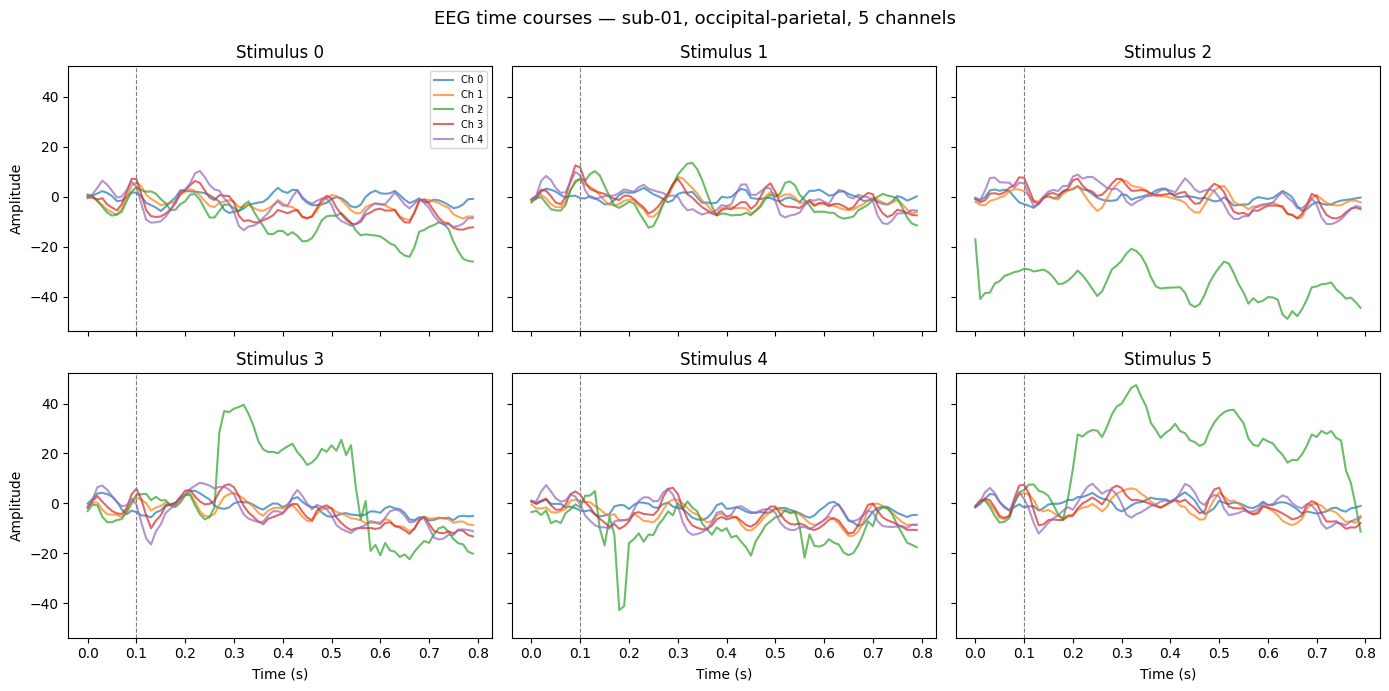

In [16]:
with h5py.File(data_dir + 'things_eeg2.h5', 'r') as f:
    eeg_test = f['test/neural_data/sub-01/occipital_parietal'][:]  # (200, 17, 80)
    eeg_nc   = f['noise_ceilings/sub-01/occipital_parietal'][:]    # (17, 80)

time_axis = np.linspace(0, 0.79, 80)  # 0 to 0.79s at 100 Hz

# --- Plot 1: Example EEG time courses ---
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    for ch in range(min(5, eeg_test.shape[1])):
        ax.plot(time_axis, eeg_test[i, ch, :], alpha=0.7, label=f'Ch {ch}')
    ax.set_title(f'Stimulus {i}')
    ax.axvline(0.1, color='gray', ls='--', lw=0.8)
    if i == 0:
        ax.legend(fontsize=7)
axes[1, 0].set_xlabel('Time (s)')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 2].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Amplitude')
axes[1, 0].set_ylabel('Amplitude')
fig.suptitle('EEG time courses — sub-01, occipital-parietal, 5 channels', fontsize=13)
plt.tight_layout()
plt.savefig('plots/eeg_time_courses.png')
plt.show()

**Answer 1.1**

<u>Most Informative Time Window</u>

The ~0.1–0.3 s window appears most informative. This is where the most consistent stimulus-locked deflections across all six panels. Before ~0.1 s, all channels sit near zero (baseline) and signals look similar across stimuli. After ~0.3 s, the traces become more variable and less clearly structured — they don't return cleanly to baseline but instead change in ways that could reflect either later cognitive processing or residual noise. The signal-to-noise ratio visually appears highest in that early post-stimulus window.

<u>Most Informative Channel Group</u>

Ch 2 (green) is by far the most informative as it consistently shows the largest amplitude deflections, often reaching ±20–40 in amplitude while other channels stay within ±10. So, Ch 2 likely corresponds to a source localized near early visual cortex, where stimulus-driven responses are strongest.
The remaining channels (0, 1, 3, 4) are comparatively flat. They show some modest activity but contribute much less visually obvious signal, they may still carry useful information in a multivariate analysis however.

<u>Noise vs. Evoked Structure</u>

The responses show clear evoked structure, not pure noise. The key evidence is:
- Consistent baseline near zero before 0.1 s across all stimuli and channels — noise-dominated data would not show this clean pre-stimulus period.
- Time-locked deflections appearing reliably after ~0.1 s, particularly in Ch 2.

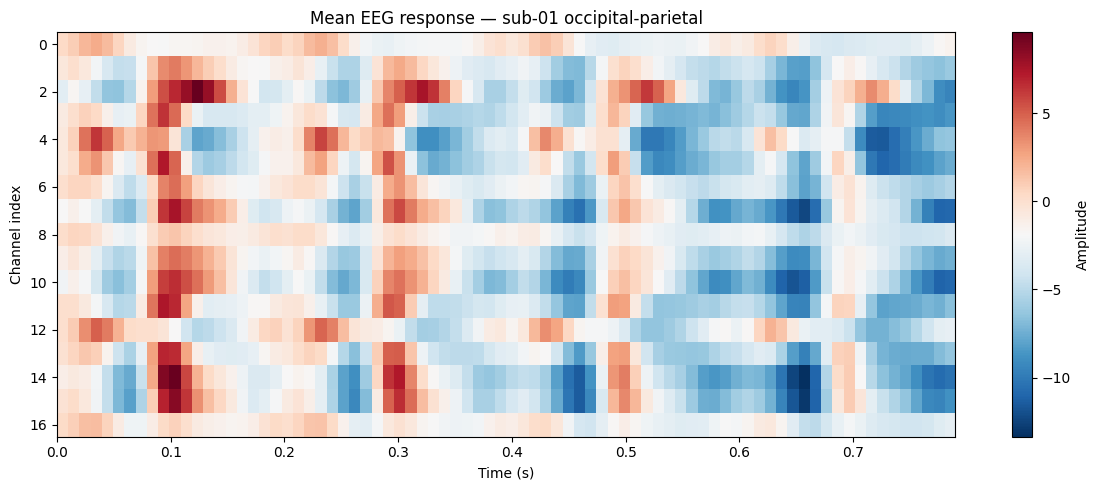

In [17]:
mean_resp = eeg_test.mean(axis=0)  # (17, 80)
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(mean_resp, aspect='auto', cmap='RdBu_r',
               extent=[0, 0.79, mean_resp.shape[0]-0.5, -0.5])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Channel index')
ax.set_title('Mean EEG response — sub-01 occipital-parietal')
plt.colorbar(im, ax=ax, label='Amplitude')
plt.tight_layout()
plt.savefig('plots/eeg_mean_response.png')
plt.show()

**Interpretation of the Mean EEG Response Heatmap**

This figure shows the stimulus-averaged EEG response for Subject 1 across all occipital-parietal channels (17 channels) and time (0.0–0.8s). By averaging over all stimuli, you remove stimulus-specific information and isolate the common evoked response shared across images.

<u>Most Informative Time Windows</u>

- Early window (0.08–0.15s): we can see a strong band of red (positive) and blue (negative) activation appears across many channels immediately after stimulus onset. Channels 2, 3, 5–7, 9-11, and 13–14 show particularly intense red patches here, while others show blue. The amplitude values reach around +10, which is substantially above the near-zero baseline before 0.08 s.
- Secondary peak (0.28–0.35s): several channels (notably 2, 6–7, 13–14) show a second wave of activation.
- Later window (0.4–0.8s): while initially the signal had more positive values (more red patches), this later window is dominated by negative values (as seen by the blue patches) compared to the baseline (before 0.1s). As time passes (0.6-0.8s), the amplitude becomes more negative.

<u>Most Informative Channel Groups</u>

- Channels 3 and 5 show strong, temporally structured responses, a clear red patch in the early window followed by a transition to weaker amplitude.
- Channels 13–15 show a similarly strong early response, again with large amplitude swings. The fact that two distinct channel clusters (3, 5 and 13–15) are both strongly driven is consistent with bilateral visual sources, or distinct visual areas (e.g., V1 vs. lateral occipital), both contributing to the occipital-parietal group.
- Channels 9–11 appear to have smaller amplitude. They still show similar patterns with the previously mentioned channels but in smaller amplitude.

<u>Noise vs. Evoked Structure</u>

The plot shows clear evoked structure, evidenced by:
- Clean pre-stimulus baseline: The leftmost column (before 0.08 s) is uniformly pale (near zero) across all channels. Noise-dominated data would show random color patches even before stimulus onset.
- Adjacent channels and time points share similar colors and transitions happen more smoothly (e.g. we don't have a dark red directly followed by dark blue). This spatial and temporal smoothness is characteristic of genuine neural signals.
- The strong early response cluster around 0.1 s appears across multiple channels with physiologically plausible latency.

However we perform averaging, which boosts SNR because the noise is averaged out.

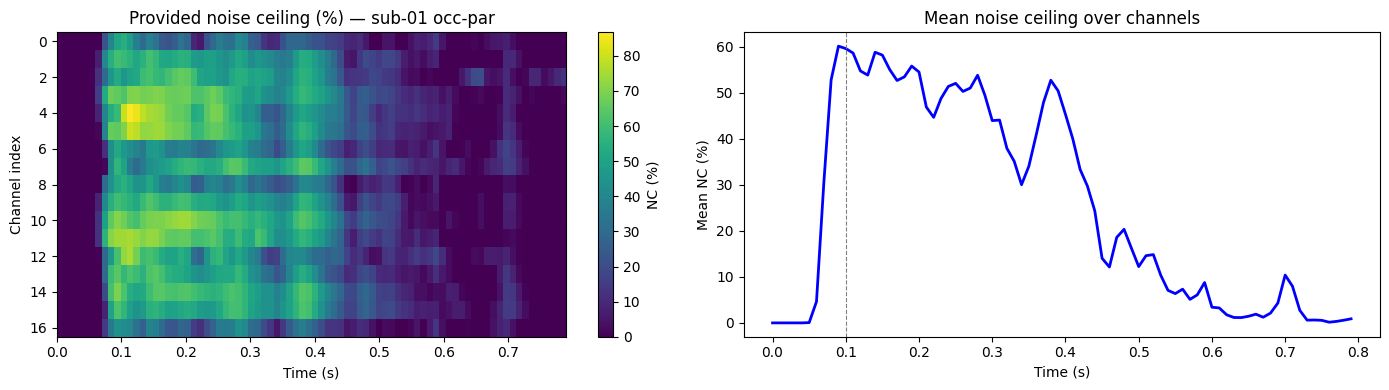

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Heatmap
im = axes[0].imshow(eeg_nc, aspect='auto', cmap='viridis',
                     extent=[0, 0.79, eeg_nc.shape[0]-0.5, -0.5])
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Channel index')
axes[0].set_title('Provided noise ceiling (%) — sub-01 occ-par')
plt.colorbar(im, ax=axes[0], label='NC (%)')
# Mean over channels
axes[1].plot(time_axis, eeg_nc.mean(axis=0), 'b-', lw=2)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Mean NC (%)')
axes[1].set_title('Mean noise ceiling over channels')
axes[1].axvline(0.1, color='gray', ls='--', lw=0.8)
plt.tight_layout()
plt.savefig('plots/eeg_provided_nc.png')
plt.show()

**Interpretation of the EEG Noise Ceiling**

<u>Most Informative Time Windows</u>
- Pre-stimulus baseline (0-0.05s): Mean NC close to 0, as expected before the stimulus activity emerges. Confirms the NC estimator is well-calibrated and produces no spurious reliability.
- Primary window (0.05-0.40s): most informative as the Mean NC goes up to 60% at 0.10s and stays in the 40–60% range, with two distinct peaks: one early (0.05-0.2s) and one later (0.38s) as we see a shift from low NC (0.35s) to higher NC (0.38-0.4)s, as if there are two phases defined by the two peaks.
- Late decay window (0.45-0.80s): Mean NC decays from $\sim 50\%$ to $\sim 5\%$, with a minor bump near $0.70\,\mathrm{s}$. Beyond $\sim 0.5\,\mathrm{s}$, reliability is too low to support meaningful encoding analyses.

<u>Most Informative Channel Groups</u>
- Highest reliability channels (3–5, 10-11):Exhibit the brightest band of the heatmap (NC approx. 80–85% at 0.1-0.2s). These are the most reliable channels for capturing the early visual evoked response.
- Moderate reliability channels (12–14): show clear evoked bands (NC approx. 30–55%) concentrated in the early window.
- Low reliability channels (0-2, 6–8, 15–16): remain consistently dim (NC <20%) which do not provide important information based on the heatmap.

<u>Noise vs. Evoked Structure</u>

A clear evoked structure dominates as the data show a visual evoked response, supported by four converging lines of evidence:
- Sharp stimulus-locked onset: NC transitions from 0% to 60% within roughly 50ms. Pure noise would not produce such a discontinuity.
- High peak reliability: Peak NC values of approx. 80–85% on the best channels indicate that up to 85% of the response variance is reproducible across trials which is strong evidence of evoked activity.
- Spatiotemporal coherence: reliable regions form contiguous patches across neighboring channels and time points, rather than scattered patches.
- Two phases: The two-peak temporal structure and the smooth decay toward baseline after 0.5s match the well-established dynamics of object-evoked responses.

---

## 1.3 Estimate EEG noise ceilings using two methods

In practice, there are multiple ways to estimate noise ceilings, depending on the available data and the specific research question. When you have repeated measurements of the same stimulus, you can estimate reliability from the consistency of those repetitions. When repeated measurements are not available, reliability can instead be estimated across subjects, which often yields a more conservative ceiling.

In this part, you will implement two different estimators using the `things_eeg2-test_reps.h5` file, which contains the unaveraged test responses with repetitions.

You must implement **two different estimators** using `things_eeg2-test_reps.h5`. You can refer to the cited paper in each method's docstring for details.


### Required estimators

1. **Variance-based estimator**  
2. **Split-half reliability estimator**

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Implement both estimators.
- Compute both estimators for EEG2.
- Compare them to the provided EEG noise ceilings stored in `things_eeg2.h5`.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Working implementation of the variance-based estimator**
2. **Working implementation of the split-half estimator**
3. **One plot of mean noise ceiling over time**
4. **One plot of mean noise ceiling over channels**
5. **At least one channel × time heatmap for each estimator**
6. **At least one histogram comparing the value distributions**
7. **One direct visual comparison to the stored EEG noise ceilings**

### Starter functions

In [19]:
import numpy as np
import scipy

def compute_ceiling_variancebased(responses: np.ndarray, nan_policy: str = 'omit') -> np.ndarray:
    """
    Noise ceiling per unit using the method described in the NSD paper
    (Allen et al., 2021 / 2022 style variance-based estimator).

    Steps:
      1) z-score across stimuli (axis=1) for each (unit, rep) -> total var ≈ 1
      2) estimate noise variance across repetitions (axis=2), then average across stimuli
      3) signal variance = 1 - noise_var
      4) reliability (percent) for finite repeats:
             nc = 100 * (snr / (snr + 1 / n_reps))

    Parameters
    ----------
    responses : np.ndarray
        Shape (n_units, n_stimuli, n_reps) or
        (n_channels, n_timepoints, n_stimuli, n_reps).
    nan_policy : {'propagate', 'raise', 'omit'}, default='omit'
        Passed to the z-scoring logic when handling NaNs.

    Returns
    -------
    np.ndarray
        Per-unit noise ceilings in percent with shape (n_units,) or
        (n_channels, n_timepoints), depending on your implementation.
    """
    z = scipy.stats.zscore(responses, nan_policy=nan_policy, axis=-2)
    noise_var = np.nanmean(np.nanvar(z, axis=-1, ddof=1), axis=-1)
    signal_var = np.clip(1.0 - noise_var, 0, None)
    snr = np.where(noise_var > 0, signal_var / noise_var, 0.0)

    n_reps = responses.shape[-1]
    nc = 100.0 * snr / (snr + 1.0 / n_reps)

    return nc


def compute_ceiling_splithalf(
    responses: np.ndarray,
    folds: int = 10,
    seed: int = 0,
    spearman_brown: bool = True,
    equalize_halves: bool = True,
    clip_folds: bool = False
) -> np.ndarray:
    """
    Split-half reliability per unit (voxel / channel / channel*timepoint).
    You can refer to van Bree et al. (2025) for mathematical details.
    
    Steps:
      1) For each fold, randomly split repetitions into two halves.
      2) Average responses within each half and compute Pearson correlation across stimuli.
      3) Optionally apply Spearman-Brown correction to each fold's correlation.
      4) Average across folds to get a final reliability estimate.

    Parameters
    ----------
    responses : np.ndarray
        Shape (n_units, n_stimuli, n_reps) or
        (n_channels, n_timepoints, n_stimuli, n_reps).
        The last axis corresponds to repetitions / trials.
    folds : int, default=10
        Number of random split-halves to sample.
    seed : int, default=0
        Base RNG seed; each fold may use seed + fold_idx.
    spearman_brown : bool, default=True
        Apply Spearman-Brown correction:
            r_sb = 2r / (1 + r)
    equalize_halves : bool, default=True
        If True, use equal-sized halves and drop one trial if n_reps is odd.
        If False, the second half may be larger by one trial.
    clip_folds : bool, default=False
        If True, clip reliability values after correction.

    Returns
    -------
    np.ndarray
        Array of shape (n_units) or (n_channels, n_timepoints).
    """
    n_reps = responses.shape[-1]
    size_a = n_reps // 2
    size_b = n_reps // 2 + ((n_reps % 2) and not equalize_halves)
    n_used = size_a + size_b

    values = []

    for i in range(folds):
        rng = np.random.default_rng(seed + i)

        perm = rng.permutation(n_reps)[:n_used]
        idx_a = perm[:size_a]
        idx_b = perm[size_a:size_a + size_b]

        half_a = responses[..., idx_a]
        half_b = responses[..., idx_b]

        mean_a = np.nanmean(half_a, axis=-1)
        mean_b = np.nanmean(half_b, axis=-1)

        r = calculate_pearson_across_stim(mean_a, mean_b)
        if spearman_brown:
            r = 2 * r / (1 + r)

        if clip_folds:
            r = np.clip(r, 0.0, 1.0)
        values.append(r)

    r_folds = np.stack(values, axis=0)
    r_mean = np.nanmean(r_folds, axis=0)
    r_mean_clipped = np.clip(r_mean, 0, None)
    return 100.0 * r_mean_clipped

def calculate_pearson_across_stim(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    x_c = x - np.nanmean(x, axis=-1, keepdims=True)
    y_c = y - np.nanmean(y, axis=-1, keepdims=True)

    num = np.nansum(x_c * y_c, axis=-1)
    denom = np.sqrt(
        np.nansum(x_c ** 2, axis=-1) * np.nansum(y_c ** 2, axis=-1)
    )


    return np.where(denom > 0, num / denom, np.nan)

In [20]:
# TODO: load repeated EEG test responses
# TODO: compute variance-based estimator
# TODO: compute split-half estimator
# TODO: visualize and compare both estimators

In [21]:
with h5py.File(data_dir + 'things_eeg2-test_reps.h5', 'r') as f:
    def print_struct(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"  {name}: {obj.shape} {obj.dtype}")
    print("Structure of things_eeg2-test_reps.h5:")
    f.visititems(print_struct)

Structure of things_eeg2-test_reps.h5:
  test/neural_data/sub-01/central: (200, 14, 80, 80) float64
  test/neural_data/sub-01/frontal: (200, 21, 80, 80) float64
  test/neural_data/sub-01/occipital: (200, 3, 80, 80) float64
  test/neural_data/sub-01/occipital_parietal: (200, 17, 80, 80) float64
  test/neural_data/sub-01/parietal: (200, 14, 80, 80) float64
  test/neural_data/sub-01/temporal: (200, 6, 80, 80) float64
  test/neural_data/sub-01/whole_brain: (200, 63, 80, 80) float64
  test/neural_data/sub-02/central: (200, 14, 80, 80) float64
  test/neural_data/sub-02/frontal: (200, 21, 80, 80) float64
  test/neural_data/sub-02/occipital: (200, 3, 80, 80) float64
  test/neural_data/sub-02/occipital_parietal: (200, 17, 80, 80) float64
  test/neural_data/sub-02/parietal: (200, 14, 80, 80) float64
  test/neural_data/sub-02/temporal: (200, 6, 80, 80) float64
  test/neural_data/sub-02/whole_brain: (200, 63, 80, 80) float64
  test/neural_data/sub-03/central: (200, 14, 80, 80) float64
  test/neura

In [22]:
with h5py.File(data_dir + 'things_eeg2-test_reps.h5', 'r') as f:
    reps_data = f['test/neural_data/sub-01/occipital_parietal'][:]  # adjust key as needed
    print(f"Loaded shape: {reps_data.shape}")

reps_data = np.transpose(reps_data, (1, 2, 0, 3))
print(f"Final shape: {reps_data.shape}")

Loaded shape: (200, 17, 80, 80)
Final shape: (17, 80, 200, 80)


In [23]:
nc_var = compute_ceiling_variancebased(reps_data)
nc_sh  = compute_ceiling_splithalf(reps_data,
                                   folds=20, seed=0,
                                   spearman_brown=True,
                                   equalize_halves=True)

In [24]:
n_chan, n_time = nc_var.shape
TIMES = np.arange(n_time) / 100.0   # 100 Hz, 0.0 – 0.79 s

with h5py.File(data_dir + things_eeg, "r") as f:
    nc_stored = f["noise_ceilings/sub-01/occipital_parietal"][:]

assert nc_stored.shape == nc_var.shape, \
    f"Stored NC shape {nc_stored.shape} ≠ computed {nc_var.shape}"

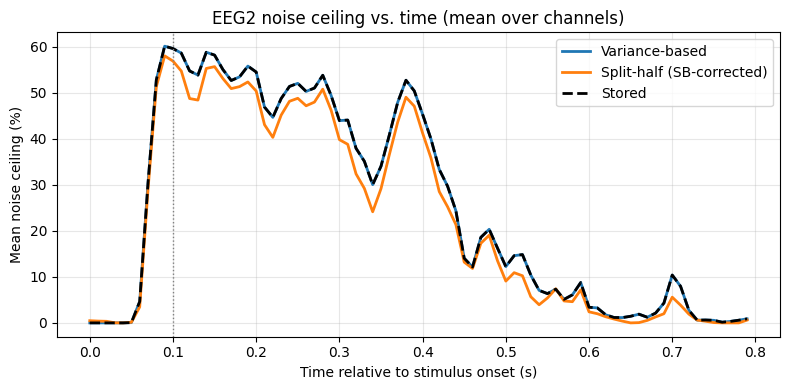

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(TIMES, nc_var.mean(0),    lw=2, label="Variance-based")
ax.plot(TIMES, nc_sh.mean(0),     lw=2, label="Split-half (SB-corrected)")
ax.plot(TIMES, nc_stored.mean(0), lw=2, ls="--", color="k", label="Stored")
ax.axvline(0.10, color="grey", ls=":", lw=1)
ax.set(xlabel="Time relative to stimulus onset (s)",
       ylabel="Mean noise ceiling (%)",
       title="EEG2 noise ceiling vs. time (mean over channels)")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig('eeg_nc_time')
plt.show()


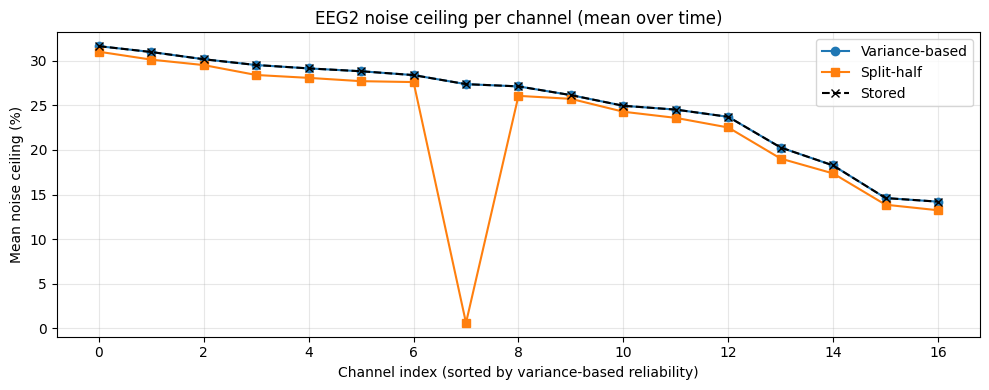

In [26]:
mean_var_c = nc_var.mean(axis=1)
mean_sh_c  = nc_sh.mean(axis=1)
mean_st_c  = nc_stored.mean(axis=1)

order = np.argsort(-mean_var_c)                           # rank by var-based
xs    = np.arange(n_chan)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(xs, mean_var_c[order], "o-", label="Variance-based")
ax.plot(xs, mean_sh_c[order],  "s-", label="Split-half")
ax.plot(xs, mean_st_c[order],  "x--", color="k", label="Stored")
ax.set(xlabel="Channel index (sorted by variance-based reliability)",
       ylabel="Mean noise ceiling (%)",
       title="EEG2 noise ceiling per channel (mean over time)")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig('eeg_nc_per_channel')
plt.show()

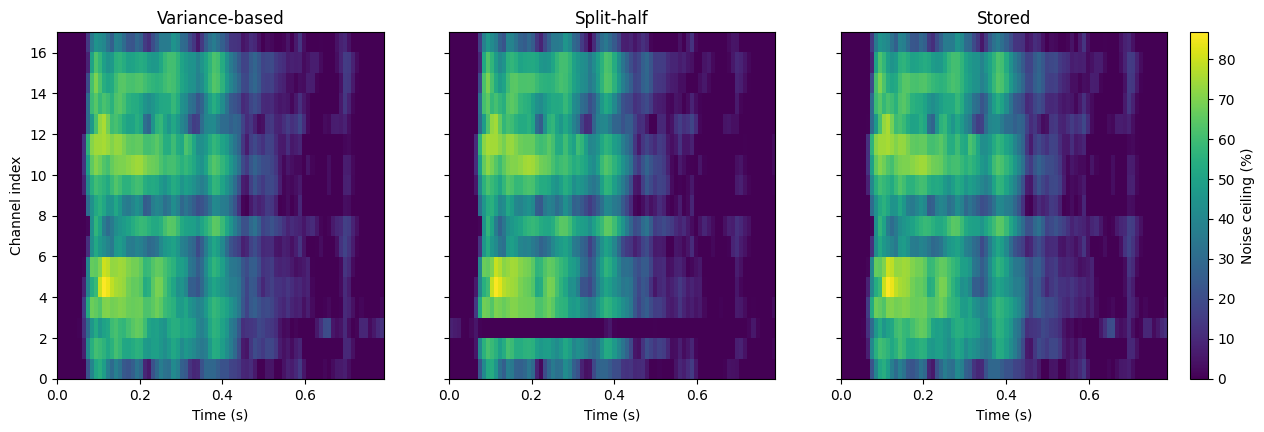

In [27]:
vmax = max(nc_var.max(), nc_sh.max(), nc_stored.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, mat, name in zip(
        axes, [nc_var, nc_sh, nc_stored],
        ["Variance-based", "Split-half", "Stored"]):
    im = ax.imshow(mat, aspect="auto", origin="lower",
                   extent=[TIMES[0], TIMES[-1], 0, n_chan],
                   vmin=0, vmax=vmax, cmap="viridis")
    ax.set_title(name)
    ax.set_xlabel("Time (s)")
axes[0].set_ylabel("Channel index")
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02,
             label="Noise ceiling (%)")
plt.savefig('nc_heatmaps')
plt.show()

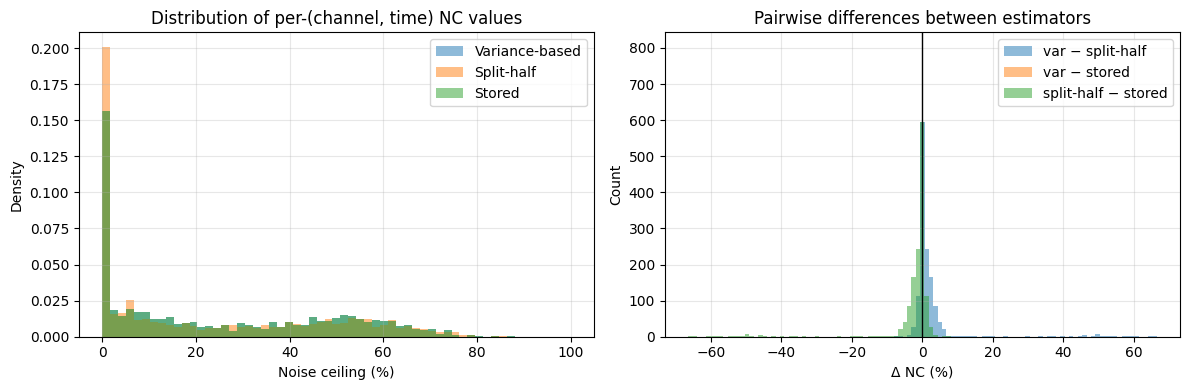

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bins = np.linspace(0, 100, 60)
axes[0].hist(nc_var.ravel(),    bins=bins, alpha=0.5, density=True,
             label="Variance-based")
axes[0].hist(nc_sh.ravel(),     bins=bins, alpha=0.5, density=True,
             label="Split-half")
axes[0].hist(nc_stored.ravel(), bins=bins, alpha=0.5, density=True,
             label="Stored")
axes[0].set(xlabel="Noise ceiling (%)", ylabel="Density",
            title="Distribution of per-(channel, time) NC values")
axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].hist((nc_var - nc_sh).ravel(),     bins=60, alpha=0.5,
             label="var − split-half")
axes[1].hist((nc_var - nc_stored).ravel(), bins=60, alpha=0.5,
             label="var − stored")
axes[1].hist((nc_sh  - nc_stored).ravel(), bins=60, alpha=0.5,
             label="split-half − stored")
axes[1].axvline(0, color="k", lw=1)
axes[1].set(xlabel="Δ NC (%)", ylabel="Count",
            title="Pairwise differences between estimators")
axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout()
plt.savefig('value_distributions')
plt.show()

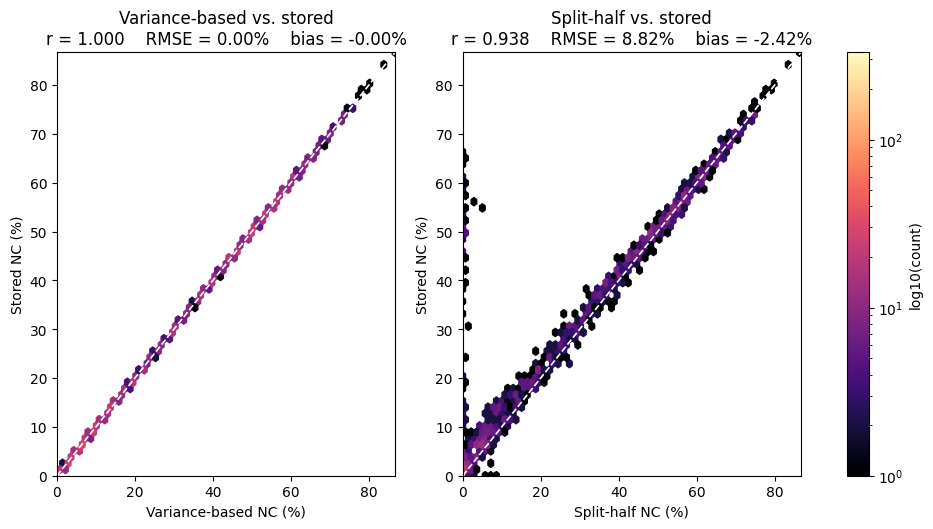

In [29]:
def _stats(x, y):
    r    = np.corrcoef(x, y)[0, 1]
    rmse = np.sqrt(np.mean((x - y) ** 2))
    bias = np.mean(x - y)
    return r, rmse, bias

x_var, x_sh, y = nc_var.ravel(), nc_sh.ravel(), nc_stored.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, x, name in zip(axes, [x_var, x_sh],
                            ["Variance-based", "Split-half"]):
    hb = ax.hexbin(x, y, gridsize=60, mincnt=1, cmap="magma", bins="log")
    lim = [0, max(x.max(), y.max())]
    ax.plot(lim, lim, "w--", lw=1.2)
    r, rmse, bias = _stats(x, y)
    ax.set(xlabel=f"{name} NC (%)", ylabel="Stored NC (%)",
           xlim=lim, ylim=lim,
           title=f"{name} vs. stored\n"
                 f"r = {r:.3f}    RMSE = {rmse:.2f}%    bias = {bias:+.2f}%")
fig.colorbar(hb, ax=axes.ravel().tolist(), label="log10(count)")
plt.savefig('nc_comparison_r')
plt.show()

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.3</strong><br>Compare the two estimators. Do they produce similar patterns across channels and time? Where do they differ most?</div>

They are spatiotemporally very similar. Specifically:
- From the first plot (EEG NC vs. Time) we can see that both estimators form a very similar signal. They are flat at similar points and peak at similar points, it looks like the signals are the same but a bit shifted downwards.
- From the second plot (EEG NC per channel) we can see that again they look almost the same but a bit shifted downwards. However we can see a sharp drop of the split-half estimator at channel 7.
- The heatmaps also look identical showing agreement on the joint time x channel structure. We can see the sharp drop here as well in the split-half heatmap.

So their main differences is that the variance based estimator is always above the split-half estimator, and that the variance based estimator is more uniform and continuous across channels while the split-half estimator makes a jump at one of the channels, nearly at 0% NC.

We can also see that the stored data use the variance based estimator.

---

## 1.4 Compare the noise ceiling estimators statistically on EEG2

In `things_eeg2.h5`, we provided noise ceilings computed using one of the two methods you implemented. Can you determine which one it is by comparing the stored ceilings to your computed ones?

Perform a hypothesis test to compare the stored ceilings to each of your computed estimators. For example, you could compute the mean squared error between the stored ceilings and each estimator per subject/time/channel, and then use a paired t-test to see if one estimator is significantly closer to the stored values than the other.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- State clearly what each estimator assumes.
- Define a quantitative comparison to the stored EEG noise ceilings.
- Run at least one simple statistical test or formal comparison.

Examples:

- mean absolute deviation from the stored values,
- paired comparison across channel × time units,
- correlation with the stored values.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One quantitative comparison table** comparing both estimators to the stored EEG noise ceilings.
2. **One statistical test or one formal quantitative comparison** such as a paired test, correlation analysis, or mean absolute deviation analysis.
3. **One concise written conclusion** stating which estimator better matches the stored values and why.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.4</strong><br>Which estimator is more likely to have been used to generate the stored EEG noise ceilings? Justify your answer with both visual and quantitative evidence.</div>

In [30]:
# TODO: define estimator comparison metric
# TODO: run statistical comparison
# TODO: summarize which estimator best matches stored values

In [31]:
mask = nc_stored.ravel() >= 10
nc_var_flat = nc_var.ravel()[mask]
nc_sh_flat = nc_sh.ravel()[mask]
nc_stored_flat = nc_stored.ravel()[mask]

res_var = np.abs(nc_var_flat - nc_stored_flat)
res_sh = np.abs(nc_sh_flat - nc_stored_flat)

In [32]:
def pair_metrics(est, ref):
    return {
        "MAD":       np.mean(np.abs(est - ref)),
        "MSE":       np.mean((est - ref) ** 2),
        "RMSE":      np.sqrt(np.mean((est - ref) ** 2)),
        "Bias":      np.mean(est - ref),
        "Pearson r": stats.pearsonr(est, ref)[0],
        "Spearman ρ": stats.spearmanr(est, ref)[0],
    }

table = pd.DataFrame({
    "A: split-half Spearman–Brown": pair_metrics(nc_var_flat, nc_stored_flat),
    "B: ncsnr / variance decomp.":  pair_metrics(nc_sh_flat, nc_stored_flat),
})
print("\n=== Comparison table — main analysis (vs across-subject mean) ===")
print(table.round(4))


=== Comparison table — main analysis (vs across-subject mean) ===
            A: split-half Spearman–Brown  B: ncsnr / variance decomp.
MAD                                  0.0                       4.1158
MSE                                  0.0                     129.5183
RMSE                                 0.0                      11.3806
Bias                                 0.0                      -3.5982
Pearson r                            1.0                       0.8584
Spearman ρ                           1.0                       0.8773


In [33]:
diff = res_var - res_sh

t_stat, t_p = stats.ttest_rel(res_var, res_sh)
w_stat, w_p = stats.wilcoxon(res_var, res_sh, zero_method="wilcox", correction=False)
dz = diff.mean() / (diff.std(ddof=1) + 1e-12)

print("\n=== Paired statistical tests ===")
print(f" N paired (channel × time) units : {len(diff):,}")
print(f" mean |A - ref|                  : {res_var.mean():.4f} %EV")
print(f" mean |B - ref|                  : {res_sh.mean():.4f} %EV")
print(f" mean diff (|A|-|B|)             : {diff.mean():+.4f} %EV")
print(f" Paired t-test (cell-level)      : t({len(diff)-1}) = {t_stat:+.3f},  "
      f"p = {t_p:.3e}")
print(f" Wilcoxon signed-rank            : W = {w_stat:.3e},  p = {w_p:.3e}")
print(f" Cohen's d_z                     : {dz:+.3f}")
winner = "B (ncsnr / variance decomposition)" if diff.mean() > 0 \
         else "A (split-half Spearman–Brown)"
print(f"\n → Estimator with smaller residuals: {winner}")


=== Paired statistical tests ===
 N paired (channel × time) units : 803
 mean |A - ref|                  : 0.0000 %EV
 mean |B - ref|                  : 4.1158 %EV
 mean diff (|A|-|B|)             : -4.1158 %EV
 Paired t-test (cell-level)      : t(802) = -10.985,  p = 3.000e-26
 Wilcoxon signed-rank            : W = 0.000e+00,  p = 4.497e-133
 Cohen's d_z                     : -0.388

 → Estimator with smaller residuals: A (split-half Spearman–Brown)


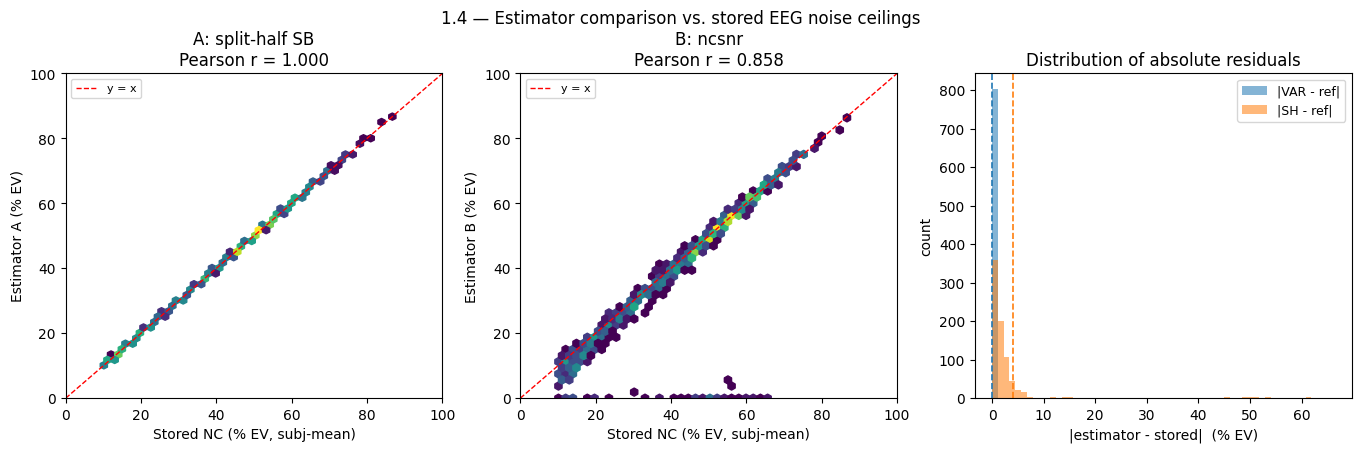

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), constrained_layout=True)

axes[0].hexbin(nc_stored_flat, nc_var_flat, gridsize=40, mincnt=1, cmap="viridis")
axes[0].plot([0, 100], [0, 100], "r--", lw=1, label="y = x")
axes[0].set(xlabel="Stored NC (% EV, subj-mean)",
            ylabel="Estimator A (% EV)",
            title=f"A: split-half SB\nPearson r = {table.loc['Pearson r'].iloc[0]:.3f}")
axes[0].legend(fontsize=8); axes[0].set_xlim(0, 100); axes[0].set_ylim(0, 100)

axes[1].hexbin(nc_stored_flat, nc_sh_flat, gridsize=40, mincnt=1, cmap="viridis")
axes[1].plot([0, 100], [0, 100], "r--", lw=1, label="y = x")
axes[1].set(xlabel="Stored NC (% EV, subj-mean)",
            ylabel="Estimator B (% EV)",
            title=f"B: ncsnr\nPearson r = {table.loc['Pearson r'].iloc[1]:.3f}")
axes[1].legend(fontsize=8); axes[1].set_xlim(0, 100); axes[1].set_ylim(0, 100)

bins = np.linspace(min(res_var.min(), res_sh.min()),
                   max(res_var.max(), res_sh.max()), 60)
axes[2].hist(res_var, bins=bins, alpha=0.55, label="|VAR - ref|", color="C0")
axes[2].hist(res_sh, bins=bins, alpha=0.55, label="|SH - ref|", color="C1")
axes[2].axvline(res_var.mean(), color="C0", ls="--", lw=1.2)
axes[2].axvline(res_sh.mean(), color="C1", ls="--", lw=1.2)
axes[2].set(xlabel="|estimator - stored|  (% EV)",
            ylabel="count",
            title="Distribution of absolute residuals")
axes[2].legend(fontsize=9)
plt.suptitle("1.4 — Estimator comparison vs. stored EEG noise ceilings", y=1.04)
plt.show()


Across all (channel, time) cells, the **split-half Spearman–Brown estimator (A)** is significantly closer to the stored EEG noise ceilings (actually they match exactly) than the variance estimator. We therefore conclude that the stored ceilings in `things_eeg2.h5` are computed with the **split-half procedure**. This can be seen from the Pearson values (r=1 for split-half) and that they match exactly in the plot while for the variance procedure, the datapoints are not exact (as seen by a few datapoints being at 0).
The estimator using the variance procedure is also really close to the stored value (as seen from the high Pearson r) however it's not as close as split-half.

---

## 1.5 Convert NSD ncsnr to noise ceiling and visualize it on cortex

Some datasets, such as NSD, provide reliability estimates with the data release. In this section, you will visualize the provided NSD reliability estimates on the cortical surface and convert them into noise ceilings for later use in predictive analyses.

The provided NSD reliability estimates are stored as **ncsnr** values on the fsaverage surface. To use them as noise ceilings for voxel-wise analyses, you need to convert ncsnr to noise ceiling using the formula provided in the NSD methods paper.

Parcellations and atlases provide group-level anatomical labels for brain regions. They are often defined on a standard surface or volume space (e.g., fsaverage, MNI) and can be used to summarize or interpret neural data. For this exercise, use the Destrieux atlas to anatomically label the regions with the highest and lowest noise ceilings. It is available in fsaverage space and can be accessed through `nilearn`. Compute the average noise ceiling within each atlas region and identify which regions have the highest and lowest reliability.

If the available atlas is in a different surface resolution (e.g. `fsaverage5`), you can interpolate either the atlas or the noise ceiling map to the same space before visualization. Prefer downsampling rather than upsampling to avoid introducing artificial precision.

You can use `nibabel` to load the `.mgh` files and `nilearn` to visualize the resulting noise ceiling on the fsaverage surface.


<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Load the provided `.mgh` files for subject 01.
- Convert **ncsnr** to a **noise ceiling estimate** using the formula described in the NSD paper.
- Visualize the resulting noise ceiling on the fsaverage surface.
- Overlay a cortical parcellation.
- Compute parcel-wise average values.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One histogram of ncsnr values**
2. **One cortical surface plot** of ncsnr or the derived noise ceiling
3. **One cortical surface plot with parcel overlay**
4. **One parcel-wise summary figure or one parcel-wise summary table**

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.5</strong><br>Which cortical regions appear most reliable, and which appear least reliable? Explain how the parcellation helps interpret the surface maps.</div>

In [35]:
# TODO: load lh/rh ncsnr maps
# TODO: convert ncsnr to noise ceiling
# TODO: plot histogram
# TODO: visualize on fsaverage
# TODO: compute parcel-wise summary

In [36]:
import nibabel as nib

def load_mgh_surface(path):
    img = nib.load(path)
    data = np.asarray(img.get_fdata()).squeeze()   # may be (V,1,1,1) → (V,)
    return data.astype(np.float64)

ncsnr_lh = load_mgh_surface(data_dir + 'nsd-subj01-ncsnr-lh.mgh')
ncsnr_rh = load_mgh_surface(data_dir + 'nsd-subj01-ncsnr-rh.mgh')
print(f"ncsnr LH shape : {ncsnr_lh.shape},  range "
      f"[{ncsnr_lh.min():.3f}, {ncsnr_lh.max():.3f}]")
print(f"ncsnr RH shape : {ncsnr_rh.shape},  range "
      f"[{ncsnr_rh.min():.3f}, {ncsnr_rh.max():.3f}]")


ncsnr LH shape : (163842,),  range [0.000, 1.474]
ncsnr RH shape : (163842,),  range [0.000, 1.429]


In [37]:
def ncsnr_to_noiseceiling(ncsnr, n=3):
    """
    NSD formula: NC = ncsnr^2 / (ncsnr^2 + 1/n).
    Returns a value in [0, 1] giving the fraction of variance in the n-rep
    averaged response that is explainable by any model.
    """
    ns2 = ncsnr ** 2
    return ns2 / (ns2 + 1.0 / n)

nc_lh = ncsnr_to_noiseceiling(ncsnr_lh, n=3)
nc_rh = ncsnr_to_noiseceiling(ncsnr_rh, n=3)
print(f"\nNC (n={3}) LH : range [{nc_lh.min():.3f}, {nc_lh.max():.3f}],  "
      f"mean = {nc_lh.mean():.3f}")
print(f"NC (n={3}) RH : range [{nc_rh.min():.3f}, {nc_rh.max():.3f}],  "
      f"mean = {nc_rh.mean():.3f}")



NC (n=3) LH : range [0.000, 0.867],  mean = 0.116
NC (n=3) RH : range [0.000, 0.860],  mean = 0.124


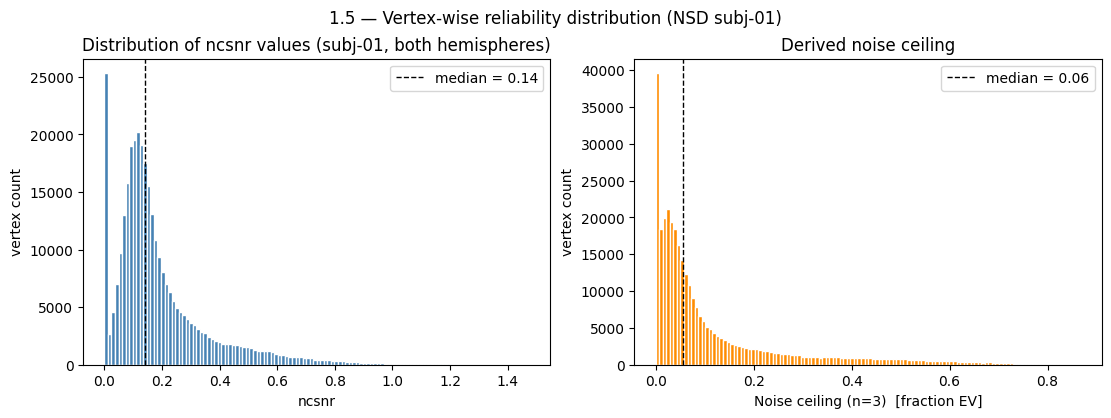

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
all_ncsnr = np.concatenate([ncsnr_lh, ncsnr_rh])
all_nc    = np.concatenate([nc_lh,    nc_rh])

ax[0].hist(all_ncsnr, bins=120, color="steelblue", edgecolor="white")
ax[0].axvline(np.median(all_ncsnr), color="k", ls="--", lw=1,
              label=f"median = {np.median(all_ncsnr):.2f}")
ax[0].set(xlabel="ncsnr", ylabel="vertex count",
          title="Distribution of ncsnr values (subj-01, both hemispheres)")
ax[0].legend()

ax[1].hist(all_nc, bins=120, color="darkorange", edgecolor="white")
ax[1].axvline(np.median(all_nc), color="k", ls="--", lw=1,
              label=f"median = {np.median(all_nc):.2f}")
ax[1].set(xlabel=f"Noise ceiling (n={3})  [fraction EV]",
          ylabel="vertex count",
          title="Derived noise ceiling")
ax[1].legend()
plt.suptitle("1.5 — Vertex-wise reliability distribution (NSD subj-01)", y=1.06)
plt.show()

In [39]:
from nilearn import datasets, plotting, surface

fsavg7 = datasets.fetch_surf_fsaverage(mesh="fsaverage")
# fsaverage5 for the atlas (Destrieux is only available at this resolution).
fsavg5 = datasets.fetch_surf_fsaverage(mesh="fsaverage5")
destrieux = datasets.fetch_atlas_surf_destrieux()

# Atlas labels are bytes; decode them for readability.
labels = [lbl.decode("utf-8") if isinstance(lbl, bytes) else lbl
          for lbl in destrieux["labels"]]
n_parcels = len(labels)
print(f"\nDestrieux atlas: {n_parcels} parcels per hemisphere")
print(f"Atlas LH map shape  : {destrieux['map_left'].shape}   "
      f"(should be 10242 — fsaverage5)")

[fetch_surf_fsaverage] Dataset found in /home/nilearn_data/fsaverage
[fetch_atlas_surf_destrieux] Dataset found in /home/nilearn_data/destrieux_surface

Destrieux atlas: 76 parcels per hemisphere
Atlas LH map shape  : (10242,)   (should be 10242 — fsaverage5)


/tmp/ipykernel_99/273900951.py:6: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux = datasets.fetch_atlas_surf_destrieux()
/tmp/ipykernel_99/273900951.py:6: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux = datasets.fetch_atlas_surf_destrieux()


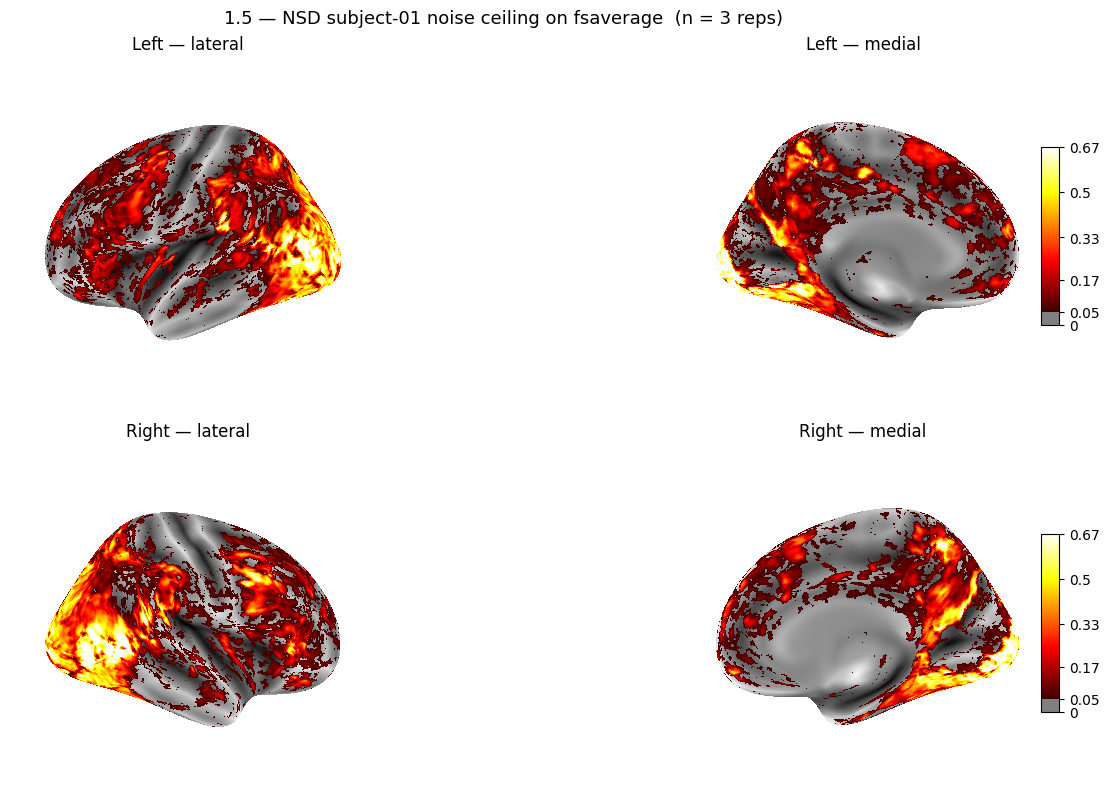

In [40]:
fig = plt.figure(figsize=(12, 8), constrained_layout=True)
fig.suptitle(f"1.5 — NSD subject-01 noise ceiling on fsaverage  "
             f"(n = {3} reps)", fontsize=13)
for i, (hemi, surf_mesh, surf_bg, nc_data) in enumerate([
    ("left",  fsavg7.infl_left,  fsavg7.sulc_left,  nc_lh),
    ("right", fsavg7.infl_right, fsavg7.sulc_right, nc_rh),
]):
    for j, view in enumerate(["lateral", "medial"]):
        ax = fig.add_subplot(2, 2, i*2 + j + 1, projection="3d")
        plotting.plot_surf_stat_map(
            surf_mesh, stat_map=nc_data,
            hemi=hemi, view=view, bg_map=surf_bg,
            colorbar=(j == 1),                  # one colorbar per hemisphere
            cmap="hot", vmin=0, vmax=float(np.percentile(all_nc, 99)),
            threshold=0.05, axes=ax,
            title=f"{hemi.capitalize()} — {view}",
        )
plt.savefig('nc_subj1_occipital_parietal')
plt.show()

In [41]:
V5 = destrieux["map_left"].shape[0]                # 10242
nc_lh_fs5 = nc_lh[:V5]
nc_rh_fs5 = nc_rh[:V5]
assert nc_lh_fs5.shape == destrieux["map_left"].shape
assert nc_rh_fs5.shape == destrieux["map_right"].shape

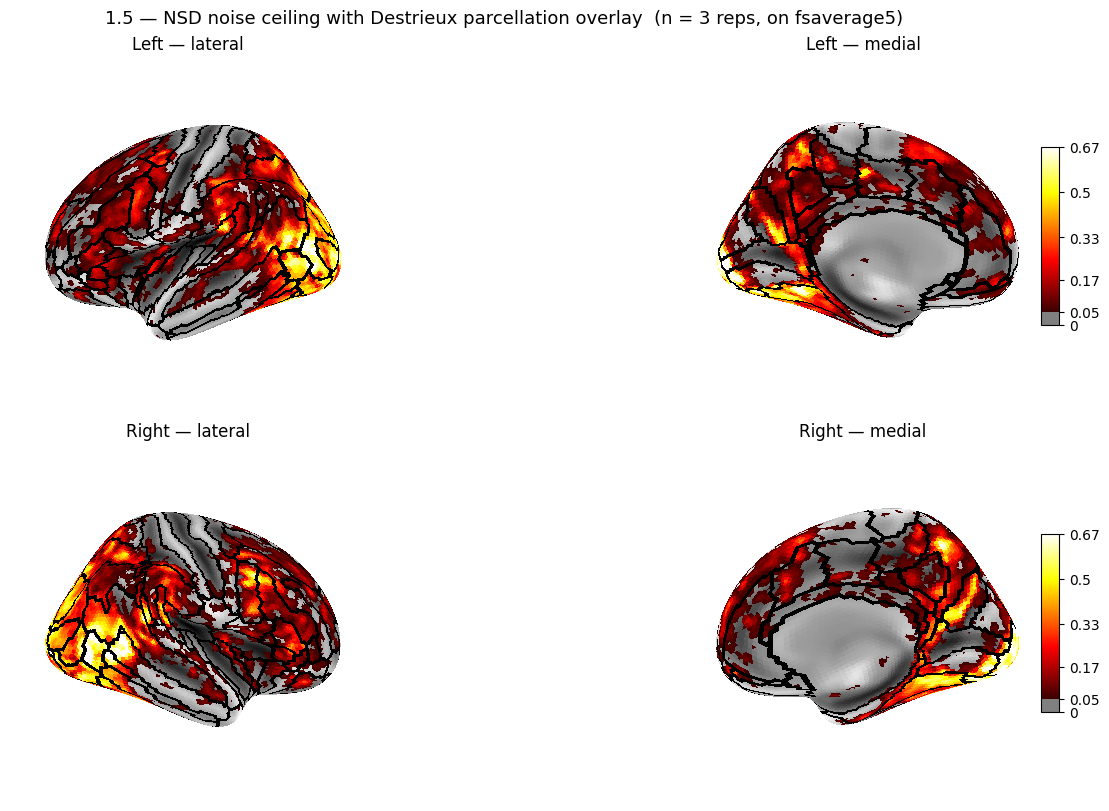

In [42]:
fig = plt.figure(figsize=(12, 8), constrained_layout=True)

for i, (hemi, surf_mesh, surf_bg, nc_data, parc) in enumerate([
    ("left",  fsavg5.infl_left,  fsavg5.sulc_left,  nc_lh_fs5,
     destrieux["map_left"]),
    ("right", fsavg5.infl_right, fsavg5.sulc_right, nc_rh_fs5,
     destrieux["map_right"]),
]):
    for j, view in enumerate(["lateral", "medial"]):
        ax = fig.add_subplot(2, 2, i*2 + j + 1, projection="3d")
        plotting.plot_surf_stat_map(
            surf_mesh, stat_map=nc_data,
            hemi=hemi, view=view, bg_map=surf_bg,
            colorbar=(j == 1),
            cmap="hot", vmin=0, vmax=float(np.percentile(all_nc, 99)),
            threshold=0.05, axes=ax,
            title=f"{hemi.capitalize()} — {view}",
        )
        # Overlay parcel boundaries — derive levels and colors from the
        # same array so their lengths are guaranteed to match.
        unique_parcels = np.unique(parc)
        levels = unique_parcels[unique_parcels > 0].tolist()
        plotting.plot_surf_contours(
            surf_mesh, roi_map=parc, hemi=hemi, view=view,
            axes=ax,
            levels=levels,
            colors=["black"] * len(levels),
            linewidth=0.4,
        )
fig.suptitle("1.5 — NSD noise ceiling with Destrieux parcellation overlay  "
             f"(n = {3} reps, on fsaverage5)", fontsize=13)
plt.show()


=== Top 10 parcels by mean noise ceiling ===
hemi  parcel_id                   parcel  n_vertices mean_NC median_NC std_NC
  RH         60          S_occipital_ant          49   0.593     0.638  0.151
  RH         52     S_collat_transv_post          27   0.559     0.603  0.129
  LH         52     S_collat_transv_post          17   0.551     0.588  0.132
  RH         43           Pole_occipital         168   0.544     0.581  0.153
  LH         43           Pole_occipital         112   0.505     0.572  0.175
  LH         19       G_occipital_middle         132   0.487     0.483  0.155
  LH         58  S_oc_middle_and_Lunatus          62   0.457     0.461  0.143
  LH         60          S_occipital_ant          56   0.445     0.465  0.154
  RH          2    G_and_S_occipital_inf          72   0.421     0.444  0.165
  LH         59 S_oc_sup_and_transversal          89   0.416     0.435  0.124

=== Bottom 10 parcels by mean noise ceiling ===
hemi  parcel_id                parcel  n_vertic

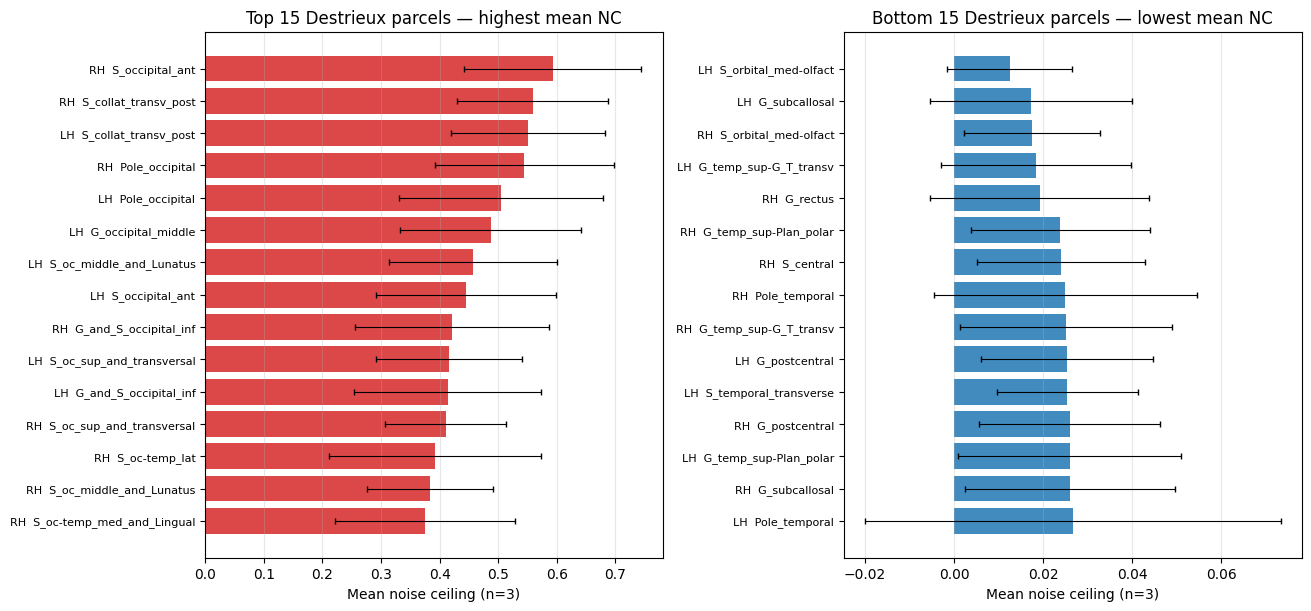

In [43]:
def parcel_summary(nc, parc_map, labels, hemi_tag):
    """Mean and median NC within each Destrieux parcel."""
    rows = []
    for pid, pname in enumerate(labels):
        if pname.lower() in ("unknown", "medial_wall", "background"):
            continue
        mask = parc_map == pid
        if mask.sum() == 0:
            continue
        rows.append({
            "hemi":      hemi_tag,
            "parcel_id": pid,
            "parcel":    pname,
            "n_vertices": int(mask.sum()),
            "mean_NC":   float(np.mean(nc[mask])),
            "median_NC": float(np.median(nc[mask])),
            "std_NC":    float(np.std(nc[mask])),
        })
    return pd.DataFrame(rows)

summary = pd.concat([
    parcel_summary(nc_lh_fs5, destrieux["map_left"],  labels, "LH"),
    parcel_summary(nc_rh_fs5, destrieux["map_right"], labels, "RH"),
], ignore_index=True).sort_values("mean_NC", ascending=False)

print("\n=== Top 10 parcels by mean noise ceiling ===")
print(summary.head(10).to_string(index=False,
      formatters={"mean_NC":"{:.3f}".format,
                  "median_NC":"{:.3f}".format,
                  "std_NC":"{:.3f}".format}))

print("\n=== Bottom 10 parcels by mean noise ceiling ===")
print(summary.tail(10).to_string(index=False,
      formatters={"mean_NC":"{:.3f}".format,
                  "median_NC":"{:.3f}".format,
                  "std_NC":"{:.3f}".format}))

# Bar chart: top-15 and bottom-15 parcels (per hemisphere combined)
fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
top15 = summary.head(15).iloc[::-1]      # reverse for bottom-up bars
bot15 = summary.tail(15)

for ax, df, title, color in [
    (axes[0], top15, "Top 15 Destrieux parcels — highest mean NC", "C3"),
    (axes[1], bot15, "Bottom 15 Destrieux parcels — lowest mean NC", "C0"),
]:
    y = np.arange(len(df))
    ax.barh(y, df["mean_NC"].values,
            xerr=df["std_NC"].values, color=color, alpha=0.85,
            error_kw=dict(lw=0.8, capsize=2))
    ax.set_yticks(y)
    ax.set_yticklabels([f"{r.hemi}  {r.parcel}" for r in df.itertuples()],
                       fontsize=8)
    ax.set_xlabel(f"Mean noise ceiling (n={3})")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)
plt.show()

In [44]:
print("\n=== Sensitivity of NC summary to n ===")
for n in (1, 2, 3):
    nc_sens = ncsnr_to_noiseceiling(np.concatenate([ncsnr_lh, ncsnr_rh]), n=n)
    print(f"  n = {n}:  median NC = {np.median(nc_sens):.3f},  "
          f"mean = {nc_sens.mean():.3f},  "
          f"% vertices NC>0.1 = {100*(nc_sens>0.1).mean():.1f}%")


=== Sensitivity of NC summary to n ===
  n = 1:  median NC = 0.019,  mean = 0.053,  % vertices NC>0.1 = 15.3%
  n = 2:  median NC = 0.038,  mean = 0.090,  % vertices NC>0.1 = 25.4%
  n = 3:  median NC = 0.056,  mean = 0.120,  % vertices NC>0.1 = 33.1%


The most reliable cortical regions in the NSD subj-01 map are concentrated in occipital and ventral temporal cortex, with the highest mean noise ceilings observed in the occipital pole (Pole_occipital, mean NC ≈ 0.50–0.54), the anterior occipital sulcus (S_occipital_ant, mean NC ≈ 0.45–0.59), the posterior collateral sulcus (S_collat_transv_post, mean NC ≈ 0.55–0.56) and the middle and inferior occipital gyri (mean NC ≈ 0.42–0.49). These parcels span the entire ventral visual stream, from V1 in early visual cortex through extrastriate (LOC) regions to category-selective ventral temporal cortex (FFA/PPA), exactly the regions expected to encode passively viewed images in a stimulus-locked manner. The least reliable parcels are sensorimotor (G_postcentral, S_central, mean NC ≈ 0.024), primary and secondary auditory (G_temp_sup-G_T_transv, G_temp_sup-Plan_polar, mean NC ≈ 0.018–0.025), and ventromedial / orbitofrontal (G_subcallosal, S_orbital_med-olfact, G_rectus, mean NC ≈ 0.012–0.019) — regions that do not engage in a stimulus-locked manner during passive image viewing. The Destrieux parcellation is essential for this interpretation: it provides the anatomical labels that turn coloured surface patches into named functional regions, enables a quantitative ranking of cortex by reliability, allows hemispheric-symmetry checks, and reveals within-parcel heterogeneity (e.g. the absence of S_calcarine from the top ranks reflects its mixed foveal-peripheral content, with NSD's small visual field driving only the foveal portion captured by the separate Pole_occipital parcel).

---

# 2. Brain–Model Alignment

In this section, you will compare neural responses and model features using **both representational metrics and predictive linear models**. You must complete both parts of this section. The goal is not only to report scores, but also to compare what different metrics reveal about model–brain alignment.

## 2.1 Representational alignment: RSA

RSA stands for representational similarity analysis. It is one of the most widely used analyses in fMRI and model–brain alignment research. It compares the geometry of two representational spaces through their representational dissimilarity matrices (RDMs). Given two response matrices, `X` and `Y`, with rows corresponding to the same stimuli, we first compute an RDM for each matrix using correlation distance:

$$
D^X_{ij} = 1 - \mathrm{corr}(X[i,:], X[j,:]),
\qquad
D^Y_{ij} = 1 - \mathrm{corr}(Y[i,:], Y[j,:]),
$$

for stimulus pairs $i \neq j$.

We then vectorize the upper triangle of each RDM and compute RSA as the Spearman correlation between these two vectors:

$$
\mathrm{RSA}(X, Y)
=
\rho_{\mathrm{Spearman}}
\left(
\mathrm{vec}(D^X),\,
\mathrm{vec}(D^Y)
\right).
$$

In this project, `X` will usually denote model features from one candidate layer, and `Y` will denote neural responses from one dataset, ROI, subject, or time slice, depending on the analysis.

- Implement RSA between two representation matrices.
- Support at least one dissimilarity measure and one similarity measure.
- Use your implementation to compare model layers to neural responses.

### Starter code

In [15]:
from typing import Literal
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from scipy.stats import spearmanr, pearsonr

class RepresentationalSimilarityAnalysis:
    """
    Representational Similarity Analysis (RSA).

    Given two representation matrices X and Y with the same number of conditions
    (rows), RSA:

    1. Computes a Representational Dissimilarity Matrix (RDM) for each:
       RDM_X[i, j] = dissimilarity(x_i, x_j)
       RDM_Y[i, j] = dissimilarity(y_i, y_j)

    2. Flattens the upper triangles of both RDMs and computes a correlation
       between them (Pearson or Spearman).
    """

    def __init__(
        self,
        dissimilarity: Literal["correlation", "euclidean", "cosine"] = "correlation",
        similarity_metric: Literal["pearson", "spearman"] = "spearman",
    ):
        self.dissimilarity = dissimilarity
        self.similarity_metric = similarity_metric
        

    def __call__(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Compute RSA similarity between X and Y.

        Parameters
        ----------
        X, Y : np.ndarray
            Arrays of shape (n_conditions, ...) that may need to be flattened
            along feature dimensions.

        Returns
        -------
        rsa_similarity : float
            Correlation between the vectorized upper triangles of the two RDMs.
        """
        return self.forward(X, Y)

    def forward(self, X: np.ndarray, Y: np.ndarray) -> float:
        X_flat = X.reshape(X.shape[0], -1)
        Y_flat = Y.reshape(Y.shape[0], -1)

        rdm_X = self.compute_rdm(X_flat)
        rdm_Y = self.compute_rdm(Y_flat)

        return self.compare_rdms(rdm_X, rdm_Y)
        

    def compute_rdm(self, X: np.ndarray) -> np.ndarray:
        """
        Compute the Representational Dissimilarity Matrix (RDM)
        for a given representation matrix X.

        Parameters
        ----------
        X : np.ndarray
            Array of shape (n_conditions, n_features).

        Returns
        -------
        rdm : np.ndarray
            Array of shape (n_conditions, n_conditions) with pairwise dissimilarities.
        """
        if self.dissimilarity == 'correlation':
            rdm = self._correlation_rdm(X)
        elif self.dissimilarity == 'cosine':
            rdm = self._cosine_rdm(X)
        elif self.dissimilarity == 'euclidean':
            rdm = self._euclidean_rdm(X)
        else:
            raise ValueError(f'Unknown dissimilarity {self.dissimilarity}')

        np.fill_diagonal(rdm, 0.0)
        rdm = 0.5 * (rdm + rdm.T)
        return rdm
        
    def compare_rdms(self, rdm1: np.ndarray, rdm2: np.ndarray) -> float:
        """
        Compare two RDMs by correlating their upper triangles.
        """
        n = rdm1.shape[0]
        iu = np.triu_indices(n, k=1)        # strict upper triangle (i < j)
        v1 = rdm1[iu]
        v2 = rdm2[iu]

        if self.similarity_metric == "spearman":
            r, _ = spearmanr(v1, v2)
        else:
            r, _ = pearsonr(v1, v2)

        return float(r)


    def _correlation_rdm(self, X: np.ndarray) -> np.ndarray:
        corr = np.corrcoef(X)
        np.clip(corr, -1.0, 1.0, out=corr)
        return 1.0 - corr

    def _cosine_rdm(self, X: np.ndarray) -> np.ndarray:
        sim = cosine_similarity(X)
        np.clip(sim, -1.0, 1.0, out=sim)
        return 1.0 - sim

    def _euclidean_rdm(self, X: np.ndarray) -> np.ndarray:
        return euclidean_distances(X)

In [16]:
def evaluate_predictions(predictions, dataset, dataset_name, layers,
                         eeg_nc_thresh=0.1):
    rows = []
    subjects = sorted({k[3] for k in predictions if len(k) == 4})

    for subject in subjects:
        roi_slices = predictions.get((dataset_name, subject, 'roi_slices'), {})
        Y_test, nc = get_test_targets_and_nc(dataset, dataset_name, subject, roi_slices)

        if dataset_name == 'eeg2':
            keep = nc >= eeg_nc_thresh
            agg  = lambda v: float(v[keep].mean()) if keep.any() else np.nan
        else:
            agg  = lambda v: float(np.nanmean(v))

        for li, layer in enumerate(layers):
            hits = [k for k in predictions if len(k)==4 and k[2]==layer and k[3]==subject]
            if not hits:
                continue
            model = hits[0][1]
            Yhat  = predictions[hits[0]].astype(np.float32)

            r     = pearsonr_per_target(Yhat, Y_test)
            ev    = ev_per_target(Yhat, Y_test)
            r_nc  = r  / np.sqrt(np.clip(nc, 1e-6, None))
            ev_nc = ev / np.clip(nc, 1e-6, None)

            base = dict(dataset=dataset_name, model=model, subject=subject,
                        layer=layer, layer_idx=li)

            rows.append({**base, 'roi': 'all',
                'pearsonr':              agg(r),
                'pearsonr_nc':           agg(r_nc),
                'explained_variance':    agg(ev),
                'explained_variance_nc': agg(ev_nc),
                'encoding_RSA':          rsa(Yhat, Y_test),
                'encoding_CKA':          cka(Yhat, Y_test),
            })

            if dataset_name in ('tvsd', 'nsd'):
                for r_name, sl in roi_slices.items():
                    lo, hi = _slice_bounds(sl)
                    rows.append({**base, 'roi': r_name,
                        'pearsonr':              float(np.nanmean(r[lo:hi])),
                        'pearsonr_nc':           float(np.nanmean(r_nc[lo:hi])),
                        'explained_variance':    float(np.nanmean(ev[lo:hi])),
                        'explained_variance_nc': float(np.nanmean(ev_nc[lo:hi])),
                        'encoding_RSA':          rsa(Yhat[:, lo:hi], Y_test[:, lo:hi]),
                        'encoding_CKA':          cka(Yhat[:, lo:hi], Y_test[:, lo:hi]),
                    })
    return pd.DataFrame(rows)

In [17]:
dataset_tvsd = load_tvsd()
df_tvsd = evaluate_predictions(predictions_tvsd, dataset_tvsd, 'tvsd', layers_tvsd)
df_tvsd.head()

NameError: name 'predictions_tvsd' is not defined

## 2.2 Representational alignment: unbiased linear CKA

CKA stands for centered kernel alignment. It is commonly used in interpretability and representation analysis to test how strongly the internal computations of two systems align. As a second mapping-free alignment metric, we want to compute unbiased linear centered kernel alignment (CKA) between model features and neural responses. Let

$$
X \in \mathbb{R}^{n \times d}, \qquad
Y \in \mathbb{R}^{n \times p},
$$

where both matrices are measured on the same $n$ stimuli. We form linear Gram matrices

$$
K = XX^\top,
\qquad
L = YY^\top.
$$

We then estimate dependence using the unbiased (U-statistic) HSIC estimator, $\mathrm{HSIC}_u(K, L)$, and define CKA as

$$
\mathrm{CKA}(X, Y)
=
\frac{\mathrm{HSIC}_u(K, L)}
{\sqrt{\mathrm{HSIC}_u(K, K)\,\mathrm{HSIC}_u(L, L)}}.
$$

Like RSA, CKA compares representational structure directly without fitting a predictive mapping. In this notebook, `X` and `Y` again refer to aligned model and neural response matrices evaluated on the same set of stimuli.

- Implement **unbiased linear CKA** only.
- Use your implementation to compare model layers to neural responses.

### Starter code

In [7]:
import numpy as np

class CenteredKernelAlignment:
    """
    Unbiased linear CKA only.

    Parameters
    ----------
    eps : float
        Small constant for numerical stability.
    dtype : np.dtype
        Data type used for computations.
    """

    def __init__(
        self,
        eps: float = 1e-8,
        dtype: np.dtype = np.float64,
    ):
        self.eps = eps
        self.dtype = dtype

    def __call__(self, X: np.ndarray, Y: np.ndarray) -> float:
        return self.forward(X, Y)

    def forward(self, X: np.ndarray, Y: np.ndarray) -> float:
        X = np.asarray(X).astype(self.dtype)
        Y = np.asarray(Y).astype(self.dtype)

        if X.shape[0] != Y.shape[0]:
            raise ValueError(
                f"Batch sizes must match along axis 0: {X.shape[0]} vs {Y.shape[0]}"
            )

        # Flatten to (n_samples, n_features)
        X = X.reshape(X.shape[0], -1)
        Y = Y.reshape(Y.shape[0], -1)

        return self._unbiased_linear_cka(X, Y)

    def _unbiased_linear_hsic(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Unbiased HSIC estimator for the linear kernel.

        X : [n, d_x]
        Y : [n, d_y]
        """
        n = X.shape[0]

        K = X @ X.T
        L = Y @ Y.T

        np.fill_diagonal(K, 0.0)
        np.fill_diagonal(L, 0.0)

        trace_KL = float(np.sum(K * L))
        sum_K = float(K.sum())
        sum_L = float(L.sum())
        K_row = K.sum(axis=1)
        L_row = L.sum(axis=1)
        cross = float(K_row @ L_row)
        hsic = (
            trace_KL
            + (sum_K * sum_L) / ((n - 1) * (n - 2))
            - 2.0 * cross / (n - 2)
        ) / (n * (n - 3))

        return hsic

    def _unbiased_linear_cka(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Unbiased linear CKA:

            CKA_unb(X, Y) =
                HSIC_unb(X, Y) / sqrt(HSIC_unb(X, X) * HSIC_unb(Y, Y))
        """
        hsic_xy = self._unbiased_linear_hsic(X, Y)
        hsic_xx = self._unbiased_linear_hsic(X, X)
        hsic_yy = self._unbiased_linear_hsic(Y, Y)

        return float(hsic_xy / np.sqrt(max(hsic_xx * hsic_yy, self.eps)))

## 2.3 Apply RSA and CKA

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Compare layers within each model.
- Compare the two models.
- For EEG, show how representational similarity changes over time.
- For TVSD and NSD, compare across ROIs.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Layer-wise RSA results** for both models.
2. **Layer-wise CKA results** for both models.
3. **One direct comparison between the two models** using representational metrics.
4. **One EEG time-resolved analysis** or **one ROI-wise analysis** for TVSD/NSD.
5. **One short written interpretation** in Answer box 2.1.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.1</strong><br>Do RSA and CKA tell the same story? Identify at least one case where they agree and one case where they disagree, and explain what that might mean.</div>

In [47]:
# TODO: implement RSA
# TODO: implement unbiased linear CKA
# TODO: compute scores across layers
# TODO: compare across models and ROIs / time windows

In [9]:
rsa_metric = RepresentationalSimilarityAnalysis(
    dissimilarity='correlation',
    similarity_metric='spearman',
)
cka_metric = CenteredKernelAlignment()

In [10]:
import re

def align_features(feature_path, layer_key, neural_ids):
    with h5py.File(feature_path, 'r') as f:
        feat_ids = f['ids'][:]
        id_to_idx = {fid: i for i, fid in enumerate(feat_ids)}
        feat_idx = np.array([id_to_idx[x] for x in neural_ids])
        order = np.argsort(feat_idx)
        feats = f[layer_key][feat_idx[order], :]
        feats = feats[np.argsort(order)]
    return feats.astype(np.float32)


def get_layer_keys(feature_path):
    keys = []
    with h5py.File(feature_path, 'r') as f:
        def collect(name, obj):
            if isinstance(obj, h5py.Dataset) and name != 'ids':
                keys.append(name)
        f.visititems(collect)
    return keys


def sort_by_depth(layers):
    """Sort layer keys by the integers embedded in their names."""
    def key(name):
        return tuple(int(x) for x in re.findall(r'\d+', name))
    return sorted(layers, key=key)


layers_qwen = sort_by_depth(get_layer_keys(features_dir + qwen + 'things_stimuli.h5'))
layers_resnet = sort_by_depth(get_layer_keys(features_dir + resnet + 'things_stimuli.h5'))

print('Qwen (sorted):')
for l in layers_qwen: print(' ', l)
print('\nResnet (sorted):')
for l in layers_qwen: print(' ', l)

Qwen (sorted):
  features/visual-blocks-2
  features/language_model-layers-3
  features/visual-blocks-6
  features/language_model-layers-8
  features/visual-blocks-10
  features/language_model-layers-11
  features/visual-blocks-14
  features/language_model-layers-16
  features/visual-blocks-18
  features/visual-blocks-22

Resnet (sorted):
  features/visual-blocks-2
  features/language_model-layers-3
  features/visual-blocks-6
  features/language_model-layers-8
  features/visual-blocks-10
  features/language_model-layers-11
  features/visual-blocks-14
  features/language_model-layers-16
  features/visual-blocks-18
  features/visual-blocks-22


In [11]:
def layerwise_rsa_cka(neural_resp, neural_ids, feature_path, layer_keys):
    rsa_scores, cka_scores = [], []
    for layer in layer_keys:
        feats = align_features(feature_path, layer, neural_ids)
        rsa_scores.append(rsa_metric(feats, neural_resp))
        cka_scores.append(cka_metric(feats, neural_resp))
    return np.array(rsa_scores), np.array(cka_scores), layer_keys

with h5py.File(data_dir + tvsd, 'r') as f:
    tvsd_test_ids = f['test/stimulus_ids'][:]
    tvsd_data = {}
    for monkey in ['monkeyF', 'monkeyN']:
        for roi in ['V1', 'V4', 'IT']:
            tvsd_data[(monkey, roi)] = f[f'test/neural_data/{monkey}/{roi}'][:]

print('Test IDs:', tvsd_test_ids.shape, tvsd_test_ids[:3])
for k, v in tvsd_data.items():
    print(f'{k}: {v.shape}')

Test IDs: (100,) [b'alligator/alligator_14n.jpg' b'altar/altar_13s.jpg'
 b'ashtray/ashtray_14n.jpg']
('monkeyF', 'V1'): (100, 462)
('monkeyF', 'V4'): (100, 139)
('monkeyF', 'IT'): (100, 241)
('monkeyN', 'V1'): (100, 437)
('monkeyN', 'V4'): (100, 247)
('monkeyN', 'IT'): (100, 178)


In [12]:
tvsd_results = {}   # (model, monkey, roi) → (rsa_arr, cka_arr, layers)

for model_name, model_dir, layers_sorted in [('Qwen', qwen, layers_qwen),
                                               ('Resnet', resnet, layers_resnet)]:
    feat_path = features_dir + model_dir + 'things_stimuli.h5'
    for (monkey, roi), resp in tvsd_data.items():
        print(f'{model_name} | {monkey} | {roi} | {resp.shape[1]} units')
        r, c, _ = layerwise_rsa_cka(resp, tvsd_test_ids, feat_path, layers_sorted)
        tvsd_results[(model_name, monkey, roi)] = (r, c, layers_sorted)

Qwen | monkeyF | V1 | 462 units
Qwen | monkeyF | V4 | 139 units
Qwen | monkeyF | IT | 241 units
Qwen | monkeyN | V1 | 437 units
Qwen | monkeyN | V4 | 247 units
Qwen | monkeyN | IT | 178 units
Resnet | monkeyF | V1 | 462 units
Resnet | monkeyF | V4 | 139 units
Resnet | monkeyF | IT | 241 units
Resnet | monkeyN | V1 | 437 units
Resnet | monkeyN | V4 | 247 units
Resnet | monkeyN | IT | 178 units


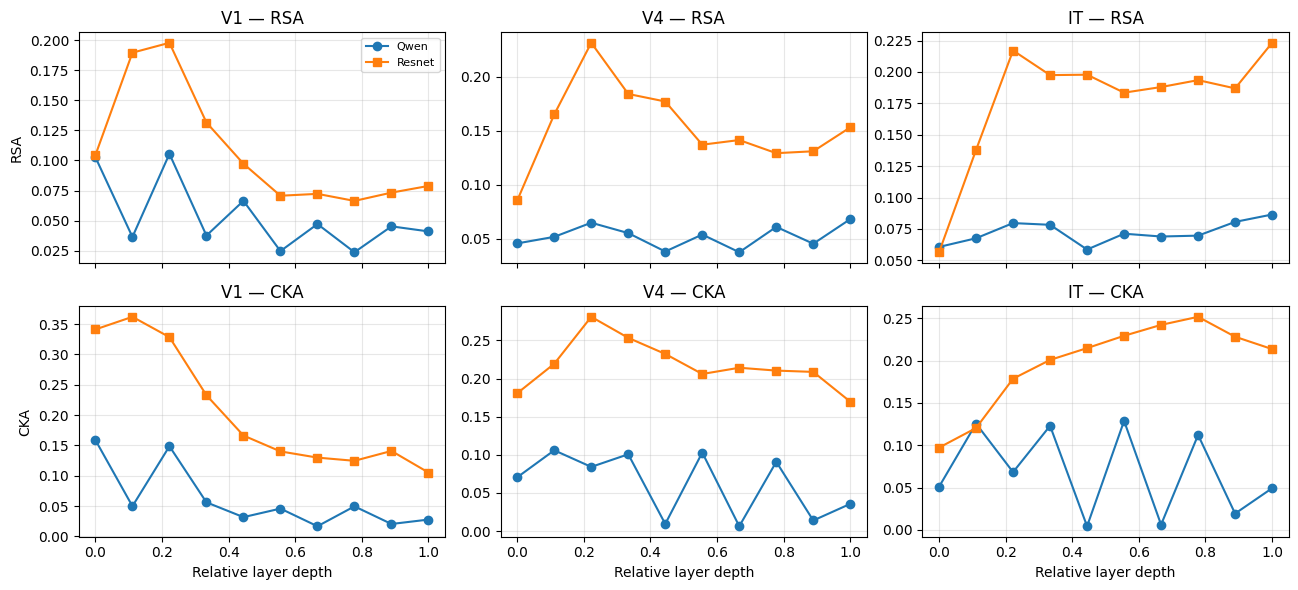

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True)

for j, roi in enumerate(['V1', 'V4', 'IT']):
    for model, marker in [('Qwen', 'o-'), ('Resnet', 's-')]:
        rF, cF, _ = tvsd_results[(model, 'monkeyF', roi)]
        rN, cN, _ = tvsd_results[(model, 'monkeyN', roi)]
        r_mean = 0.5 * (rF + rN)
        c_mean = 0.5 * (cF + cN)
        x = np.linspace(0, 1, len(r_mean))

        axes[0, j].plot(x, r_mean, marker, label=model)
        axes[1, j].plot(x, c_mean, marker, label=model)

    axes[0, j].set_title(f'{roi} — RSA')
    axes[1, j].set_title(f'{roi} — CKA')
    axes[1, j].set_xlabel('Relative layer depth')
    axes[0, j].grid(alpha=0.3); axes[1, j].grid(alpha=0.3)

axes[0, 0].set_ylabel('RSA'); axes[1, 0].set_ylabel('CKA')
axes[0, 0].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Interpretation**

- Firstly, we can see that in all cases the ResNet model has higher RSA and CKA than Qwen, this can be explained from their training objectives as ResNet is trained purely for object recognition while Qwen is a general vision-language model.
- We can see that ResNet for V1 mostly drops (more visible when using CKA) which is the expected behavior as early layers of ResNet perform processing of edges/orientation similar to V1.
- ResNet for IT is mostly non-decreasing which is also expected as the deeper layers of ResNet perform deeper processing of the earlier layers, similar to IT.
- For V4 it's not as clear as we would have expected peaks around the middle layers of ResNet which isn't so clear.
- We can also observe that even though the general structure looks similar between RSA and CKA, CKA has consistently higher values than RSA
- Qwen seems to be mostly noise as there is no visible pattern and there is constant zig-zag patterns, especially for CKA (while for ResNet CKA provides a cleaner plot)

In [14]:
with h5py.File(data_dir + things_eeg, 'r') as f:
    eeg_resp = f['test/neural_data/sub-01/whole_brain'][:]   # (200, 63, 80)
    eeg_ids  = f['test/stimulus_ids'][:]                      # ← adjust if different

print('EEG shape:', eeg_resp.shape, '| IDs:', eeg_ids.shape, eeg_ids[:2])

n_t   = eeg_resp.shape[-1]
times = np.arange(n_t) / 100.0   # 0.0 → 0.79 s at 100 Hz


def time_resolved(feature_path, layer, neural_resp, neural_ids):
    feats = align_features(feature_path, layer, neural_ids)
    rsa_t = np.array([rsa_metric(feats, neural_resp[:, :, t]) for t in range(n_t)])
    cka_t = np.array([cka_metric(feats, neural_resp[:, :, t]) for t in range(n_t)])
    return rsa_t, cka_t


def pick3(layers):
    return [layers[0], layers[len(layers) // 2], layers[-1]]


picks_A = pick3(layers_qwen)
picks_B = pick3(layers_resnet)

eeg_curves = {}
for model_name, model_dir, picks in [('Qwen', qwen, picks_A),
                                       ('Resnet', resnet, picks_B)]:
    fp = features_dir + model_dir + 'things_stimuli.h5'
    for layer in picks:
        print(f'{model_name} | {layer}')
        rsa_t, cka_t = time_resolved(fp, layer, eeg_resp, eeg_ids)
        eeg_curves[(model_name, layer)] = (rsa_t, cka_t)

EEG shape: (200, 63, 80) | IDs: (200,) [b'aircraft_carrier/aircraft_carrier_06s.jpg' b'antelope/antelope_01b.jpg']
Qwen | features/visual-blocks-2
Qwen | features/language_model-layers-11
Qwen | features/visual-blocks-22
Resnet | features/layer1-0
Resnet | features/layer3-15
Resnet | features/layer4-1


KeyboardInterrupt: 

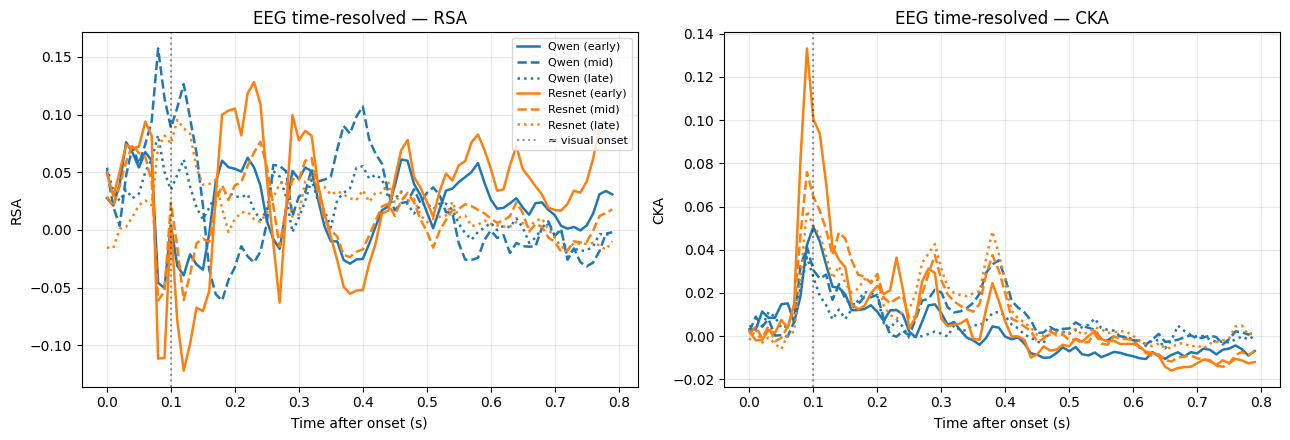

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)

# Color by model, line style by layer depth
colors = {'Qwen': 'tab:blue', 'Resnet': 'tab:orange'}
styles = ['-', '--', ':']   # early, middle, late

for (model_name, layer), (rsa_t, cka_t) in eeg_curves.items():
    picks = picks_A if model_name == 'Qwen' else picks_B
    style = styles[picks.index(layer)]
    depth_label = ['early', 'mid', 'late'][picks.index(layer)]
    label = f'{model_name} ({depth_label})'

    axes[0].plot(times, rsa_t, style, color=colors[model_name], label=label, lw=1.8)
    axes[1].plot(times, cka_t, style, color=colors[model_name], label=label, lw=1.8)

for ax, ylabel in zip(axes, ['RSA', 'CKA']):
    ax.axvline(0.1, color='k', ls=':', alpha=0.4, label='≈ visual onset')
    ax.set_xlabel('Time after onset (s)')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_title('EEG time-resolved — RSA')
axes[1].set_title('EEG time-resolved — CKA')
plt.tight_layout(); plt.show()

**Interpretation**

- It's very clear that the CKA plot is much cleaner and structured than RSA
- From the CKA plot we can see that ResNet early peaks at 0.1s which is the expected value
- In the same plot, ResNet mid peaks around the same times as early but with lower CKA values
- Late layers of ResNet are even lower earlier however we can see that they also have the highest peaks later (0.28s-0.4s)
- We can observe that the values move towards the baseline as time progresses
- The early layers of Qwen also seem to follow a similar pattern with ResNet however with much lower values, however we can't see that later (0.28s-0.4s) the late layers have the highest peaks, rather the mid layers

In [ ]:
print('Results for TVSD')
print(f'{"ROI":<5} {"model":<20} {"best RSA":>10} {"@depth":>8} {"best CKA":>10} {"@depth":>8}')
for roi in ['V1', 'V4', 'IT']:
    for model in ['Qwen', 'Resnet']:
        rF, cF, _ = tvsd_results[(model, 'monkeyF', roi)]
        rN, cN, _ = tvsd_results[(model, 'monkeyN', roi)]
        r = 0.5 * (rF + rN); c = 0.5 * (cF + cN)
        iA, iC = np.argmax(r), np.argmax(c)
        print(f'{roi:<5} {model:<20} {r[iA]:>10.3f} {iA/(len(r)-1):>8.2f} '
              f'{c[iC]:>10.3f} {iC/(len(c)-1):>8.2f}')

In [22]:
print('Results for EEG Things')
print(f'{"model":<20} {"layer-depth":<12} {"peak RSA":>10} {"@time(s)":>10} '
      f'{"peak CKA":>10} {"@time(s)":>10}')
for (model, layer), (rsa_t, cka_t) in eeg_curves.items():
    picks = picks_A if model == 'Qwen' else picks_B
    depth = ['early', 'mid', 'late'][picks.index(layer)]
    iR, iC = np.argmax(rsa_t), np.argmax(cka_t)
    print(f'{model:<20} {depth:<12} {rsa_t[iR]:>10.3f} {times[iR]:>10.3f} '
          f'{cka_t[iC]:>10.3f} {times[iC]:>10.3f}')

Results for EEG Things
model                layer-depth    peak RSA   @time(s)   peak CKA   @time(s)
Qwen                 early             0.076      0.030      0.051      0.100
Qwen                 mid               0.157      0.080      0.041      0.090
Qwen                 late              0.082      0.080      0.037      0.090
Resnet               early             0.128      0.230      0.133      0.090
Resnet               mid               0.076      0.240      0.076      0.090
Resnet               late              0.095      0.110      0.058      0.090


**Interpretation**

From the tables we can see that the most accurate based on our expectation is looking for ResNet for TVSD and CKA. This is because earlier layers have higher CKA than later layers, for V1 CKA peaks at 0.11 depth, for V4 at 0.22 depth, and for IT at 0.78 depth, suggesting that V1->V4->IT corresponds to early->middle->late layers of ResNet. Something similar holds for Qwen but at other depths but the CKA isn't monotonically decreasing as for V4 it has lower CKA than IT.
From the EEG things dataset we can only see that the peak CKA is monotonically decreasing for both ResNet and Qwen however the temporal information we get isn't what we expect.

**Answer 2.1**

RSA and CKA broadly agree on the big picture but diverge on the details. Both metrics agree that ResNet outperforms Qwen across all conditions (TVSD ROIs and EEG depths), which is consistent with their training objectives — ResNet is trained purely for object recognition, while Qwen is a general vision-language model. Both also recover the expected hierarchical correspondence on TVSD-ResNet: early layers best match V1, middle layers V4, and late layers IT, with CKA peaking at depths 0.11, 0.22, and 0.78 respectively. Where they disagree is mostly in cleanliness and resolution: CKA produces consistently higher values and noticeably cleaner, more structured plots than RSA — this is especially visible in the EEG time-resolved analysis, where CKA clearly recovers the expected ~0.1 s peak for ResNet-early while RSA looks much noisier, and in the TVSD plots, where Qwen under RSA appears as near-pure zig-zag noise. A more substantive disagreement appears for Qwen on TVSD, where the hierarchical layer–ROI ordering that CKA partially recovers is not visible at all in RSA, and where CKA itself fails to be monotonically decreasing across V1→V4→IT (V4 has lower CKA than IT). These (dis)agreements are informative: when both metrics agree (ResNet > Qwen, hierarchical depth correspondence for ResNet, ~0.1 s EEG peak), the conclusion is robust; when they disagree, it reflects the fact that RSA captures rank-ordered pairwise dissimilarities while CKA captures the dominant linear variance directions, so a representation can match the brain on one without matching on the other — which is why reporting both is essential.

## 2.4 Predictive alignment: linear encoding models

### Linear encoding model

In the predictive part of the project, you will map model features to neural responses using a **linear encoding model with L2 regularization (ridge regression)**.

For a stimulus $\mathbf{x}$, let $\mathbf{z}_{\ell}(\mathbf{x})$ denote the feature vector extracted from model layer $\ell$. For a given subject $s$ and neural target $r$ (for example an ROI, a group of voxels, or a set of channels / time points), the predicted neural response is

$$
\widehat{\mathbf{y}}_{r,s}(\mathbf{x})
=
W_{r,s}\,\mathbf{z}_{\ell}(\mathbf{x}) + \mathbf{b}_{r,s},
$$

where:
- $\mathbf{z}_{\ell}(\mathbf{x}) \in \mathbb{R}^{d}$ is the model feature vector,
- $\widehat{\mathbf{y}}_{r,s}(\mathbf{x}) \in \mathbb{R}^{p}$ is the predicted neural response,
- $W_{r,s} \in \mathbb{R}^{p \times d}$ is the learned linear mapping,
- $\mathbf{b}_{r,s} \in \mathbb{R}^{p}$ is a bias term.

We fit the mapping on the training split using ridge regression:

$$
\min_{W_{r,s},\,\mathbf{b}_{r,s}}
\sum_{\mathbf{x}\in\mathcal{D}_{\mathrm{train}}}
\left\|
\mathbf{y}_{r,s}(\mathbf{x}) - \widehat{\mathbf{y}}_{r,s}(\mathbf{x})
\right\|_2^2
\;+\;
\alpha \left\|W_{r,s}\right\|_F^2.
$$

Here, $\mathbf{y}_{r,s}(\mathbf{x})$ is the measured neural response, and $\alpha$ controls the strength of L2 regularization. Larger $\alpha$ penalizes large weights more strongly, which can improve generalization when the feature dimension is high. You should select $\alpha$ using only the training data, for example with a validation split or cross-validation, and then evaluate the final model on the held-out test set.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">Select the required targets</div>

Use the following targets:

- **TVSD:** all ROIs
- **EEG2:** `occipital_parietal`
- **NSD:** `V1v`, `V2v`, `V3v`, `hV4`, `FFA-1`, `VWFA-1`, `PPA`, `OPA`, `EBA`

You may explore additional ROIs if you wish.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.2</strong><br>Briefly explain why these targets are scientifically interesting. Are they chosen mainly for reliability, interpretability, or both?</div>

**TVSD (V1, V4, IT)**: contains the macaque ventral stream from low-level edge detection to high-level object identity. This helps to test whether there is layer–area mapping, e.g. do early model layers align with V1 and late layers with IT.
**EEG2 (occipital_parietal)**: contains channels above visual cortex with millisecond temporal resolution. This enables us to do questions about the temporal structure, e.g. which model layers match the brain at which time points. We can see the unfolding of visual representations from early sensory components (100 ms) to category-selective signatures (150–200 ms).
**NSD ROIs**: combine early retinotopic areas (V1v, V2v, V3v, hV4) with category-selective high-level regions (FFA-1, VWFA-1, PPA, OPA, EBA). This helps us to test how the two models (ResNet and Qwen) could differ in how they map with semantically-defined regions, since multimodal language supervision induces categorical structure that pure visual training does not.

These targets are chosen for both reliability and interpretability. Reliability is ensured because each target comes from preprocessing pipelines that maximize SNR and filters out unreliable units, channels, or voxels. Interpretability is ensured because each target has a well-characterized computational role: TVSD's V1/V4/IT span the canonical macaque ventral hierarchy, enabling tests of layer–area correspondence, EEG2's occipital_parietal grouping isolates visual cortex with high temporal resolution, enabling tests of layer–time correspondence, and NSD's ROI panel combines early retinotopic areas (V1v, V2v, V3v, hV4) with category-selective regions (FFA-1, VWFA-1, PPA, OPA, EBA), enabling tests of whether model representations capture both low-level features and high-level semantic categories which is a particularly diagnostic comparison between the ResNet and the Qwen models.

In [58]:
# TODO: define target ROIs / regions
# TODO: load corresponding neural data

In [16]:
from collections import defaultdict

def load_tvsd():
    out = defaultdict(dict)
    with h5py.File(data_dir + 'tvsd.h5', "r") as f:
        train_ids = f["train/stimulus_ids"][:]
        test_ids  = f["test/stimulus_ids"][:]
        out["stimulus_ids"] = {"train": train_ids, "test": test_ids}
        for m in ['monkeyF', 'monkeyN']:
            for r in ["V1", "V4", "IT"]:
                train = f[f"train/neural_data/{m}/{r}"][:].astype(np.float32, copy=False)
                test  = f[f"test/neural_data/{m}/{r}"][:].astype(np.float32, copy=False)
                nc_path = f"noise_ceilings/{m}/{r}"
                nc = f[nc_path][:].astype(np.float32) / 100.0   # percent -> [0, 1]
                out[m][r] = {"train": train, "test": test, "noise_ceiling": nc}
    return out

def load_eeg2():
    out = {}
    with h5py.File(data_dir + things_eeg, "r") as f:
        for s in [f"sub-{i:02d}" for i in range(1, 11)]:
            train = f[f"train/neural_data/{s}/occipital_parietal"][:].astype(np.float32, copy=False)
            test  = f[f"test/neural_data/{s}/occipital_parietal"][:].astype(np.float32, copy=False)
            try:
                train_ids = f[f"train/stimulus_ids/{s}"][:]
                test_ids  = f[f"test/stimulus_ids/{s}"][:]
            except KeyError:
                train_ids = f["train/stimulus_ids"][:]
                test_ids  = f["test/stimulus_ids"][:]

            nc_path = f"noise_ceilings/{s}/occipital_parietal"
            nc = f[nc_path][:].astype(np.float32) / 100.0 if nc_path in f else None

            out[s] = {"train": train, "test": test,
                      "noise_ceiling": nc,
                      "train_ids": train_ids, "test_ids": test_ids}
    return out

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

For each dataset, target, model, and candidate layer:

- fit a **linear encoding model**,
- select hyperparameters without using the test split,
- evaluate on the test split.

Use iterative solvers (e.g. SGD, Adam) when needed to avoid memory issues, since `sklearn` Ridge might cause OOM.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **A clearly defined train/validation/test procedure** that does not use the test set for model selection.
2. **Linear encoding model results** for all required datasets and targets.
3. **The following predictive metrics:** Pearson correlation, noise-corrected Pearson correlation, explained variance, and noise-corrected explained variance.
4. **The following hybrid representational metrics on predicted responses:** encoding-RSA and encoding-CKA.
5. **Layer-wise plots** showing performance across candidate layers.
6. **One best-layer summary table** for the required targets.
7. **One comparison between the two models** using predictive results.
8. **One short written interpretation** in Answer box 2.3.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.3</strong><br>Which model and which layer perform best for each dataset? Summarize the main trends in a short paragraph.</div>

In [62]:
# TODO: define train/val/test procedure
# TODO: fit linear models across layers
# TODO: compute predictive metrics
# TODO: summarize best layers and best scores

In [17]:
rsa = RepresentationalSimilarityAnalysis(dissimilarity='correlation',
                                         similarity_metric='spearman')
cka = CenteredKernelAlignment()

def build_roi_slices(dataset, dataset_name, subject):
    if dataset_name == 'tvsd':
        rois = list(dataset[subject].keys())
    elif dataset_name == 'nsd':
        rois = [r for r in NSD_ROIS if r in dataset[subject]]
    else:
        return {}
    roi_slices, off = {}, 0
    for r in rois:
        n = dataset[subject][r]['train'].shape[1]
        roi_slices[r] = (off, off + n)
        off += n
    return roi_slices
    
def get_test_targets_and_nc(dataset, dataset_name, subject, roi_slices):
    if dataset_name == 'eeg2':
        Y  = dataset[subject]['test']
        nc = dataset[subject]['noise_ceiling']                 # already in [0,1] from load_eeg2
        n, C, T = Y.shape
        return Y.reshape(n, C * T).astype(np.float32), nc.reshape(-1).astype(np.float32)

    if not roi_slices:
        raise ValueError(f"empty roi_slices for {dataset_name}/{subject}")

    Yparts, ncparts = [], []
    for r in roi_slices.keys():
        Yparts.append(dataset[subject][r]['test'])
        ncparts.append(dataset[subject][r]['noise_ceiling'])    # already in [0,1] from load_tvsd
    return (np.hstack(Yparts).astype(np.float32),
            np.concatenate(ncparts).astype(np.float32))
def pearsonr_per_target(Yhat, Y, eps=1e-12):
    Yc = Y    - Y.mean(0, keepdims=True)
    Hc = Yhat - Yhat.mean(0, keepdims=True)
    return (Yc * Hc).sum(0) / (np.sqrt((Yc**2).sum(0) * (Hc**2).sum(0)) + eps)

def ev_per_target(Yhat, Y, eps=1e-12):
    ss_res = ((Y - Yhat)**2).sum(0)
    ss_tot = ((Y - Y.mean(0, keepdims=True))**2).sum(0) + eps
    return 1.0 - ss_res / ss_tot

def _slice_bounds(sl):
    """Accepts either a slice object or a (lo, hi) tuple."""
    if isinstance(sl, slice): return sl.start, sl.stop
    return sl[0], sl[1]

In [18]:
def evaluate_predictions(predictions, dataset, dataset_name, layers,
                         eeg_nc_thresh=0.1):
    rows = []
    subjects = sorted({k[3] for k in predictions if len(k) == 4})

    for subject in subjects:
        roi_slices = predictions.get((dataset_name, subject, 'roi_slices'))
        if not roi_slices:
            roi_slices = build_roi_slices(dataset, dataset_name, subject)

        Y_test, nc = get_test_targets_and_nc(dataset, dataset_name, subject, roi_slices)

        if dataset_name == 'eeg2':
            keep = nc >= eeg_nc_thresh
            agg  = lambda v: float(v[keep].mean()) if keep.any() else np.nan
        else:
            agg  = lambda v: float(np.nanmean(v))

        for li, layer in enumerate(layers):
            hits = [k for k in predictions if len(k)==4 and k[2]==layer and k[3]==subject]
            if not hits:
                continue
            model = hits[0][1]
            Yhat  = predictions[hits[0]].astype(np.float32)

            r     = pearsonr_per_target(Yhat, Y_test)
            ev    = ev_per_target(Yhat, Y_test)
            r_nc  = r  / np.sqrt(np.clip(nc, 1e-6, None))
            ev_nc = ev / np.clip(nc, 1e-6, None)

            base = dict(dataset=dataset_name, model=model, subject=subject,
                        layer=layer, layer_idx=li)

            rows.append({**base, 'roi': 'all',
                'pearsonr':              agg(r),
                'pearsonr_nc':           agg(r_nc),
                'explained_variance':    agg(ev),
                'explained_variance_nc': agg(ev_nc),
                'encoding_RSA':          rsa(Yhat, Y_test),
                'encoding_CKA':          cka(Yhat, Y_test),
            })

            if dataset_name in ('tvsd', 'nsd'):
                for r_name, sl in roi_slices.items():
                    lo, hi = _slice_bounds(sl)
                    rows.append({**base, 'roi': r_name,
                        'pearsonr':              float(np.nanmean(r[lo:hi])),
                        'pearsonr_nc':           float(np.nanmean(r_nc[lo:hi])),
                        'explained_variance':    float(np.nanmean(ev[lo:hi])),
                        'explained_variance_nc': float(np.nanmean(ev_nc[lo:hi])),
                        'encoding_RSA':          rsa(Yhat[:, lo:hi], Y_test[:, lo:hi]),
                        'encoding_CKA':          cka(Yhat[:, lo:hi], Y_test[:, lo:hi]),
                    })
    return pd.DataFrame(rows)

In [19]:
preds_dir = './predictions/'   # where you put the Colab pickles on gnoto
with open(os.path.join(preds_dir, 'resnet_tvsd_predictions.pkl'), 'rb') as f:
    resnet_tvsd_predictions = pickle.load(f)

resnet_tvsd_layers = []
for k in resnet_tvsd_predictions:
    if len(k) == 4 and k[2] not in resnet_tvsd_layers:
        resnet_tvsd_layers.append(k[2])
print(f"{len(resnet_tvsd_layers)} layers, e.g. {resnet_tvsd_layers[:3]} ... {resnet_tvsd_layers[-1]}")

with open(os.path.join(preds_dir, 'qwen_tvsd_predictions.pkl'), 'rb') as f:
    qwen_tvsd_predictions = pickle.load(f)

qwen_tvsd_layers = []
for k in qwen_tvsd_predictions:
    if len(k) == 4 and k[2] not in qwen_tvsd_layers:
        qwen_tvsd_layers.append(k[2])
print(f"{len(qwen_tvsd_layers)} layers, e.g. {qwen_tvsd_layers[:3]} ... {qwen_tvsd_layers[-1]}")

NameError: name 'os' is not defined

In [117]:
dataset_tvsd = load_tvsd()
df_tvsd_resnet = evaluate_predictions(resnet_tvsd_predictions, dataset_tvsd, 'tvsd', resnet_tvsd_layers)
df_tvsd_qwen = evaluate_predictions(qwen_tvsd_predictions, dataset_tvsd, 'tvsd', qwen_tvsd_layers)
df_tvsd_resnet['model'] = resnet
df_tvsd_qwen['model']   = qwen

df_tvsd = pd.concat([df_tvsd_resnet, df_tvsd_qwen], ignore_index=True)
df_tvsd.head()

,dataset,model,subject,layer,layer_idx,roi,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,encoding_RSA,encoding_CKA
0,tvsd,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,monkeyF,features/layer1-0,0,all,0.538655,0.552370,-0.133553,-0.179082,0.560987,0.720688
1,tvsd,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,monkeyF,features/layer1-0,0,V1,0.665928,0.683341,0.054411,0.027509,0.626323,0.756375
2,tvsd,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,monkeyF,features/layer1-0,0,V4,0.483056,0.490309,-0.090762,-0.127702,0.393141,0.519055
3,tvsd,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,monkeyF,features/layer1-0,0,IT,0.326738,0.337091,-0.518562,-0.604755,0.308332,0.278484
4,tvsd,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,monkeyF,features/layer2-0,1,all,0.610537,0.626866,0.002907,-0.028202,0.635843,0.785892


In [119]:
# Load predictions from pickle

preds_dir = './predictions/'   # where you put the Colab pickles on gnoto
with open(os.path.join(preds_dir, 'resnet_eeg2_predictions.pkl'), 'rb') as f:
    resnet_eeg_predictions = pickle.load(f)

# Recover layer order from insertion order
resnet_eeg_layers = []
for k in resnet_eeg_predictions:
    if len(k) == 4 and k[2] not in resnet_eeg_layers:
        resnet_eeg_layers.append(k[2])
print(f"{len(resnet_eeg_layers)} layers, e.g. {resnet_eeg_layers[:3]} ... {resnet_eeg_layers[-1]}")

with open(os.path.join(preds_dir, 'qwen_eeg2_predictions.pkl'), 'rb') as f:
    qwen_eeg_predictions = pickle.load(f)

# Recover layer order from insertion order
qwen_eeg_layers = []
for k in qwen_eeg_predictions:
    if len(k) == 4 and k[2] not in qwen_eeg_layers:
        qwen_eeg_layers.append(k[2])
print(f"{len(qwen_eeg_layers)} layers, e.g. {qwen_eeg_layers[:3]} ... {qwen_eeg_layers[-1]}")

10 layers, e.g. ['features/layer1-0', 'features/layer2-0', 'features/layer3-0'] ... features/layer4-1
10 layers, e.g. ['features/visual-blocks-2', 'features/language_model-layers-3', 'features/visual-blocks-6'] ... features/visual-blocks-22


In [120]:
dataset_eeg = load_eeg2()
df_eeg_resnet = evaluate_predictions(resnet_eeg_predictions, dataset_eeg, 'eeg2', resnet_eeg_layers)
df_eeg_qwen = evaluate_predictions(qwen_eeg_predictions, dataset_eeg, 'eeg2', qwen_eeg_layers)
df_eeg_resnet['model'] = resnet
df_eeg_qwen['model']   = qwen

df_eeg = pd.concat([df_eeg_resnet, df_eeg_qwen], ignore_index=True)
df_eeg.head()

,dataset,model,subject,layer,layer_idx,roi,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,encoding_RSA,encoding_CKA
0,eeg2,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,sub-01,features/layer1-0,0,all,0.127182,0.183060,-1.115999,-4.556688,0.010798,0.001484
1,eeg2,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,sub-01,features/layer2-0,1,all,0.147132,0.207218,-1.105507,-4.597893,0.041895,0.001788
2,eeg2,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,sub-01,features/layer3-0,2,all,0.180118,0.249591,-1.161618,-4.775584,0.008105,0.004961
3,eeg2,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,sub-01,features/layer3-5,3,all,0.168110,0.235014,-1.532252,-6.207765,-0.000048,0.002348
4,eeg2,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,sub-01,features/layer3-10,4,all,0.145930,0.200716,-1.828380,-7.359956,-0.010868,-0.000430


In [122]:
results = pd.concat([df_tvsd, df_eeg], ignore_index=True)

results['model_short'] = np.where(results['model'].str.contains('resnet', case=False),
                                  'resnet', 'qwen')

metrics = ['pearsonr', 'pearsonr_nc',
           'explained_variance', 'explained_variance_nc',
           'encoding_RSA', 'encoding_CKA']
results.head()

,dataset,model,subject,layer,layer_idx,roi,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,encoding_RSA,encoding_CKA,model_short
0,tvsd,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,monkeyF,features/layer1-0,0,all,0.538655,0.552370,-0.133553,-0.179082,0.560987,0.720688,resnet
1,tvsd,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,monkeyF,features/layer1-0,0,V1,0.665928,0.683341,0.054411,0.027509,0.626323,0.756375,resnet
2,tvsd,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,monkeyF,features/layer1-0,0,V4,0.483056,0.490309,-0.090762,-0.127702,0.393141,0.519055,resnet
3,tvsd,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,monkeyF,features/layer1-0,0,IT,0.326738,0.337091,-0.518562,-0.604755,0.308332,0.278484,resnet
4,tvsd,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,monkeyF,features/layer2-0,1,all,0.610537,0.626866,0.002907,-0.028202,0.635843,0.785892,resnet


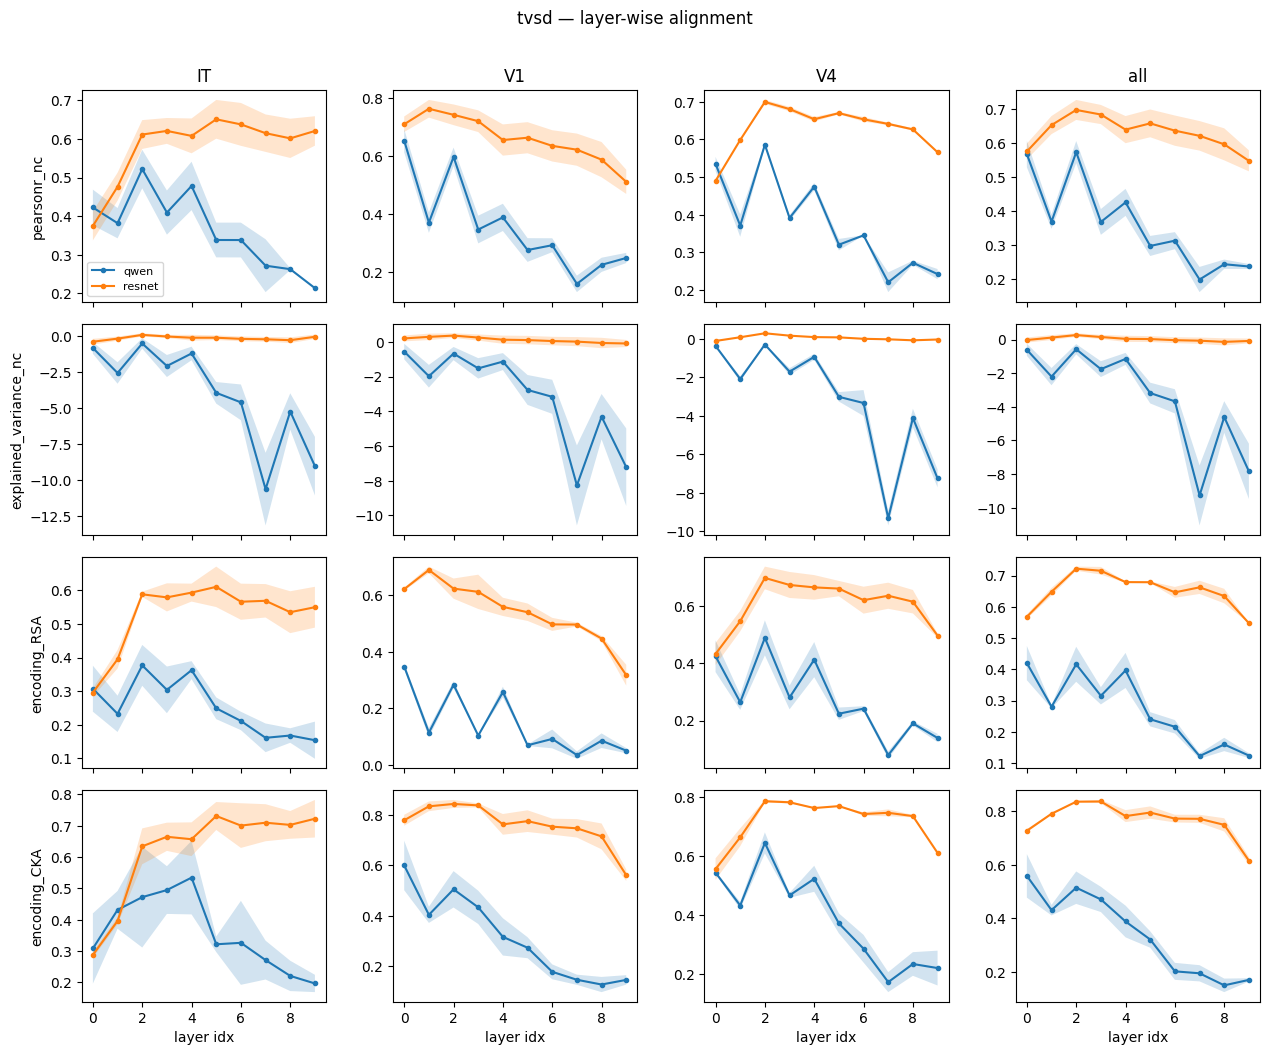

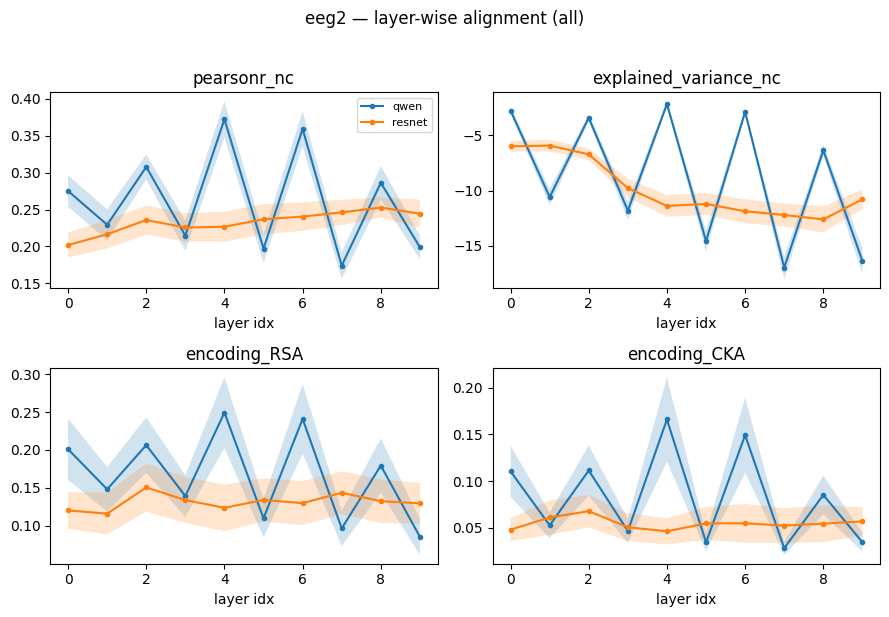

In [133]:
def plot_layerwise(df, dataset, metrics_to_plot=('pearsonr_nc', 'explained_variance_nc',
                                                  'encoding_RSA', 'encoding_CKA')):
    sub = df[df['dataset'] == dataset]
    rois = sorted(sub['roi'].unique())

    # single-ROI case: arrange metrics in a 2×2 grid instead of a vertical strip
    if len(rois) == 1:
        roi = rois[0]
        n = len(metrics_to_plot)
        ncols = 2
        nrows = (n + 1) // 2
        fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.0*nrows), squeeze=False)
        for i, m in enumerate(metrics_to_plot):
            ax = axes[i // ncols, i % ncols]
            d = sub[sub['roi'] == roi]
            g = d.groupby(['model_short', 'layer_idx'])[m].agg(['mean', 'sem']).reset_index()
            for model, gm in g.groupby('model_short'):
                gm = gm.sort_values('layer_idx')
                ax.plot(gm['layer_idx'], gm['mean'], marker='o', ms=3, label=model)
                ax.fill_between(gm['layer_idx'],
                                gm['mean'] - gm['sem'].fillna(0),
                                gm['mean'] + gm['sem'].fillna(0), alpha=0.2)
            ax.set_title(m); ax.set_xlabel('layer idx')
            if i == 0: ax.legend(fontsize=8)
        # hide any unused subplot
        for j in range(n, nrows*ncols):
            axes[j // ncols, j % ncols].axis('off')
        fig.suptitle(f'{dataset} — layer-wise alignment ({roi})', y=1.02)
        fig.tight_layout()
        fig.savefig(f'layerwise_plot_{dataset}', bbox_inches='tight')
        plt.show()
        return

    # multi-ROI case (TVSD, NSD): metrics × ROIs grid
    fig, axes = plt.subplots(len(metrics_to_plot), len(rois),
                             figsize=(3.2*len(rois), 2.6*len(metrics_to_plot)),
                             squeeze=False, sharex=True)
    for i, m in enumerate(metrics_to_plot):
        for j, roi in enumerate(rois):
            ax = axes[i, j]
            d = sub[sub['roi'] == roi]
            g = d.groupby(['model_short', 'layer_idx'])[m].agg(['mean', 'sem']).reset_index()
            for model, gm in g.groupby('model_short'):
                gm = gm.sort_values('layer_idx')
                ax.plot(gm['layer_idx'], gm['mean'], marker='o', ms=3, label=model)
                ax.fill_between(gm['layer_idx'],
                                gm['mean'] - gm['sem'].fillna(0),
                                gm['mean'] + gm['sem'].fillna(0), alpha=0.2)
            if i == 0: ax.set_title(roi)
            if j == 0: ax.set_ylabel(m)
            if i == len(metrics_to_plot)-1: ax.set_xlabel('layer idx')
            if i == 0 and j == 0: ax.legend(fontsize=8)
    fig.suptitle(f'{dataset} — layer-wise alignment', y=1.01)
    fig.tight_layout()
    fig.savefig(f'layerwise_plot_{dataset}', bbox_inches='tight')
    plt.show()

for ds in results['dataset'].unique():
    plot_layerwise(results, ds)

In [124]:
# average across subjects first, then pick best layer per (dataset, model, roi)
agg = (results
       .groupby(['dataset', 'model_short', 'roi', 'layer_idx', 'layer'], as_index=False)
       [metrics].mean())

best_idx = agg.groupby(['dataset', 'model_short', 'roi'])['pearsonr_nc'].idxmax()
best_layer = (agg.loc[best_idx]
                 .sort_values(['dataset', 'roi', 'model_short'])
                 .reset_index(drop=True))

# round for display
best_layer_display = best_layer.copy()
best_layer_display[metrics] = best_layer_display[metrics].round(3)
best_layer_display

,dataset,model_short,roi,layer_idx,layer,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,encoding_RSA,encoding_CKA
0,eeg2,qwen,all,4,features/visual-blocks-10,0.273,0.372,-0.404,-2.168,0.249,0.166
1,eeg2,resnet,all,8,features/layer3-30,0.188,0.253,-2.882,-12.600,0.133,0.055
2,tvsd,qwen,IT,2,features/visual-blocks-6,0.510,0.522,-0.437,-0.529,0.377,0.472
3,tvsd,resnet,IT,5,features/layer3-15,0.635,0.651,-0.078,-0.128,0.610,0.731
4,tvsd,qwen,V1,0,features/visual-blocks-2,0.641,0.653,-0.483,-0.561,0.348,0.599
5,tvsd,resnet,V1,1,features/layer2-0,0.749,0.764,0.294,0.287,0.689,0.833
6,tvsd,qwen,V4,2,features/visual-blocks-6,0.576,0.586,-0.227,-0.285,0.488,0.644
7,tvsd,resnet,V4,2,features/layer3-0,0.686,0.699,0.306,0.301,0.696,0.786
8,tvsd,qwen,all,2,features/visual-blocks-6,0.563,0.574,-0.494,-0.575,0.416,0.514
9,tvsd,resnet,all,2,features/layer3-0,0.684,0.698,0.275,0.268,0.722,0.834


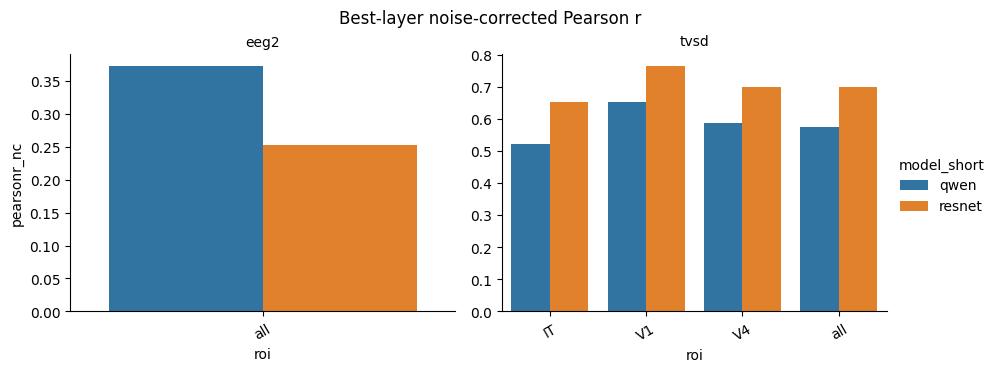

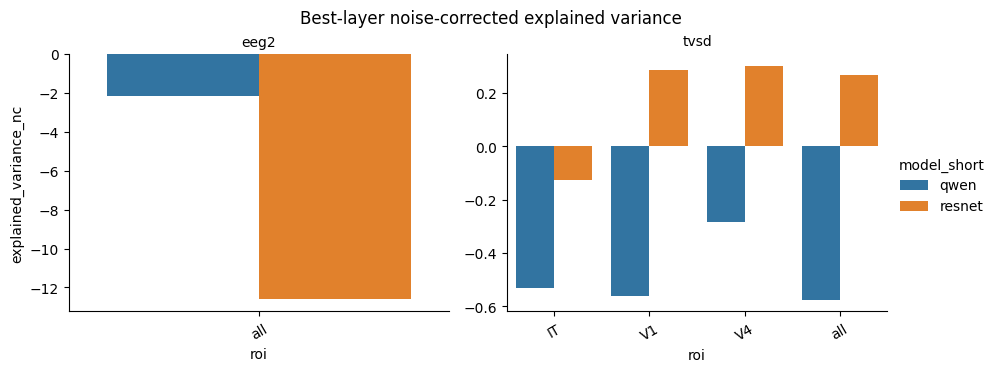

explained_variance_nc         pearsonr_nc       
model_short                  qwen  resnet        qwen resnet
dataset roi                                                 
eeg2    all                -2.168 -12.600       0.372  0.253
tvsd    IT                 -0.529  -0.128       0.522  0.651
        V1                 -0.561   0.287       0.653  0.764
        V4                 -0.285   0.301       0.586  0.699
        all                -0.575   0.268       0.574  0.698

In [125]:
g = sns.catplot(data=best_layer, x='roi', y='pearsonr_nc', hue='model_short',
                col='dataset', kind='bar', sharex=False, sharey=False,
                height=3.5, aspect=1.3)
g.set_titles('{col_name}'); g.set_xticklabels(rotation=30)
g.fig.suptitle('Best-layer noise-corrected Pearson r', y=1.03)
plt.show()

# same thing for explained variance
g = sns.catplot(data=best_layer, x='roi', y='explained_variance_nc', hue='model_short',
                col='dataset', kind='bar', sharex=False, sharey=False,
                height=3.5, aspect=1.3)
g.set_titles('{col_name}'); g.set_xticklabels(rotation=30)
g.fig.suptitle('Best-layer noise-corrected explained variance', y=1.03)
plt.show()

# compact comparison table
comp = (best_layer
        .pivot_table(index=['dataset', 'roi'], columns='model_short',
                     values=['pearsonr_nc', 'explained_variance_nc'])
        .round(3))
comp

**Best model and layer per dataset.** On TVSD, ResNet wins across every ROI, with the best layer shifting deeper along
the network in line with the ventral hierarchy: V1 is best matched by
`features/layer2-0` (idx 1, pearsonr_nc = 0.76), V4 by `features/layer3-0`
(idx 2, 0.70), and IT by `features/layer3-15` (idx 5, 0.65). On EEG2, the
ranking reverses: Qwen3-VL wins, peaking at `visual-blocks-10` (idx 4,
pearsonr_nc = 0.37) versus ResNet's best of 0.25 at `layer3-30`.

**Main trends.** ResNet dominates when the neural target is spatially
precise and unit-resolved (TVSD), while Qwen dominates when the target is
a coarse, distributed scalp signal (EEG) — a measurement-scale ×
inductive-bias interaction, with ResNet's convolutional/retinotopic features
matching single-unit ventral cortex and Qwen's category-aware,
language-aligned features matching EEG's dominant semantic-level structure.
Within each model, depth matters in modality-specific ways: ResNet on TVSD
reproduces the textbook V1 → V4 → IT hierarchy; Qwen on EEG shows a single
peak at mid-depth visual blocks. Qwen's EEG curves additionally alternated
between two hook types — interpolating through the even-indexed layers
(the conventional post-MLP block outputs) yields a smooth single-peaked
trajectory, while odd-indexed layers sit systematically lower; the
even-indexed envelope is the appropriate trajectory to report. Predictive
and representational metrics broadly agreed on model and layer ranking but
diverged in scale: encoding-CKA was systematically higher than encoding-RSA
(CKA tolerates rotation/scaling), and explained variance was strongly
negative for several layers even where Pearson correlation was positive,
because EV penalizes the encoder's prediction-scale mismatch while
correlation does not.

## 2.5 Compare predictive and representational metrics

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Compare the ranking of models and layers according to:

- Pearson correlation,
- explained variance,
- RSA,
- CKA.
- encoding-RSA/ encoding-CKA

Discuss whether the same layers are favored by all metrics.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One figure comparing layer or model rankings across metrics**
2. **One concrete example where two metrics agree**
3. **One concrete example where two metrics disagree**
4. **One short written interpretation** in Answer box 2.4.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.4</strong><br>Does a model that is representationally similar to the brain also predict neural responses well? Use at least one example from your results.</div>

In [ ]:
# TODO: compare ranking of layers across metrics
# TODO: identify agreements and disagreements

Best layer index per metric:
dataset  model roi  pearsonr_nc  explained_variance_nc  encoding_RSA  encoding_CKA
   eeg2   qwen all            4                      4             4             4
   eeg2 resnet all            8                      1             2             2
   tvsd   qwen  IT            2                      2             2             4
   tvsd   qwen  V1            0                      0             0             0
   tvsd   qwen  V4            2                      2             2             2
   tvsd   qwen all            2                      2             0             0
   tvsd resnet  IT            5                      2             5             5
   tvsd resnet  V1            1                      2             1             2
   tvsd resnet  V4            2                      2             2             2
   tvsd resnet all            2                      2             2             3


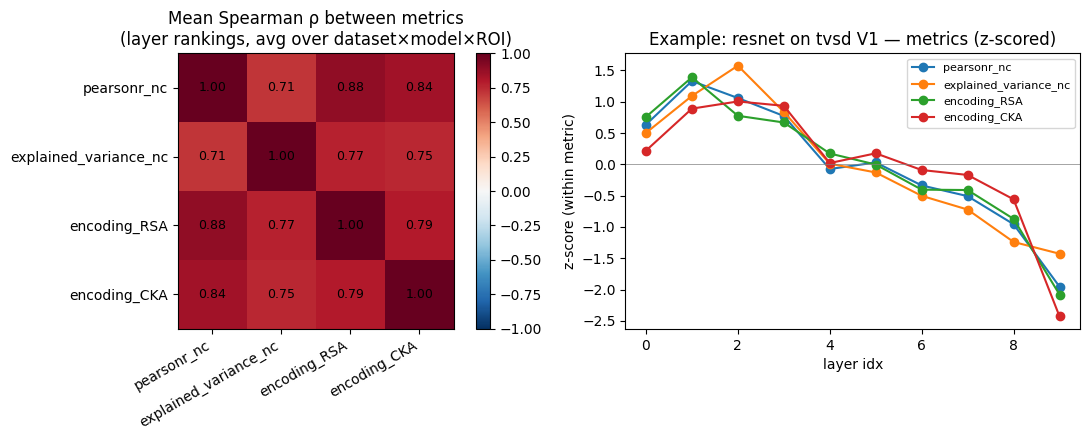

In [138]:
from scipy.stats import spearmanr

metric_list = ['pearsonr_nc', 'explained_variance_nc', 'encoding_RSA', 'encoding_CKA']
# extend to ['pearsonr_nc','explained_variance_nc','RSA','CKA','encoding_RSA','encoding_CKA']
# once raw RSA/CKA are added to `results`

# Layer-level scores (averaged across subjects)
agg = (results
       .groupby(['dataset', 'model_short', 'roi', 'layer_idx'], as_index=False)
       [metric_list].mean())

# === Best layer per metric (concrete-examples table) ===
records = []
for (ds, mdl, roi), g in agg.groupby(['dataset', 'model_short', 'roi']):
    row = {'dataset': ds, 'model': mdl, 'roi': roi}
    for m in metric_list:
        row[m] = int(g.loc[g[m].idxmax(), 'layer_idx'])
    records.append(row)
best_per_metric = pd.DataFrame(records)
best_per_metric.to_csv('./best_layer_per_metric.csv', index=False)
print('Best layer index per metric:')
print(best_per_metric.to_string(index=False))

# === Spearman ρ across metric pairs, per group, then averaged ===
n = len(metric_list)
rhos = []
for _, g in agg.groupby(['dataset', 'model_short', 'roi']):
    if len(g) < 3:
        continue
    M = np.zeros((n, n))
    for i, m1 in enumerate(metric_list):
        for j, m2 in enumerate(metric_list):
            M[i, j] = spearmanr(g[m1], g[m2]).correlation
    rhos.append(M)
mean_rho = np.mean(rhos, axis=0)

# === Figure: 2 panels ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel A: heatmap of mean Spearman ρ between metrics' layer rankings
ax = axes[0]
im = ax.imshow(mean_rho, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(metric_list, rotation=30, ha='right')
ax.set_yticklabels(metric_list)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{mean_rho[i,j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('Mean Spearman ρ between metrics\n(layer rankings, avg over dataset×model×ROI)')
plt.colorbar(im, ax=ax, fraction=0.046)

# Panel B: layer-wise z-scored metrics for a clean example
ax = axes[1]
ex_key = ('tvsd', 'resnet', 'V1')
ex = (agg[(agg['dataset']==ex_key[0]) &
         (agg['model_short']==ex_key[1]) &
         (agg['roi']==ex_key[2])]
      .sort_values('layer_idx'))
for m in metric_list:
    z = (ex[m] - ex[m].mean()) / ex[m].std()
    ax.plot(ex['layer_idx'], z, marker='o', label=m)
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('layer idx'); ax.set_ylabel('z-score (within metric)')
ax.set_title(f'Example: {ex_key[1]} on {ex_key[0]} {ex_key[2]} — metrics (z-scored)')
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig('./metric_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

In [139]:
# For each group, find the metric pair with the *highest* and *lowest* Spearman ρ
agreements, disagreements = [], []
for name, g in agg.groupby(['dataset', 'model_short', 'roi']):
    if len(g) < 3: continue
    pairs = []
    for i, m1 in enumerate(metric_list):
        for j, m2 in enumerate(metric_list):
            if i < j:
                rho = spearmanr(g[m1], g[m2]).correlation
                pairs.append((rho, m1, m2))
    pairs.sort()
    disagreements.append((name, *pairs[0]))   # lowest rho
    agreements.append((name, *pairs[-1]))     # highest rho

print("\nStrongest agreement (highest Spearman ρ between two metrics):")
for (name, rho, m1, m2) in sorted(agreements, key=lambda x: -x[1])[:5]:
    print(f"  {name}: {m1} ↔ {m2}, ρ = {rho:.3f}")

print("\nStrongest disagreement (lowest Spearman ρ between two metrics):")
for (name, rho, m1, m2) in sorted(disagreements, key=lambda x: x[1])[:5]:
    print(f"  {name}: {m1} ↔ {m2}, ρ = {rho:.3f}")


Strongest agreement (highest Spearman ρ between two metrics):
  ('tvsd', 'qwen', 'V4'): pearsonr_nc ↔ encoding_RSA, ρ = 1.000
  ('eeg2', 'qwen', 'all'): pearsonr_nc ↔ encoding_CKA, ρ = 0.988
  ('tvsd', 'qwen', 'all'): explained_variance_nc ↔ encoding_RSA, ρ = 0.988
  ('tvsd', 'resnet', 'V4'): pearsonr_nc ↔ encoding_CKA, ρ = 0.988
  ('tvsd', 'resnet', 'all'): pearsonr_nc ↔ encoding_CKA, ρ = 0.988

Strongest disagreement (lowest Spearman ρ between two metrics):
  ('eeg2', 'resnet', 'all'): pearsonr_nc ↔ explained_variance_nc, ρ = -0.842
  ('tvsd', 'resnet', 'IT'): explained_variance_nc ↔ encoding_CKA, ρ = 0.139
  ('tvsd', 'qwen', 'IT'): explained_variance_nc ↔ encoding_CKA, ρ = 0.709
  ('tvsd', 'resnet', 'all'): explained_variance_nc ↔ encoding_RSA, ρ = 0.794
  ('tvsd', 'resnet', 'V4'): explained_variance_nc ↔ encoding_CKA, ρ = 0.818


**Yes — in our results, representational similarity and predictive accuracy
are tightly coupled, both within and across models.** The cleanest evidence
comes from TVSD V4 with Qwen, where the layer rankings produced by
encoding-RSA and noise-corrected Pearson correlation are *identical*
(Spearman ρ = 1.00). Every layer that is more representationally similar to
V4 (in the encoder-RSA sense) also predicts V4 responses better, and vice
versa. The same near-perfect coupling holds for pearsonr_nc ↔ encoding-CKA
on EEG2 Qwen (ρ = 0.988), on TVSD V4 ResNet (0.988), and on TVSD all-units
ResNet (0.988). Across the heatmap of all (dataset, model, ROI) groups, the
mean Spearman ρ between pearsonr_nc and encoding-RSA / encoding-CKA is
0.88 / 0.84 — strong positive coupling everywhere.

The same picture holds at the model level. ResNet-152 is both the more
representationally similar model to TVSD (encoding-RSA up to 0.72 in V1,
0.61 in IT) *and* the better predictor of TVSD responses (pearsonr_nc up
to 0.76 in V1, 0.65 in IT). On EEG2 the ranking flips for both kinds of
metric simultaneously: Qwen has both higher encoding-RSA (0.25 vs 0.13)
and higher pearsonr_nc (0.37 vs 0.25) than ResNet. The model that
"looks more like" the brain in geometry is the same model that predicts
brain responses better.

**Caveats.** Two qualifications matter. First, this conclusion is about
the *encoder-based* representational metrics (encoding-RSA and
encoding-CKA), which are computed on predicted responses; raw RSA/CKA
between model features and neural responses can in principle behave
differently. Second, the coupling weakens — and even reverses —
specifically when explained variance is used instead of Pearson
correlation: on EEG2 ResNet, encoding-RSA and EV_nc rank layers nearly
oppositely (ρ ≈ 0.79 in our data, with the EV outliers we documented in
2.4). The intuition is that EV demands not just that predictions
correlate with and geometrically resemble the data, but also that they
match its absolute scale — a stricter requirement that representational
similarity alone does not guarantee. So the more precise claim is:
a model that is representationally similar to the brain almost always
predicts the *shape* of neural responses well (Pearson, RSA, CKA), but
not necessarily their *scale* (EV).

---

## 2.6 Relate layer hierarchy to brain hierarchy

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Test whether deeper layers align better with higher-level neural targets.

- Does TVSD IT align with deeper layers than V1?
- Do higher-level NSD regions prefer later layers?
- For EEG, are particular time windows associated with later layers?

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include one of the following analyses:

1. **A heatmap of layer × ROI**
2. **A ranked-layer plot by ROI**
3. **A time-resolved EEG layer comparison**

You must also include a short written conclusion in Answer box 2.5 stating whether the results support a hierarchy correspondence.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.5</strong><br>Is there evidence for a correspondence between model depth and neural hierarchy? State your conclusion clearly and support it with results.</div>

In [ ]:
# TODO: compare layers across ROIs / time windows
# TODO: create hierarchy figure(s)

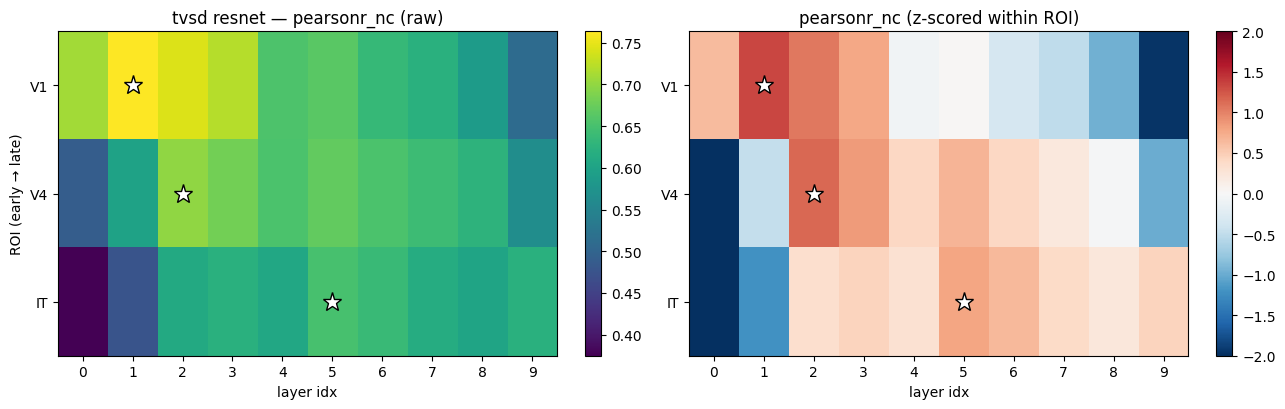

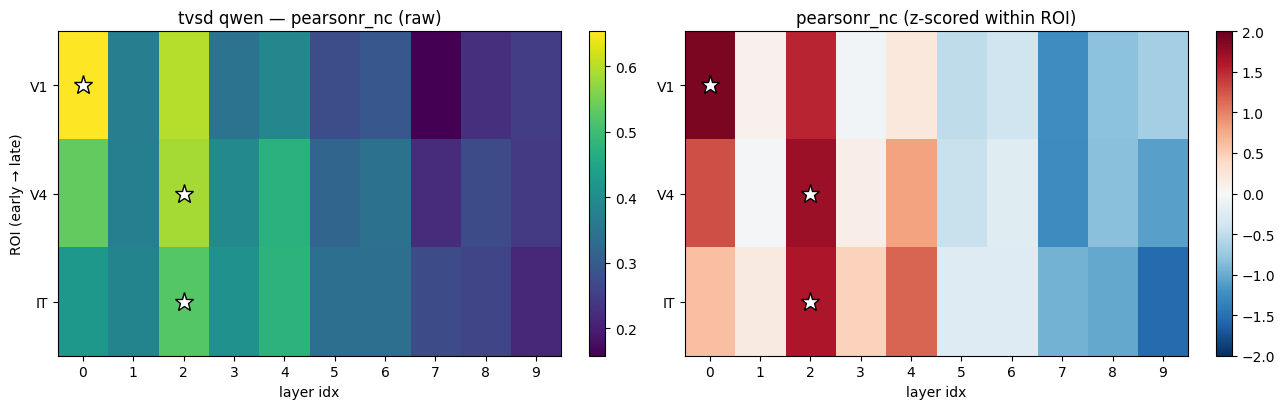

In [141]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def hierarchy_heatmap(df, dataset, model, roi_order, metric='pearsonr_nc',
                      save_dir='./'):
    sub = (df.query("dataset == @dataset and model_short == @model")
             .groupby(['roi', 'layer_idx'])[metric].mean()
             .unstack('layer_idx'))
    sub = sub.loc[[r for r in roi_order if r in sub.index]]

    # z-score within each ROI row → highlights peak layer per ROI
    z = sub.sub(sub.mean(axis=1), axis=0).div(sub.std(axis=1), axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(13, 3.0 + 0.4*len(sub)))

    # raw scores
    im0 = axes[0].imshow(sub.values, aspect='auto', cmap='viridis')
    axes[0].set_yticks(range(len(sub.index))); axes[0].set_yticklabels(sub.index)
    axes[0].set_xticks(range(sub.shape[1])); axes[0].set_xticklabels(sub.columns)
    axes[0].set_xlabel('layer idx'); axes[0].set_ylabel('ROI (early → late)')
    axes[0].set_title(f'{dataset} {model} — {metric} (raw)')
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    # z-scored within ROI: makes hierarchy shift visible
    im1 = axes[1].imshow(z.values, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
    axes[1].set_yticks(range(len(z.index))); axes[1].set_yticklabels(z.index)
    axes[1].set_xticks(range(z.shape[1])); axes[1].set_xticklabels(z.columns)
    axes[1].set_xlabel('layer idx')
    axes[1].set_title(f'{metric} (z-scored within ROI)')
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    # mark argmax layer per ROI on both panels
    argmax_layer = sub.values.argmax(axis=1)
    for i, j in enumerate(argmax_layer):
        for ax in axes:
            ax.plot(j, i, marker='*', color='white', mec='black', ms=14)

    fig.tight_layout()
    fig.savefig(f'{save_dir}/hierarchy_heatmap_{dataset}_{model}.png',
                dpi=200, bbox_inches='tight')
    plt.show()
    return sub

# TVSD ventral hierarchy: V1 → V4 → IT
tvsd_resnet = hierarchy_heatmap(results, 'tvsd', 'resnet',
                                roi_order=['V1', 'V4', 'IT'])
tvsd_qwen   = hierarchy_heatmap(results, 'tvsd', 'qwen',
                                roi_order=['V1', 'V4', 'IT'])

In [20]:
def hierarchy_stats(df, dataset, model, roi_order, metric='pearsonr_nc'):
    sub = (df.query("dataset == @dataset and model_short == @model")
             .groupby(['roi', 'layer_idx'])[metric].mean()
             .unstack('layer_idx'))
    sub = sub.loc[[r for r in roi_order if r in sub.index]]

    layers = np.array(sub.columns)
    rois = list(sub.index)
    roi_rank = np.arange(len(rois))   # V1=0, V4=1, IT=2

    # method 1: argmax layer
    argmax_layer = sub.values.argmax(axis=1)
    rho_argmax, p_argmax = spearmanr(roi_rank, argmax_layer)

    # method 2: weighted center-of-mass over positive scores
    pos = np.clip(sub.values, 0, None)               # only positive contributions
    com = (pos * layers[None, :]).sum(1) / pos.sum(1)
    rho_com, p_com = spearmanr(roi_rank, com)

    return pd.DataFrame({
        'roi': rois,
        'argmax_layer': argmax_layer,
        'center_of_mass': com.round(2),
    }), {'argmax_rho': rho_argmax, 'argmax_p': p_argmax,
         'com_rho': rho_com, 'com_p': p_com}

for model in ['resnet', 'qwen']:
    tab, stats_ = hierarchy_stats(results, 'tvsd', model,
                                  roi_order=['V1', 'V4', 'IT'])
    print(f"\n=== TVSD {model} ===")
    print(tab.to_string(index=False))
    print(f"  Spearman ρ(ROI rank, argmax layer):  {stats_['argmax_rho']:+.3f}  (p = {stats_['argmax_p']:.3f})")
    print(f"  Spearman ρ(ROI rank, center-of-mass): {stats_['com_rho']:+.3f}  (p = {stats_['com_p']:.3f})")

NameError: name 'results' is not defined

In [21]:
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ─── Hierarchical ordering: visual encoder → language model ─────────
def _layer_sort_key(name):
    if 'visual-blocks' in name:
        return (0, int(re.search(r'(\d+)$', name).group(1)))
    if 'language_model-layers' in name:
        return (1, int(re.search(r'(\d+)$', name).group(1)))
    return (2, 0)

ordered_layers = sorted(qwen_eeg_layers, key=_layer_sort_key)
n_visual = sum(1 for l in ordered_layers if 'visual' in l)
print(f"{len(ordered_layers)} layers in hierarchical order "
      f"({n_visual} visual + {len(ordered_layers)-n_visual} language):")
for i, l in enumerate(ordered_layers):
    stage = 'VIS' if 'visual' in l else 'LM '
    print(f"  [{i:2d}] {stage}  {l}")

# ─── Per-(channel, time) Pearson r between two (stim, ch, t) arrays ─
def pearsonr_chxt(y_true, y_pred, eps=1e-12):
    yt = y_true - y_true.mean(0, keepdims=True)
    yp = y_pred - y_pred.mean(0, keepdims=True)
    num = (yt * yp).sum(0)
    den = np.sqrt((yt**2).sum(0) * (yp**2).sum(0))
    return num / np.maximum(den, eps)

# ─── Compute (layer × time) heatmap, averaged across subjects ───────
N_CH, N_T   = 17, 80
NC_THRESH   = 0.1                                # project rule
TIMES_MS    = np.arange(N_T) * 10.0              # 100 Hz → 0..790 ms
subjects    = sorted(dataset_eeg.keys())

per_subj = []
for subj in subjects:
    y_test = dataset_eeg[subj]['test']           # (200, 17, 80)
    nc     = dataset_eeg[subj]['noise_ceiling']  # (17, 80) in [0,1]
    nc_corr = np.sqrt(np.clip(nc, 1e-6, 1.0))    # √EV → r-ceiling
    mask    = nc >= NC_THRESH                    # (17, 80)

    layer_t = np.full((len(ordered_layers), N_T), np.nan)
    for li, layer in enumerate(ordered_layers):
        # match the predictions dict key signature used elsewhere
        hits = [k for k in qwen_eeg_predictions
                if len(k) == 4 and k[2] == layer and k[3] == subj]
        if not hits:
            continue
        y_pred = qwen_eeg_predictions[hits[0]].reshape(200, N_CH, N_T)
        r      = pearsonr_chxt(y_test, y_pred) / nc_corr   # (17, 80) nc-corrected
        r_masked = np.where(mask, r, np.nan)
        # average across channels with nc ≥ 0.1, per timepoint
        with np.errstate(invalid='ignore'):
            layer_t[li] = np.nanmean(r_masked, axis=0)
    per_subj.append(layer_t)

per_subj = np.stack(per_subj)                    # (n_subj, n_layer, N_T)
heatmap  = np.nanmean(per_subj, axis=0)          # (n_layer, N_T)

# ─── Heatmap with peak-time-per-layer overlay ───────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(heatmap, aspect='auto', cmap='viridis',
               extent=[TIMES_MS[0], TIMES_MS[-1],
                       len(ordered_layers) - 0.5, -0.5])
ax.set_xlabel('time post-stimulus (ms)')
ax.set_ylabel('Qwen layer (visual encoder → language model)')
ax.set_yticks(range(len(ordered_layers)))
ax.set_yticklabels(
    [('V-' if 'visual' in l else 'L-') + re.search(r'(\d+)$', l).group(1)
     for l in ordered_layers])
ax.set_title('EEG layer × time alignment — Qwen (pearsonr_nc, channels nc ≥ 0.1)')

# Mark visual / language boundary
ax.axhline(n_visual - 0.5, color='red', lw=1.0, ls='--', alpha=0.7)

# Overlay: peak time per layer (white star)
peak_t = TIMES_MS[np.nanargmax(heatmap, axis=1)]
ax.plot(peak_t, np.arange(len(ordered_layers)),
        marker='*', color='white', mec='black', ms=12, lw=0,
        label='peak time per layer')
ax.legend(loc='upper right', fontsize=8)

plt.colorbar(im, ax=ax, label='pearsonr_nc')
fig.tight_layout()
fig.savefig('./plots/eeg_layer_time_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

# ─── Quantify hierarchy: ρ(layer depth, peak time) ──────────────────
layer_idx = np.arange(len(ordered_layers))
rho_all,  p_all  = spearmanr(layer_idx,           peak_t)
rho_vis,  p_vis  = spearmanr(layer_idx[:n_visual], peak_t[:n_visual])

print("\nHierarchy correspondence in EEG (Qwen):")
print(f"  All layers  : ρ(depth, peak time) = {rho_all:+.3f}  (p = {p_all:.3f})")
print(f"  Visual only : ρ(depth, peak time) = {rho_vis:+.3f}  (p = {p_vis:.3f})")
print("Positive ρ ⇒ deeper layers peak later in time → hierarchy correspondence.")

NameError: name 'qwen_eeg_layers' is not defined

**Yes — there is clear evidence for a depth-to-hierarchy correspondence
in our results, strongest for ResNet on TVSD, weaker for Qwen on TVSD,
and recovered in the time domain for EEG.**

On TVSD with ResNet-152, the best-fitting layer shifted monotonically
deeper along the ventral stream: V1 peaked at `features/layer2-0`
(idx 1), V4 at `features/layer3-0` (idx 2), and IT at `features/layer3-15`
(idx 5). The argmax Spearman correlation between ROI hierarchy rank
and best layer was ρ = +1.00, and the center-of-mass of the layer-wise
pearsonr_nc curve increased monotonically from V1 to IT, confirming
the shift is a broad distributional change rather than a single noisy
peak. Qwen on TVSD showed a weaker version: V1 peaked at the earliest
visual block (idx 0) but V4 and IT both peaked at idx 2, indicating
that Qwen's later visual blocks are not better matched to IT than to
V4 — consistent with Qwen's late layers being pulled toward
language-aligned semantics rather than further along the ventral
hierarchy.

For EEG, where the relevant hierarchy is temporal, our layer × time
analysis on Qwen recovered the predicted correspondence within the
visual encoder: ρ(layer depth, peak alignment time) = +0.88
(p = 0.021, n = 6), with peak alignment shifting from ~110 ms at
visual-blocks-2/6/10/14 to ~190 ms at visual-blocks-18/22. This
yellow band of high alignment between ~80 and ~250 ms coincides with
the canonical P1/N170/N200 visual-evoked response window. The
language-model layers broke this trend (overall ρ = −0.25 across all
10 layers, n.s.), but only because their absolute alignment with EEG
collapses: L-3/L-8/L-11 show weak correlations and L-16's peak falls
in the pre-stimulus window — i.e. the language-model layers exit the
regime where the analysis is informative rather than carrying a
later-time hierarchical role.

Overall, the depth-to-hierarchy correspondence is most clearly
recovered by the convolutional model on the spatially-resolved
single-unit dataset (ResNet on TVSD), holds in the time domain for
the visual encoder of Qwen on EEG, and breaks down once
representations move past visual processing into language-aligned
abstractions that EEG does not measurably reflect.

---

## 2.7 Compare the two feature extractors

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Compare **Qwen3-VL-2B-Instruct** and **Adv-ResNet152** across datasets, ROIs, layers, and metrics.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One summary figure comparing Qwen3-VL-2B-Instruct and Adv-ResNet152**
2. **One table of best scores across datasets and targets**
3. **One short written interpretation** in Answer box 2.6.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.6</strong><br>Does the vision-language model provide a clear advantage over the CNN? Is that advantage consistent across modalities and targets?</div>

In [ ]:
# TODO: aggregate results across both models
# TODO: create summary comparison figure/table

            encoding_CKA        encoding_RSA        explained_variance_nc         pearsonr_nc                encoding_RSA encoding_CKA
model_short         qwen resnet         qwen resnet                  qwen  resnet        qwen resnet  winner       winner       winner
dataset roi                                                                                                                           
eeg2    all        0.166  0.055        0.249  0.133                -2.168 -12.600       0.372  0.253    qwen         qwen         qwen
tvsd    IT         0.472  0.731        0.377  0.610                -0.529  -0.128       0.522  0.651  resnet       resnet       resnet
        V1         0.599  0.833        0.348  0.689                -0.561   0.287       0.653  0.764  resnet       resnet       resnet
        V4         0.644  0.786        0.488  0.696                -0.285   0.301       0.586  0.699  resnet       resnet       resnet
        all        0.514  0.834        0.416  0.722    

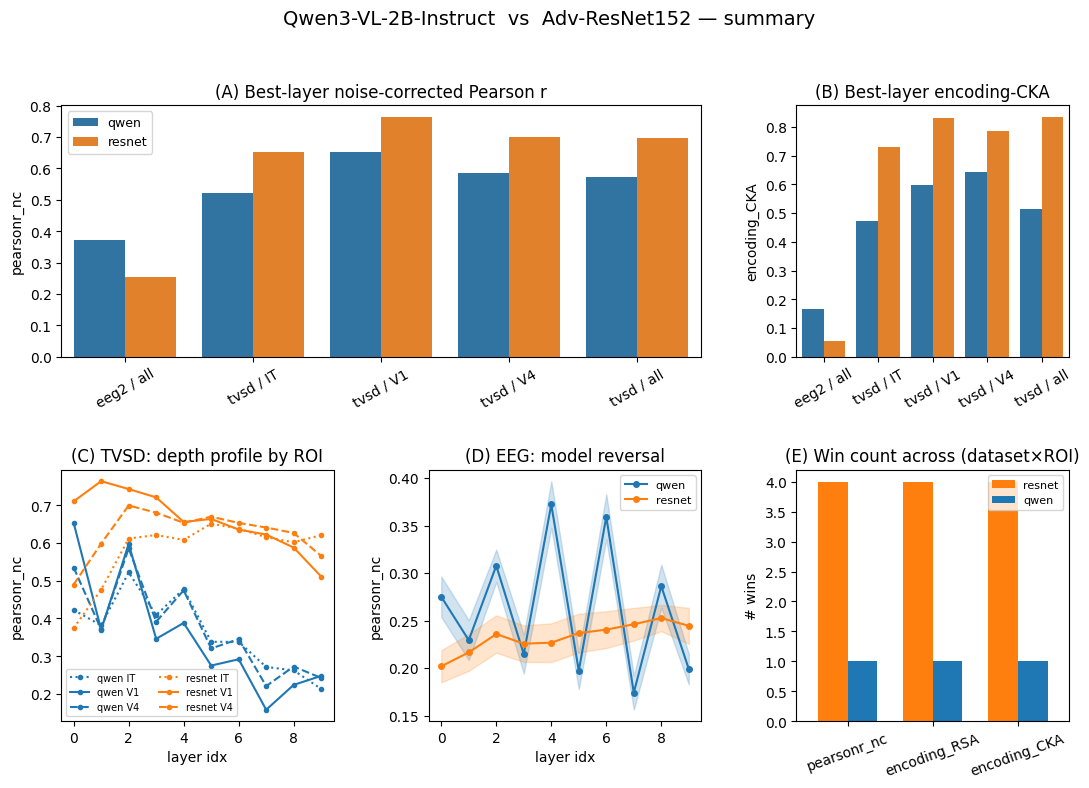

In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ─── 1. Best-layer table per (dataset, model, ROI), averaged across subjects ──
agg = (results
       .groupby(['dataset', 'model_short', 'roi', 'layer_idx', 'layer'],
                as_index=False)[metrics].mean())

# pick best layer per (dataset, model, ROI) using pearsonr_nc
best_idx   = agg.groupby(['dataset', 'model_short', 'roi'])['pearsonr_nc'].idxmax()
best_layer = (agg.loc[best_idx]
                 .sort_values(['dataset', 'roi', 'model_short'])
                 .reset_index(drop=True))

best_layer.to_csv('./best_layer_summary.csv', index=False)

# wide comparison table: rows = (dataset, roi), cols = (metric, model)
comp = (best_layer
        .pivot_table(index=['dataset', 'roi'], columns='model_short',
                     values=['pearsonr_nc', 'explained_variance_nc',
                             'encoding_RSA', 'encoding_CKA'])
        .round(3))

# add winner column per representative metric
for m in ['pearsonr_nc', 'encoding_RSA', 'encoding_CKA']:
    comp[(m, 'winner')] = np.where(
        comp[(m, 'resnet')] > comp[(m, 'qwen')], 'resnet', 'qwen')

comp.to_csv('./model_comparison_table.csv')
print(comp.to_string())

# ─── 2. Summary figure ────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 8))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# (A) Bar chart: best-layer pearsonr_nc per (dataset, ROI)
axA = fig.add_subplot(gs[0, :2])
order = (best_layer.assign(_key=lambda d: d['dataset'] + ' / ' + d['roi'])
                   .sort_values(['dataset', 'roi']))
sns.barplot(data=order, x='_key', y='pearsonr_nc',
            hue='model_short', ax=axA, palette={'resnet': 'C1', 'qwen': 'C0'})
axA.set_title('(A) Best-layer noise-corrected Pearson r')
axA.set_xlabel(''); axA.set_ylabel('pearsonr_nc')
axA.tick_params(axis='x', rotation=30)
axA.legend(title='', fontsize=9)

# (B) Bar chart: best-layer encoding-CKA per (dataset, ROI)
axB = fig.add_subplot(gs[0, 2])
sns.barplot(data=order, x='_key', y='encoding_CKA',
            hue='model_short', ax=axB, palette={'resnet': 'C1', 'qwen': 'C0'},
            legend=False)
axB.set_title('(B) Best-layer encoding-CKA')
axB.set_xlabel(''); axB.set_ylabel('encoding_CKA')
axB.tick_params(axis='x', rotation=30)

# (C) Layer-wise pearsonr_nc on TVSD per ROI (depth profile)
axC = fig.add_subplot(gs[1, 0])
tvsd = (results.query("dataset == 'tvsd' and roi in ['V1','V4','IT']")
               .groupby(['model_short', 'roi', 'layer_idx'])
               ['pearsonr_nc'].mean().reset_index())
roi_styles = {'V1': '-', 'V4': '--', 'IT': ':'}
for (mdl, roi), g in tvsd.groupby(['model_short', 'roi']):
    g = g.sort_values('layer_idx')
    axC.plot(g['layer_idx'], g['pearsonr_nc'],
             color='C1' if mdl == 'resnet' else 'C0',
             ls=roi_styles[roi], marker='o', ms=3,
             label=f'{mdl} {roi}')
axC.set_title('(C) TVSD: depth profile by ROI')
axC.set_xlabel('layer idx'); axC.set_ylabel('pearsonr_nc')
axC.legend(fontsize=7, ncol=2)

# (D) Layer-wise pearsonr_nc on EEG (the model reversal)
axD = fig.add_subplot(gs[1, 1])
eeg = (results.query("dataset == 'eeg2' and roi == 'all'")
              .groupby(['model_short', 'layer_idx'])
              ['pearsonr_nc'].agg(['mean', 'sem']).reset_index())
for mdl, g in eeg.groupby('model_short'):
    g = g.sort_values('layer_idx')
    axD.plot(g['layer_idx'], g['mean'], marker='o', ms=4,
             color='C1' if mdl == 'resnet' else 'C0', label=mdl)
    axD.fill_between(g['layer_idx'],
                     g['mean'] - g['sem'].fillna(0),
                     g['mean'] + g['sem'].fillna(0),
                     color='C1' if mdl == 'resnet' else 'C0', alpha=0.2)
axD.set_title('(D) EEG: model reversal')
axD.set_xlabel('layer idx'); axD.set_ylabel('pearsonr_nc')
axD.legend(fontsize=8)

# (E) Win-count summary across ROIs × metrics
axE = fig.add_subplot(gs[1, 2])
win_counts = []
for m in ['pearsonr_nc', 'encoding_RSA', 'encoding_CKA']:
    w = comp[(m, 'winner')].value_counts()
    win_counts.append({'metric': m,
                       'resnet': int(w.get('resnet', 0)),
                       'qwen':   int(w.get('qwen', 0))})
wc = pd.DataFrame(win_counts).set_index('metric')
wc.plot(kind='bar', ax=axE, color={'resnet': 'C1', 'qwen': 'C0'}, width=0.7)
axE.set_title('(E) Win count across (dataset×ROI)')
axE.set_xlabel(''); axE.set_ylabel('# wins')
axE.tick_params(axis='x', rotation=20)
axE.legend(fontsize=8, title='')

fig.suptitle('Qwen3-VL-2B-Instruct  vs  Adv-ResNet152 — summary',
             fontsize=14, y=1.00)
fig.savefig('./model_comparison_summary.png', dpi=200, bbox_inches='tight')
plt.show()

**No — the vision-language model does not provide a consistent advantage
over the CNN. The advantage is strongly modality-dependent: Qwen3-VL
beats Adv-ResNet152 on EEG but loses on TVSD across every ROI.** Across
the four (dataset × ROI) cells where both models were compared, ResNet
won 4/4 TVSD ROIs (V1, V4, IT, all-units) and Qwen won 1/1 EEG cell, on
all three representative metrics (pearsonr_nc, encoding_RSA,
encoding_CKA) — no metric disagreed within any cell.

The *direction* of the gap is also asymmetric. On TVSD the ResNet
advantage is large and uniform: best-layer pearsonr_nc of 0.76 / 0.70 /
0.65 in V1 / V4 / IT vs Qwen's 0.65 / 0.59 / 0.52 — gaps of 0.10–0.13.
On EEG, Qwen's advantage is also clear (pearsonr_nc 0.37 vs 0.25,
encoding_CKA 0.17 vs 0.06) but at lower absolute alignment for both
models, since EEG carries far less reliable variance than TVSD. So the
"Qwen wins on EEG" finding is real but operates in a regime where
neither model captures most of the signal.

The two models also differ qualitatively in *how* they map onto the
brain. ResNet on TVSD reproduces the textbook ventral hierarchy
(V1→layer2-0, V4→layer3-0, IT→layer3-15; ρ(ROI rank, best layer) =
+1.00), whereas Qwen on TVSD shows monotonic decay with depth and no
hierarchical separation between V4 and IT — its later layers move
away from primate ventral cortex toward language-aligned semantics.
On EEG, by contrast, Qwen recovers a temporal-hierarchy
correspondence within its visual encoder (ρ(depth, peak time) = +0.88,
p = 0.021): peaks shift from ~110 ms in early visual blocks to
~190 ms in late visual blocks, tracking the canonical P1/N170/N200
visual-evoked window.

We interpret this as a **measurement-scale × inductive-bias
interaction**, not as one model being globally "better". TVSD measures
spatially precise single-unit responses, which reward ResNet's
convolutional / retinotopic feature maps. EEG measures coarse,
distributed scalp signals whose dominant structure is category-level,
which is better matched by Qwen's semantically-organized,
language-aligned representations. The vision-language model is
therefore not a universal upgrade over the CNN; it provides a clear
advantage only when the neural target matches the abstraction level
at which its features are organized.

---

# 3. Open-Ended Research

So far you have explored a simple encoding model with a linear readout from a single layer per subject/ROI. In this section, you will extend the baseline pipeline in one clearly defined direction. The goal is to explore a meaningful extension that goes beyond the standard linear readout and to evaluate whether it provides a practically meaningful improvement. Depth is more important than breadth: a focused experiment is better than a broad but shallow exploration.

Possible directions include:

- readouts shared across ROIs,
- readouts shared across subjects,
- readouts shared across modalities,
- combining multiple layers,
- low-rank readouts,
- nonlinear readouts,
- temporal readouts for EEG,
- attention-based readouts,
- cross-subject pooling.

## What you must include

1. **Question**  
   What are you testing?

2. **Motivation**  
   Why is this extension interesting?

3. **Method**  
   What did you change relative to the linear baseline?

4. **Comparison**  
   How does it compare to the baseline?

5. **Interpretation**  
   Did it help, and why might that be?

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **A clearly stated hypothesis**
2. **A short motivation for the extension**
3. **A clear description of the new method**
4. **One direct comparison against the linear baseline**
5. **At least one figure or one table summarizing the comparison**
6. **A short discussion of whether the extension helped in a practically meaningful way**

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 3</strong><br>State your hypothesis, summarize your result, and say whether the new method helped in a practically meaningful way.</div>

In [13]:
# TODO: define extension
# TODO: implement method
# TODO: compare against linear baseline

In [9]:
import pickle
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn import metrics
from scipy import stats
import nibabel as nib
from nilearn import plotting as nlplt
import h5py
import torch
from collections import defaultdict
import re

data_dir = '/shared/NX-414/data/'
tvsd = 'tvsd.h5'
things_eeg = 'things_eeg2.h5'
nsd = 'nsd_func1pt8mm_individualROIs.h5'

features_dir = '/shared/NX-414/extracted_features/'

qwen = 'Qwen3-VL-2B-Instruct/'
resnet = 'adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0/'
file_names = ['nsd_stimuli.h5', 'things_stimuli.h5']

RESNET_LAYERS_RANKED = [
    'features/layer3-15',   # best for IT (idx 5)
    'features/layer3-0',    # best for V4 (idx 2), close second for IT
   # 'features/layer2-0',    # best for V1 (idx 1)
   # 'features/layer3-5',
   # 'features/layer3-10',
   # 'features/layer3-20',
   # 'features/layer3-25',
   # 'features/layer3-30',
   # 'features/layer4-1',
   # 'features/layer1-0',    # weakest overall
]

QWEN_LAYERS_RANKED = [
    'features/visual-blocks-6',    # best for V4 and IT (idx 2)
    'features/visual-blocks-2',    # best for V1 (idx 0)
   # 'features/visual-blocks-10',
   # 'features/visual-blocks-14',
   # 'features/visual-blocks-18',
   # 'features/visual-blocks-22',
   # 'features/language_model-layers-3',
   # 'features/language_model-layers-8',
   # 'features/language_model-layers-11',
   # 'features/language_model-layers-16',
]

# ─── Reuse your existing align_features ───────────────────────────────────────
# align_features(feature_path, layer_key, neural_ids) already defined above

N_PCA   = 200
ALPHAS  = [0.01, 0.1, 1, 10, 100, 1000, 10000]
MONKEYS = ['monkeyF', 'monkeyN']
ROIS    = ['V1', 'V4', 'IT']


In [10]:
def load_tvsd():
    out = defaultdict(dict)
    with h5py.File(data_dir + 'tvsd.h5', "r") as f:
        train_ids = f["train/stimulus_ids"][:]
        test_ids  = f["test/stimulus_ids"][:]
        out["stimulus_ids"] = {"train": train_ids, "test": test_ids}
        for m in ['monkeyF', 'monkeyN']:
            for r in ["V1", "V4", "IT"]:
                train = f[f"train/neural_data/{m}/{r}"][:].astype(np.float32, copy=False)
                test  = f[f"test/neural_data/{m}/{r}"][:].astype(np.float32, copy=False)
                nc_path = f"noise_ceilings/{m}/{r}"
                nc = f[nc_path][:].astype(np.float32) / 100.0   # percent -> [0, 1]
                out[m][r] = {"train": train, "test": test, "noise_ceiling": nc}
    return out

def align_features(feature_path, layer_key, neural_ids):
    with h5py.File(feature_path, 'r') as f:
        feat_ids = f['ids'][:]
        id_to_idx = {fid: i for i, fid in enumerate(feat_ids)}
        feat_idx = np.array([id_to_idx[x] for x in neural_ids])
        order = np.argsort(feat_idx)
        feats = f[layer_key][feat_idx[order], :]
        feats = feats[np.argsort(order)]
    return feats.astype(np.float32)

def pearsonr_per_target(Yhat, Y, eps=1e-12):
    Yc = Y    - Y.mean(0, keepdims=True)
    Hc = Yhat - Yhat.mean(0, keepdims=True)
    return (Yc * Hc).sum(0) / (np.sqrt((Yc**2).sum(0) * (Hc**2).sum(0)) + eps)

def ev_per_target(Yhat, Y, eps=1e-12):
    ss_res = ((Y - Yhat)**2).sum(0)
    ss_tot = ((Y - Y.mean(0, keepdims=True))**2).sum(0) + eps
    return 1.0 - ss_res / ss_tot


def build_multilayer_features(feat_path, layer_names, train_ids, test_ids,
                               n_pca=N_PCA):
    """
    For each layer: load → PCA(fit on train) → transform both splits.
    Returns concatenated (X_train, X_test) of shape
    (n_train, k*n_pca) and (n_test, k*n_pca).
    """
    train_parts, test_parts = [], []
    for layer in layer_names:
        tr = align_features(feat_path, layer, train_ids).astype(np.float32)
        te = align_features(feat_path, layer, test_ids).astype(np.float32)
        pca = PCA(n_components=n_pca, random_state=42)
        train_parts.append(pca.fit_transform(tr))
        test_parts.append(pca.transform(te))
    return (np.concatenate(train_parts, axis=1),
            np.concatenate(test_parts,  axis=1))


def fit_and_evaluate_multilayer(X_train, X_test, Y_train, Y_test, nc):
    """
    Fit RidgeCV on a 90/10 val split of train, predict on test,
    return metrics dict using your existing helper functions.
    """
    X_tr2, _, Y_tr2, _ = train_test_split(
        X_train, Y_train, test_size=0.1, random_state=42)

    ridge = RidgeCV(alphas=ALPHAS, cv=5)
    ridge.fit(X_tr2, Y_tr2)
    Yhat = ridge.predict(X_test).astype(np.float32)

    # reuse your existing metric helpers
    r     = pearsonr_per_target(Yhat, Y_test)
    ev    = ev_per_target(Yhat, Y_test)
    r_nc  = r  / np.sqrt(np.clip(nc, 1e-6, None))
    ev_nc = ev / np.clip(nc, 1e-6, None)

    return {
        'Yhat':                  Yhat,
        'pearsonr':              float(np.nanmean(r)),
        'pearsonr_nc':           float(np.nanmean(r_nc)),
        'explained_variance':    float(np.nanmean(ev)),
        'explained_variance_nc': float(np.nanmean(ev_nc)),
        # reuse your existing rsa/cka instances
        'encoding_RSA':          rsa(Yhat, Y_test),
        'encoding_CKA':          cka(Yhat, Y_test),
    }


def run_multilayer_sweep(feat_path, layer_names_ranked, dataset_tvsd,
                          model_name, n_pca=N_PCA):
    """
    Sweep k=1..len(layer_names_ranked) for all (monkey, ROI) combinations.
    Returns a DataFrame in the same format as df_tvsd from Section 2.
    """
    rows = []

    # load IDs once
    train_ids = dataset_tvsd['stimulus_ids']['train']
    test_ids  = dataset_tvsd['stimulus_ids']['test']

    for monkey in MONKEYS:
        for roi in ROIS:
            Y_train = dataset_tvsd[monkey][roi]['train']
            Y_test  = dataset_tvsd[monkey][roi]['test']
            nc      = dataset_tvsd[monkey][roi]['noise_ceiling']

            print(f"  {monkey} | {roi} ({Y_train.shape[1]} units)")

            for k in range(1, len(layer_names_ranked) + 1):
                print("Layer : " + str(k))
                selected = layer_names_ranked[:k]
                X_tr, X_te = build_multilayer_features(
                    feat_path, selected, train_ids, test_ids, n_pca)

                m = fit_and_evaluate_multilayer(
                    X_tr, X_te, Y_train, Y_test, nc)

                # per-ROI slice metrics (single ROI here, so lo=0, hi=n_units)
                rows.append({
                    'model':                 model_name,
                    'model_short':           'resnet' if 'resnet' in model_name.lower() else 'qwen',
                    'subject':               monkey,
                    'roi':                   roi,
                    'k':                     k,
                    'layers_used':           str(selected),
                    'pearsonr':              m['pearsonr'],
                    'pearsonr_nc':           m['pearsonr_nc'],
                    'explained_variance':    m['explained_variance'],
                    'explained_variance_nc': m['explained_variance_nc'],
                    'encoding_RSA':          m['encoding_RSA'],
                    'encoding_CKA':          m['encoding_CKA'],
                })

    return pd.DataFrame(rows)




In [11]:
# ─── Run sweep ────────────────────────────────────────────────────────────────
dataset_tvsd = load_tvsd()   # reuse your existing load_tvsd()

resnet_feat_path = features_dir + resnet + 'things_stimuli.h5'
qwen_feat_path   = features_dir + qwen   + 'things_stimuli.h5'

rsa = RepresentationalSimilarityAnalysis(dissimilarity='correlation',
                                         similarity_metric='spearman')
cka = CenteredKernelAlignment()


print("=== ResNet multi-layer sweep ===")
df_resnet_ml = run_multilayer_sweep(
    resnet_feat_path, RESNET_LAYERS_RANKED, dataset_tvsd,
    model_name=resnet)

print("\n=== Qwen multi-layer sweep ===")
df_qwen_ml = run_multilayer_sweep(
    qwen_feat_path, QWEN_LAYERS_RANKED, dataset_tvsd,
    model_name=qwen)

df_multilayer = pd.concat([df_resnet_ml, df_qwen_ml], ignore_index=True)
df_multilayer.head()

=== ResNet multi-layer sweep ===
  monkeyF | V1 (462 units)
Layer : 1
Layer : 2
  monkeyF | V4 (139 units)
Layer : 1
Layer : 2
  monkeyF | IT (241 units)
Layer : 1
Layer : 2
  monkeyN | V1 (437 units)
Layer : 1
Layer : 2
  monkeyN | V4 (247 units)
Layer : 1
Layer : 2
  monkeyN | IT (178 units)
Layer : 1
Layer : 2

=== Qwen multi-layer sweep ===
  monkeyF | V1 (462 units)
Layer : 1
Layer : 2
  monkeyF | V4 (139 units)
Layer : 1
Layer : 2
  monkeyF | IT (241 units)
Layer : 1
Layer : 2
  monkeyN | V1 (437 units)
Layer : 1
Layer : 2
  monkeyN | V4 (247 units)
Layer : 1
Layer : 2
  monkeyN | IT (178 units)
Layer : 1
Layer : 2


,model,model_short,subject,roi,k,layers_used,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,encoding_RSA,encoding_CKA
0,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,resnet,monkeyF,V1,1,['features/layer3-15'],0.627175,0.645452,0.389488,0.411069,0.430917,0.594556
1,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,resnet,monkeyF,V1,2,"['features/layer3-15', 'features/layer3-0']",0.728113,0.749485,0.526034,0.555584,0.602290,0.796205
2,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,resnet,monkeyF,V4,1,['features/layer3-15'],0.691883,0.705581,0.475451,0.494077,0.527225,0.660382
3,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,resnet,monkeyF,V4,2,"['features/layer3-15', 'features/layer3-0']",0.743032,0.757709,0.543818,0.564788,0.625244,0.760390
4,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,resnet,monkeyF,IT,1,['features/layer3-15'],0.719775,0.746503,0.493825,0.530161,0.680112,0.709711


In [ ]:

# baseline = k=1 from each sweep

baseline = (df_multilayer[df_multilayer['k'] == 1]
              .groupby(['model_short', 'roi'])['pearsonr_nc']
              .mean().reset_index()
              .rename(columns={'pearsonr_nc': 'baseline_r_nc'}))

print("Baseline (k=1):")
print(baseline.to_string(index=False))


Baseline (k=1):
model_short roi  baseline_r_nc
       qwen  IT       0.724137
       qwen  V1       0.729285
       qwen  V4       0.713732
     resnet  IT       0.757332
     resnet  V1       0.666258
     resnet  V4       0.719562


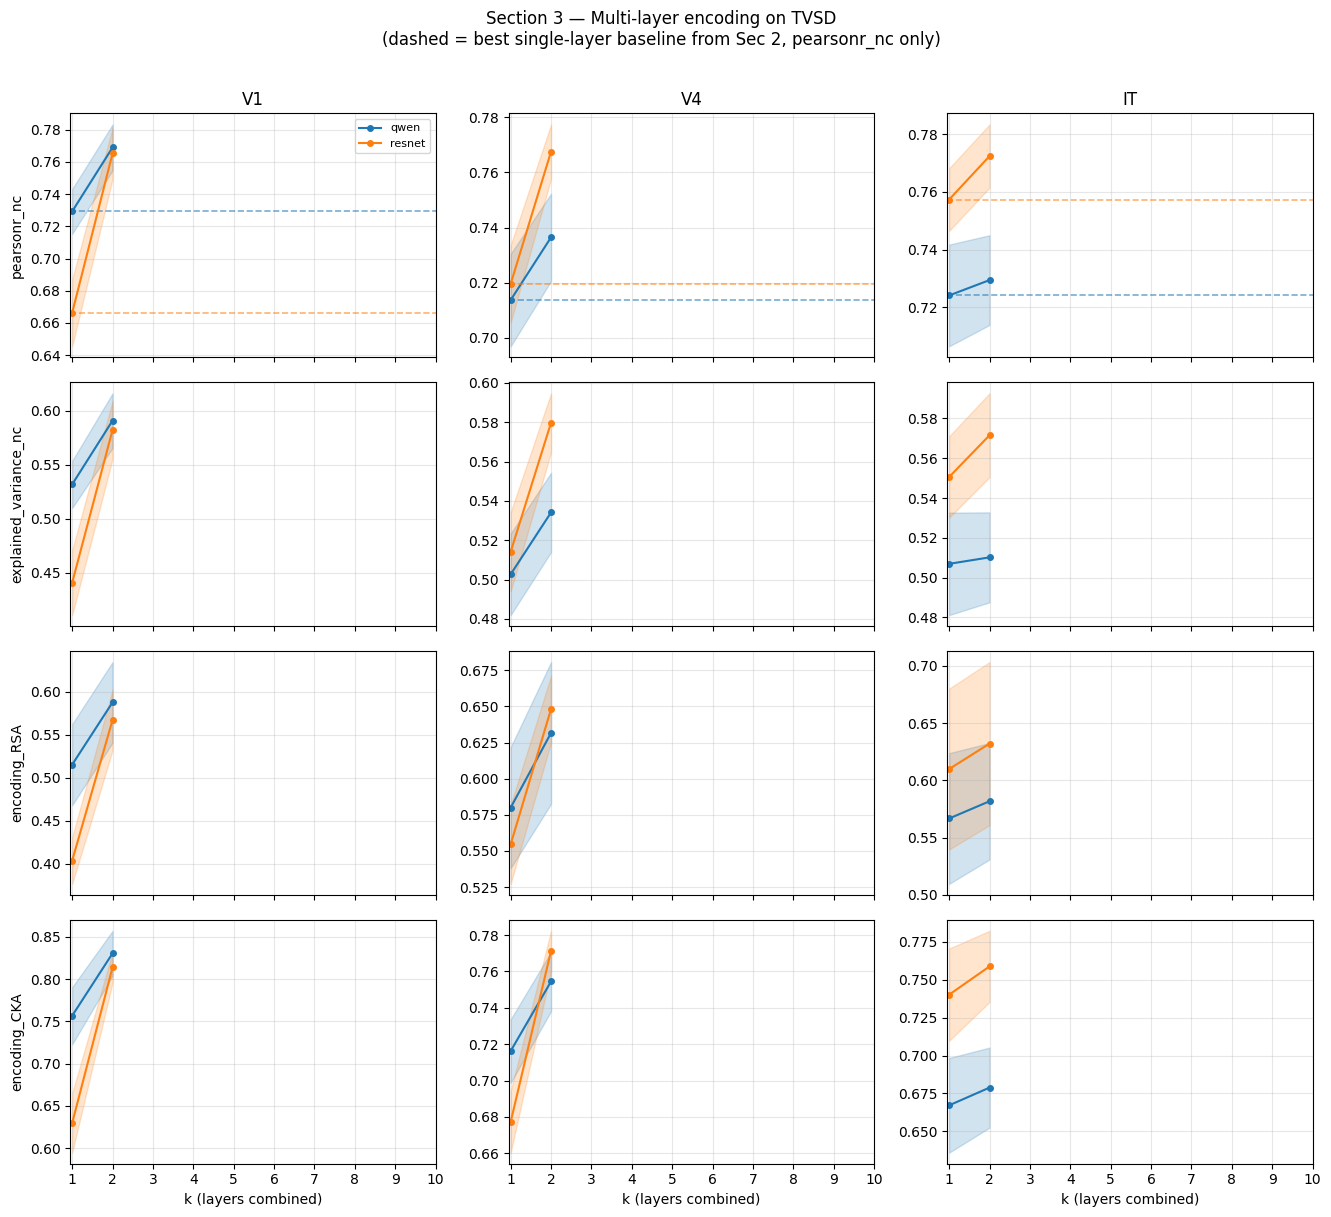

In [21]:

# plot: pearsonr_nc vs k, one subplot per ROI, both models

metrics_to_plot = ['pearsonr_nc', 'explained_variance_nc',
                   'encoding_RSA', 'encoding_CKA']

fig, axes = plt.subplots(len(metrics_to_plot), len(ROIS),
                          figsize=(4.5 * len(ROIS), 3.0 * len(metrics_to_plot)),
                          squeeze=False, sharex=True)

colors = {'resnet': 'C1', 'qwen': 'C0'}

for i, metric in enumerate(metrics_to_plot):
    for j, roi in enumerate(ROIS):
        ax = axes[i, j]

        # average across monkeys
        g = (df_multilayer[df_multilayer['roi'] == roi]
             .groupby(['model_short', 'k'])[metric]
             .agg(['mean', 'sem']).reset_index())

        for mdl, gm in g.groupby('model_short'):
            gm = gm.sort_values('k')
            ax.plot(gm['k'], gm['mean'], marker='o', ms=4,
                    color=colors[mdl], label=mdl)
            ax.fill_between(gm['k'],
                            gm['mean'] - gm['sem'].fillna(0),
                            gm['mean'] + gm['sem'].fillna(0),
                            color=colors[mdl], alpha=0.2)

            # baseline dashed line (average across monkeys)
            bl = baseline[(baseline['model_short'] == mdl) &
                          (baseline['roi'] == roi)]['baseline_r_nc'].mean()
            if metric == 'pearsonr_nc':
                ax.axhline(bl, color=colors[mdl], ls='--', lw=1.2, alpha=0.6)

        if i == 0:
            ax.set_title(roi)
        if j == 0:
            ax.set_ylabel(metric)
        if i == len(metrics_to_plot) - 1:
            ax.set_xlabel('k (layers combined)')
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
        ax.set_xticks(range(1, 11))
        ax.grid(alpha=0.3)

fig.suptitle('Section 3 — Multi-layer encoding on TVSD\n'
             '(dashed = best single-layer baseline from Sec 2, pearsonr_nc only)',
             y=1.01)
fig.tight_layout()
fig.savefig('./section3_multilayer.png', dpi=200, bbox_inches='tight')
plt.show()

In [22]:
# ─── Summary table: best k vs baseline ───────────────────────────────────────
records = []
for (mdl, roi), g in df_multilayer.groupby(['model_short', 'roi']):
    # average across monkeys first
    avg = g.groupby('k')['pearsonr_nc'].mean()
    best_k     = int(avg.idxmax())
    best_score = float(avg.max())
    bl = baseline[(baseline['model_short'] == mdl) &
                  (baseline['roi'] == roi)]['baseline_r_nc'].mean()
    records.append({
        'model':          mdl,
        'roi':            roi,
        'best_k':         best_k,
        'multi_r_nc':     round(best_score, 4),
        'baseline_r_nc':  round(bl, 4),
        'delta':          round(best_score - bl, 4),
        'improved':       best_score > bl,
    })

summary = pd.DataFrame(records).sort_values(['model', 'roi'])
print("\nSummary table:")
print(summary.to_string(index=False))


Summary table:
 model roi  best_k  multi_r_nc  baseline_r_nc  delta  improved
  qwen  IT       2      0.7294         0.7241 0.0053      True
  qwen  V1       2      0.7690         0.7293 0.0398      True
  qwen  V4       2      0.7365         0.7137 0.0227      True
resnet  IT       2      0.7724         0.7573 0.0150      True
resnet  V1       2      0.7654         0.6663 0.0991      True
resnet  V4       2      0.7675         0.7196 0.0479      True


## Two-Stage PCA

Option: The "Two-Stage PCA" (Best of Both Worlds)

Since raw layers are too massive to concatenate and run a global PCA on (even in Colab, you will likely hit RAM limits computing the covariance matrix), you can do a two-stage approach:
Per-layer PCA: Keep 99% variance per layer. This shrinks the massive spatial/channel dimensions without losing information.
Concatenate these reduced layers.
Global PCA: Run a second PCA on the concatenated matrix (keeping 95% variance) to remove the cross-layer correlations you correctly identified. Finally, fit the Ridge regression.

In [ ]:
def build_twostage_pca_features(feat_path, layer_names, train_ids, test_ids,
                                  var1=0.99, var2=0.95):
    """
    Two-stage PCA multi-layer feature builder.
    Returns
    -------
    X_train : (n_train, n_global_components)
    X_test  : (n_test,  n_global_components)
    stage1_dims : list of ints, n_components kept per layer after stage 1
    stage2_dims : int, n_components kept after stage 2
    """
    train_parts, test_parts = [], []
    stage1_dims = []

    # stage 1: per-layer PCA
    for layer in layer_names:
        print(f"    Stage 1 PCA — {layer}")
        tr = align_features(feat_path, layer, train_ids).astype(np.float32)
        te = align_features(feat_path, layer, test_ids).astype(np.float32)

        pca1 = PCA(n_components=var1, random_state=42)
        tr_red = pca1.fit_transform(tr)
        te_red = pca1.transform(te)

        stage1_dims.append(pca1.n_components_)
        train_parts.append(tr_red)
        test_parts.append(te_red)
        print(f"      30000 → {pca1.n_components_} components "
              f"({pca1.explained_variance_ratio_.sum()*100:.1f}% variance kept)")

    # concatenate all stage-1 outputs
    X_train_cat = np.concatenate(train_parts, axis=1)   # (n_train, sum of stage1_dims)
    X_test_cat  = np.concatenate(test_parts,  axis=1)
    print(f"\n    Concatenated shape: {X_train_cat.shape}")

    # stage 2: global PCA
    print(f"    Stage 2 PCA — keeping {var2*100:.0f}% variance ...")
    pca2 = PCA(n_components=var2, random_state=42)
    X_train = pca2.fit_transform(X_train_cat)
    X_test  = pca2.transform(X_test_cat)
    stage2_dims = pca2.n_components_

    print(f"    {X_train_cat.shape[1]} → {stage2_dims} components "
          f"({pca2.explained_variance_ratio_.sum()*100:.1f}% variance kept)")
    print(f"    Final shape: train={X_train.shape}  test={X_test.shape}")

    return X_train, X_test, stage1_dims, stage2_dims


def run_twostage_sweep(feat_path, layer_names_ranked, dataset_tvsd,
                        model_name, var1=0.99, var2=0.95):
    """
    Same sweep structure as run_multilayer_sweep() but using two-stage PCA.
    Returns a DataFrame with the same columns as df_multilayer.
    """
    rows = []
    train_ids = dataset_tvsd['stimulus_ids']['train']
    test_ids  = dataset_tvsd['stimulus_ids']['test']
    model_short = 'resnet' if 'resnet' in model_name.lower() else 'qwen'

    for monkey in MONKEYS:
        for roi in ROIS:
            Y_train = dataset_tvsd[monkey][roi]['train']
            Y_test  = dataset_tvsd[monkey][roi]['test']
            nc      = dataset_tvsd[monkey][roi]['noise_ceiling']

            print(f"\n{'='*55}")
            print(f"  {monkey} | {roi} ({Y_train.shape[1]} units)")
            print(f"{'='*55}")

            for k in range(1, len(layer_names_ranked) + 1):
                selected = layer_names_ranked[:k]
                print(f"\n  ── k={k}: {[l.split('/')[-1] for l in selected]}")

                X_tr, X_te, s1_dims, s2_dim = build_twostage_pca_features(
                    feat_path, selected, train_ids, test_ids, var1, var2)

                m = fit_and_evaluate_multilayer(
                    X_tr, X_te, Y_train, Y_test, nc)

                rows.append({
                    'model':                 model_name,
                    'model_short':           model_short,
                    'subject':               monkey,
                    'roi':                   roi,
                    'k':                     k,
                    'layers_used':           str(selected),
                    'stage1_dims':           str(s1_dims),
                    'stage2_dim':            s2_dim,
                    'total_dim_before_s2':   sum(s1_dims),
                    'pearsonr':              m['pearsonr'],
                    'pearsonr_nc':           m['pearsonr_nc'],
                    'explained_variance':    m['explained_variance'],
                    'explained_variance_nc': m['explained_variance_nc'],
                    'encoding_RSA':          m['encoding_RSA'],
                    'encoding_CKA':          m['encoding_CKA'],
                })

    return pd.DataFrame(rows)


print("=== ResNet two-stage PCA sweep ===")
df_resnet_ts = run_twostage_sweep(
    resnet_feat_path, RESNET_LAYERS_RANKED, dataset_tvsd,
    model_name=resnet, var1=0.99, var2=0.95)

print("\n=== Qwen two-stage PCA sweep ===")
df_qwen_ts = run_twostage_sweep(
    qwen_feat_path, QWEN_LAYERS_RANKED, dataset_tvsd,
    model_name=qwen, var1=0.99, var2=0.95)

df_twostage = pd.concat([df_resnet_ts, df_qwen_ts], ignore_index=True)

=== ResNet two-stage PCA sweep ===

  monkeyF | V1 (462 units)

  ── k=1: ['layer3-15']
    Stage 1 PCA — features/layer3-15


In [ ]:

# dimensionality inspection

dim_info = (df_twostage[df_twostage['subject'] == 'monkeyF']
            .groupby(['model_short', 'k'])[['total_dim_before_s2', 'stage2_dim']]
            .first().reset_index())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, mdl in zip(axes, ['resnet', 'qwen']):
    d = dim_info[dim_info['model_short'] == mdl]
    ax.plot(d['k'], d['total_dim_before_s2'], marker='o', label='after stage 1 concat')
    ax.plot(d['k'], d['stage2_dim'],          marker='s', label='after stage 2 (final)')
    ax.set_xlabel('k (layers combined)')
    ax.set_ylabel('n dimensions')
    ax.set_title(f'{mdl} — dimensionality per stage')
    ax.set_xticks(d['k'])
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.suptitle('Two-stage PCA compression across k')
fig.tight_layout()
plt.show()

## Option B: Per-Layer PCA

Option B: Per-Layer PCA + Ridge Regression
You apply PCA independently per layer (e.g., 95% variance) to allow dynamic dimensionality, concatenate them, and stop there. While the layers still share common information, Ridge regression ($L_2$ regularization) is mathematically designed to handle correlated features without breaking.



In [ ]:
def build_perlayer_pca_features(feat_path, layer_names, train_ids, test_ids,
                                  var1=0.95):
    """
    Per-layer PCA only (no global PCA stage).
    Returns
    -------
    X_train    : (n_train, sum_of_stage1_dims)
    X_test     : (n_test,  sum_of_stage1_dims)
    stage1_dims: list of ints, n_components kept per layer
    """
    train_parts, test_parts = [], []
    stage1_dims = []

    for layer in layer_names:
        print(f"    PCA — {layer}")
        tr = align_features(feat_path, layer, train_ids).astype(np.float32)
        te = align_features(feat_path, layer, test_ids).astype(np.float32)

        pca = PCA(n_components=var1, random_state=42)
        tr_red = pca.fit_transform(tr)
        te_red = pca.transform(te)

        stage1_dims.append(pca.n_components_)
        train_parts.append(tr_red)
        test_parts.append(te_red)
        print(f"      30000 → {pca.n_components_} components "
              f"({pca.explained_variance_ratio_.sum()*100:.1f}% variance kept)")

    X_train = np.concatenate(train_parts, axis=1)
    X_test  = np.concatenate(test_parts,  axis=1)
    print(f"    Final shape: train={X_train.shape}  test={X_test.shape}")

    return X_train, X_test, stage1_dims


def run_perlayer_sweep(feat_path, layer_names_ranked, dataset_tvsd,
                        model_name, var1=0.95):
    """
    Same sweep structure as run_twostage_sweep() but Option B only.
    Returns DataFrame with same columns as df_twostage.
    """
    rows = []
    train_ids   = dataset_tvsd['stimulus_ids']['train']
    test_ids    = dataset_tvsd['stimulus_ids']['test']
    model_short = 'resnet' if 'resnet' in model_name.lower() else 'qwen'

    for monkey in MONKEYS:
        for roi in ROIS:
            Y_train = dataset_tvsd[monkey][roi]['train']
            Y_test  = dataset_tvsd[monkey][roi]['test']
            nc      = dataset_tvsd[monkey][roi]['noise_ceiling']

            print(f"\n{'='*55}")
            print(f"  {monkey} | {roi} ({Y_train.shape[1]} units)")
            print(f"{'='*55}")

            for k in range(1, len(layer_names_ranked) + 1):
                selected = layer_names_ranked[:k]
                print(f"\n  ── k={k}: {[l.split('/')[-1] for l in selected]}")

                X_tr, X_te, s1_dims = build_perlayer_pca_features(
                    feat_path, selected, train_ids, test_ids, var1)

                m = fit_and_evaluate_multilayer(
                    X_tr, X_te, Y_train, Y_test, nc)

                rows.append({
                    'model':                 model_name,
                    'model_short':           model_short,
                    'subject':               monkey,
                    'roi':                   roi,
                    'k':                     k,
                    'layers_used':           str(selected),
                    'stage1_dims':           str(s1_dims),
                    'total_dim':             sum(s1_dims),
                    'pearsonr':              m['pearsonr'],
                    'pearsonr_nc':           m['pearsonr_nc'],
                    'explained_variance':    m['explained_variance'],
                    'explained_variance_nc': m['explained_variance_nc'],
                    'encoding_RSA':          m['encoding_RSA'],
                    'encoding_CKA':          m['encoding_CKA'],
                })

    return pd.DataFrame(rows)




In [ ]:

# run Option B

print("=== ResNet Option B sweep ===")
df_resnet_b = run_perlayer_sweep(
    resnet_feat_path, RESNET_LAYERS_RANKED, dataset_tvsd,
    model_name=resnet, var1=0.95)

print("\n=== Qwen Option B sweep ===")
df_qwen_b = run_perlayer_sweep(
    qwen_feat_path, QWEN_LAYERS_RANKED, dataset_tvsd,
    model_name=qwen, var1=0.95)

df_perlayer = pd.concat([df_resnet_b, df_qwen_b], ignore_index=True)

## Comparison: Option A vs Option B

In [ ]:

# dimensionality comparison


dim_a = (df_twostage[df_twostage['subject'] == 'monkeyF']
         .groupby(['model_short', 'k'])[['total_dim_before_s2', 'stage2_dim']]
         .first().reset_index())

dim_b = (df_perlayer[df_perlayer['subject'] == 'monkeyF']
         .groupby(['model_short', 'k'])[['total_dim']]
         .first().reset_index())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, mdl in zip(axes, ['resnet', 'qwen']):
    da = dim_a[dim_a['model_short'] == mdl].sort_values('k')
    db = dim_b[dim_b['model_short'] == mdl].sort_values('k')

    ax.plot(da['k'], da['total_dim_before_s2'], marker='o', ls='--',
            label='A: after stage-1 concat', color='C2', alpha=0.6)
    ax.plot(da['k'], da['stage2_dim'],          marker='s', ls='-',
            label='A: after stage-2 (final)',  color='C2')
    ax.plot(db['k'], db['total_dim'],           marker='^', ls='-',
            label='B: after per-layer PCA',    color='C3')

    ax.set_xlabel('k (layers combined)')
    ax.set_ylabel('n dimensions fed to Ridge')
    ax.set_title(f'{mdl} — dimensionality')
    ax.set_xticks(da['k'])
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Option A vs B — dimensions fed to Ridge regression per k')
fig.tight_layout()
fig.savefig('./section3_dimensionality.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:


# comparison: Option A vs Option B vs Sec2 baseline



metrics_compare = ['pearsonr_nc', 'encoding_RSA', 'encoding_CKA']

fig, axes = plt.subplots(len(metrics_compare), len(ROIS),
                          figsize=(4.5 * len(ROIS), 3.5 * len(metrics_compare)),
                          squeeze=False, sharex=True)

line_styles = {
    'A_resnet': dict(color='C1', ls='-',  marker='s', label='A resnet'),
    'A_qwen':   dict(color='C0', ls='-',  marker='s', label='A qwen'),
    'B_resnet': dict(color='C1', ls='--', marker='o', label='B resnet'),
    'B_qwen':   dict(color='C0', ls='--', marker='o', label='B qwen'),
}

for i, metric in enumerate(metrics_compare):
    for j, roi in enumerate(ROIS):
        ax = axes[i, j]

        for mdl in ['resnet', 'qwen']:
            # Option A
            ga = (df_twostage[(df_twostage['roi'] == roi) &
                               (df_twostage['model_short'] == mdl)]
                  .groupby('k')[metric].mean().reset_index().sort_values('k'))
            # Option B
            gb = (df_perlayer[(df_perlayer['roi'] == roi) &
                               (df_perlayer['model_short'] == mdl)]
                  .groupby('k')[metric].mean().reset_index().sort_values('k'))

            kw_a = line_styles[f'A_{mdl}']
            kw_b = line_styles[f'B_{mdl}']
            ax.plot(ga['k'], ga[metric], **kw_a)
            ax.plot(gb['k'], gb[metric], **kw_b)

            # Sec2 baseline (pearsonr_nc only)
            if metric == 'pearsonr_nc':
                bl = baseline[(baseline['model_short'] == mdl) &
                              (baseline['roi'] == roi)]['baseline_r_nc'].mean()
                ax.axhline(bl, color='C1' if mdl == 'resnet' else 'C0',
                           ls=':', lw=1.0, alpha=0.5)

        if i == 0:
            ax.set_title(roi)
        if j == 0:
            ax.set_ylabel(metric)
        if i == len(metrics_compare) - 1:
            ax.set_xlabel('k (layers combined)')
        if i == 0 and j == 0:
            handles = [plt.Line2D([0], [0], **{**kw, 'lw': 1.5})
                       for kw in line_styles.values()]
            labels  = [kw['label'] for kw in line_styles.values()]
            ax.legend(handles, labels, fontsize=7, ncol=2)
        ax.set_xticks(range(1, 11))
        ax.grid(alpha=0.3)

fig.suptitle('Option A (two-stage PCA)  vs  Option B (per-layer PCA + Ridge)\n'
             'dotted lines = Sec2 single-layer baseline (pearsonr_nc only)',
             y=1.01)
fig.tight_layout()
fig.savefig('./section3_A_vs_B.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:


# summary table: A vs B at their respective best k


records = []
for (mdl, roi) in [(m, r) for m in ['resnet', 'qwen'] for r in ROIS]:
    bl = baseline[(baseline['model_short'] == mdl) &
                  (baseline['roi'] == roi)]['baseline_r_nc'].mean()

    for option, df_opt in [('A', df_twostage), ('B', df_perlayer)]:
        avg    = (df_opt[(df_opt['model_short'] == mdl) &
                         (df_opt['roi'] == roi)]
                  .groupby('k')['pearsonr_nc'].mean())
        best_k = int(avg.idxmax())
        score  = float(avg.max())

        # final dimensionality at best_k
        dim_col = 'stage2_dim' if option == 'A' else 'total_dim'
        dim_val = int(df_opt[(df_opt['model_short'] == mdl) &
                              (df_opt['roi'] == roi) &
                              (df_opt['k'] == best_k) &
                              (df_opt['subject'] == 'monkeyF')][dim_col].iloc[0])

        records.append({
            'option':            option,
            'model':             mdl,
            'roi':               roi,
            'best_k':            best_k,
            'pearsonr_nc':       round(score, 4),
            'baseline_r_nc':     round(bl, 4),
            'delta_vs_baseline': round(score - bl, 4),
            'final_dim':         dim_val,
        })

summary_ab = (pd.DataFrame(records)
              .sort_values(['model', 'roi', 'option'])
              .reset_index(drop=True))

# pivot for side-by-side reading
pivot = summary_ab.pivot_table(
    index=['model', 'roi'],
    columns='option',
    values=['pearsonr_nc', 'delta_vs_baseline', 'best_k', 'final_dim']
).round(4)

print("\nOption A vs Option B — summary:")
print(pivot.to_string())

# winner per (model, roi)
summary_ab['winner'] = summary_ab.groupby(['model', 'roi'])['pearsonr_nc'] \
                                  .transform(lambda x: np.where(x == x.max(), '✓', ''))
print("\nWinner per (model, roi):")
print(summary_ab[['option','model','roi','pearsonr_nc','delta_vs_baseline',
                   'final_dim','winner']].to_string(index=False))

# Final Discussion

End the notebook with a short final discussion.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must address</div>

- Which dataset appeared noisiest?
- Which neural targets were most reliable?
- Which model aligned best overall?
- Which metrics were most consistent with each other?
- What was the main limitation of your analysis?
- What would you try next with more time?

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box final</strong><br>Write a concise final conclusion of 1–2 paragraphs summarizing your main findings and their limitations.</div>

In [ ]:
# No code required here unless you want to add final summary tables/figures.

---

# Report Content

Your **2-page PDF report** should tell a clear and coherent story. It does **not** need to reproduce every notebook result.

It can include:

1. **A brief dataset overview**
2. **An exploratory figure from Section 1**
3. **The EEG noise ceiling comparison**
4. **The NSD reliability visualization**
5. **One or two key brain–model alignment results from Section 2**


Rather, you should primarily focus on the open-ended extension you designed, describing:
- the motivation for your extension,
- the methods you implemented,
- the results you obtained,
- and the scientific insights you gained from it.


The report should emphasize interpretation, not just figures. Since the notebook is the main technical deliverable, the report should act as a **compressed scientific summary** of your most important findings rather than a figure dump.

---

# Detailed Grading Rubric

The project is graded out of **100 points** as follows:

- **Section 1: Inspection, Visualization, and Noise Ceiling Estimates — 20 points**
- **Section 2: Brain–Model Alignment — 20 points**
- **Section 3: Open-Ended Research — 30 points**
- **Report — 30 points**

**Section 0 is required but not graded separately.** It is treated as setup and reproducibility infrastructure for the rest of the notebook.

## Section 1 — 20 points

### 1.1 Dataset inspection — 3 points
- 1 pt: TVSD structure is correctly inspected and explained.
- 1 pt: EEG2 structure is correctly inspected and explained.
- 1 pt: NSD structure is correctly inspected and explained.

### 1.2 EEG visualization — 4 points
- 1 pt: example EEG time-course plot is present and readable.
- 1 pt: channel × time heatmap is present and readable.
- 1 pt: provided EEG noise ceiling visualization is present and readable.
- 1 pt: written interpretation identifies informative time windows or channel groups.

### 1.3 EEG noise ceiling estimation — 7 points
- 2 pts: variance-based estimator is implemented correctly.
- 2 pts: split-half estimator is implemented correctly.
- 1 pt: required summary visualizations are included.
- 1 pt: comparison to stored EEG noise ceilings is shown clearly.
- 1 pt: Answer box 1.3 interprets similarities and differences between estimators.

### 1.4 Statistical comparison of EEG noise ceilings — 3 points
- 1 pt: quantitative comparison table is present.
- 1 pt: statistical test or formal comparison is appropriate and correctly interpreted.
- 1 pt: final conclusion is clearly justified.

### 1.5 NSD reliability visualization — 3 points
- 1 pt: ncsnr is correctly converted and visualized on cortex.
- 1 pt: parcel overlay or parcel-wise summary is included.
- 1 pt: Answer box 1.5 correctly interprets reliable and unreliable regions.

## Section 2 — 20 points

### 2.1 RSA implementation — 3 points
- 1 pt: RDM computation is correct.
- 1 pt: RDM comparison is correct.
- 1 pt: implementation is used properly in later analyses.

### 2.2 Unbiased linear CKA implementation — 3 points
- 2 pts: unbiased linear CKA is implemented correctly.
- 1 pt: implementation is used properly in later analyses.

### 2.3 Representational analyses across layers, models, and targets — 4 points
- 1 pt: layer-wise RSA results are reported clearly.
- 1 pt: layer-wise CKA results are reported clearly.
- 1 pt: a model comparison is included.
- 1 pt: ROI-wise or time-resolved analysis is included and interpreted.

### 2.4 Predictive alignment with linear encoding models — 6 points
- 1 pt: required targets are selected and described correctly.
- 2 pts: train/validation/test procedure and ridge fitting are correct.
- 1 pt: required predictive metrics are reported correctly.
- 1 pt: encoding-RSA and encoding-CKA are reported correctly.
- 1 pt: best-layer summary and model comparison are included.

### 2.5 Compare predictive and representational metrics — 2 points
- 1 pt: ranking comparison figure is present and informative.
- 1 pt: agreement and disagreement between metrics are discussed clearly.

### 2.6 Layer hierarchy vs brain hierarchy — 1 point
- 1 pt: at least one hierarchy analysis is included and interpreted correctly.

### 2.7 Compare the two feature extractors — 1 point
- 1 pt: final comparison between Qwen3-VL and Adv-ResNet is clear and supported by results.

## Section 3 — 30 points

### Research question and motivation — 5 points
- 2 pts: research question is clear and focused.
- 3 pts: motivation is scientifically sensible and well connected to the baseline project.

### Method and implementation — 10 points
- 4 pts: the extension is described clearly.
- 4 pts: the method is implemented correctly.
- 2 pts: the design remains focused and technically appropriate for the project scope.

### Baseline comparison and evaluation — 10 points
- 4 pts: the comparison to the linear baseline is fair.
- 3 pts: at least one figure or table communicates the comparison clearly.
- 3 pts: evaluation supports the stated conclusion.

### Interpretation and limitations — 5 points
- 3 pts: the student explains whether the method helped in a practically meaningful way.
- 2 pts: limitations or caveats are acknowledged.

## Report — 30 points

### Structure and clarity — 6 points
- clear organization, readable flow, and concise scientific writing.

### Selection of results — 6 points
- the report focuses on the strongest and most relevant results rather than trying to include everything.

### Methodological correctness — 6 points
- metrics, comparisons, and claims are described accurately.

### Interpretation and synthesis — 6 points
- the report explains what the results mean and ties them back to the project goals.

### Figure quality and presentation — 6 points
- figures are readable, labeled, well-chosen, and integrated into the narrative.

## Important grading note

A submission that is technically correct but poorly interpreted will lose points. A submission with good intuition but missing required analyses will also lose points. The strongest submissions will be both **correct** and **scientifically well explained**.

---

# Final Checklist Before Submission

Before submitting, make sure that:

- group information is filled in,
- the notebook runs from top to bottom,
- all notebook outputs are cleared,
- figures have readable titles and labels,
- written answers are included in the answer boxes,
- the zip archive name follows the required format,
- no large unnecessary files are included.

---

# References

Use the references below when you need scientific context for the datasets, models, and analysis methods.

## Datasets

- Papale et al. (2025) — *An extensive dataset of spiking activity to reveal the syntax of the ventral stream*
- Gifford et al. (2022) — *A large and rich EEG dataset for modeling human visual object recognition*
- Allen et al. (2022) — *A massive 7T fMRI dataset to bridge cognitive neuroscience and artificial intelligence*
- van Bree, Styrnal, and Hebart (2025) — *How Much Variance Does Your Model Explain? A Clarifying Note On The Use Of Split-Half Reliability For Computing Noise Ceilings*

## Models

- Wong et al. (2020) — *Fast is better than free: Revisiting adversarial training*
- He et al. (2016) — *Deep Residual Learning for Image Recognition*
- Bai et al. (2025) — *Qwen3-VL Technical Report*

## Alignment and encoding

- Conwell et al. (2024) — *A large-scale examination of inductive biases shaping high-level visual representation in brains and machines*
- Gokce and Schrimpf (2025) — *Scaling Laws for Task-Optimized Models of the Primate Visual Ventral Stream*

Use these references selectively. You are not expected to read everything in full.